In [55]:
def objective(trial, X_train, y_train, X_val=None, y_val=None, cv=None):
    # 기존 파라미터 설정 
    param  = {
        'n_estimators': trial.suggest_int('n_estimators', 500, 2000), # 결정 트리의 개수
        'max_depth': trial.suggest_int('max_depth', 3, 15), # 트리의 최대 깊이
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1), # 학습률 설정
        'subsample': trial.suggest_float('subsample', 0.6, 1.0), # 데이터 샘플링 비율
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0), # 컬럼 샘플링 비율
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10), # 리프 노드가 되기 위한 최소 가중치 합
        'gamma': trial.suggest_float('gamma', 0, 5), # 트리 분할을 위한 최소 손실 감소 값
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0), # L1 규제 가중치 (Lasso 유사)
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0), # L2 규제 가중치 (Ridge 유사) 
        'random_state': 42, # 결과 재현을 위한 시드값
        'n_jobs': -1, # CPU 코어 수
        'tree_method': 'hist' # 트리 분할 방법
    }
    
    # Hold-out 검증
    if cv is None:
        model = XGBRegressor(**param) # 모델 초기화
        
        # 전처리기와 모델을 연결하는 파이프라인 생성 
        pipeline = Pipeline([
            ('preprocessor', get_preprocessor(X_train)), 
            ('regressor', model)
        ])
        
        pipeline.fit(X_train, y_train) # 학습 데이터로 모델 학습 수행
        preds = pipeline.predict(X_val) # 검증 데이터로 예측 수행          
        
        # 검증 데이터에 대한 MSE 계산 후 RMSE로 변환하여 반환
        mse = mean_squared_error(y_val, preds)  
        rmse = np.sqrt(mse)
        
        return rmse
  
    # K-Fold 교차 검증
    else:
        scores = []
        
        # 설정된 Fold 수만큼 반복하며 학습 및 검증 수행
        for train_idx, val_idx in cv.split(X_train, y_train):
            # 인덱스를 사용하여 해당 Fold의 데이터를 가져오기
            X_train_fold, y_train_fold = X_train.iloc[train_idx], y_train.iloc[train_idx]
            X_val_fold, y_val_fold = X_train.iloc[val_idx], y_train.iloc[val_idx]
            
            # 매 Fold마다 새로운 모델로 초기화
            model = XGBRegressor(**param)
            
            # 전처리기와 모델을 연결하는 파이프라인 생성
            pipeline = Pipeline([
                ('preprocessor', get_preprocessor(X_train_fold)), 
                ('regressor', model)
            ])
            
            pipeline.fit(X_train_fold, y_train_fold) # Fold별 학습 데이터로 모델 학습 수행
            preds = pipeline.predict(X_val_fold) # Fold별 검증 데이터로 모델 학습 수행
            
            # 해당 Fold의 MSE 계산 후 리스트에 저장
            fold_mse = mean_squared_error(y_val_fold, preds)
            scores.append(fold_mse)
            
        # 모든 Fold의 MSE 평균을 구한 뒤 RMSE로 변환하여 반환
        final_rmse = np.sqrt(np.mean(scores))
        return final_rmse

In [56]:
def run_optuna(X_train, y_train, X_val=None, y_val=None, cv=None):
    """
    X_train: 학습용 독립변수 데이터프레임
    y_train: 학습용 종속변수 시리즈
    X_val: 검증용 독립변수 데이터프레임
    y_val: 검증용 종속변수 시리즈
    cv: K-Fold 교차검증 객체 (None일 경우 Hold-out 검증)
    """
    
    # RMSE 최소화를 목표로 하는 Optuna Study 생성
    study = optuna.create_study(direction='minimize')
    
    # 총 50회의 시도를 통해 최적의 하이퍼파라미터 탐색
    study.optimize(lambda trial: objective(trial, X_train, y_train, X_val, y_val, cv=cv), n_trials=50)
    
    # 탐색된 최적의 하이퍼파라티머 추출 및 출력
    best_params = study.best_params
    print(f"\n✅ Best Params: {best_params}")

    # 최적의 파라미터를 적용한 최종 모델 파이프라인 생성
    final_preprocessor = get_preprocessor(X_train)
    best_model = XGBRegressor(**best_params, random_state=42, n_jobs=-1, tree_method='hist')
    pipeline = Pipeline([
        ('preprocessor', final_preprocessor),
        ('regressor', best_model)
    ])

    # 교차 검증 객체가 없는 경우 Hold-out 검증 수행 
    if cv is None: 
        pipeline.fit(X_train, y_train) # 학습 데이터로 모델 학습 수행
        val_preds = pipeline.predict(X_val) # 검증 데이터로 예측 수행
        
        # 검증 데이터에 대한 RMSE를 계산하여 출력
        rmse = np.sqrt(mean_squared_error(y_val, val_preds)) 
        print(f"📉 Validation RMSE: {rmse:.4f}")
    
    # 교차 검증 객체가 있는 경우 K-Fold 검증 수행
    else:
        pipeline.fit(X_train, y_train) # 학습 데이터로 모델 학습 수행
        val_preds = pipeline.predict(X_train) # 검증 데이터로 예측 수행
        
        # K-Fold 검증에서의 최적 RMSE 값
        rmse = study.best_value 
        print(f"📉 K-Fold OOF Best RMSE: {rmse:.4f}") 
    
    # 학습 완료된 파이프라인과 검증 예측값, RMSE 반환    
    return pipeline, val_preds, rmse

In [57]:
def save_model(pipeline, save_path):
    """
    pipeline: 학습된 모델 파이프라인 객체
    save_path: 모델을 저장할 파일 경로
    """
    # 저장 경로에서 디렉토리 정보만 추출
    directory = os.path.dirname(save_path)
    
    # 해당 디렉토리가 없을 경우 새로 생성
    if not os.path.exists(directory):
        os.makedirs(directory)
        
    # 모델 파이프라인을 지정된 경로에 저장
    joblib.dump(pipeline, save_path)
    print(f"💾 저장 완료: {save_path}")

In [58]:
def run_experiment_pipeline(train_x, train_y, model_name, cv=None):
    # 모델명과 저장 경로 지정
    save_dir = './model'
    save_path = os.path.join(save_dir, f'{model_name}.pkl')

    # 교차 검증 객체 유무에 따라 데이터 분할 방식 결정
    # 교차 검증을 하지 않는 경우
    if cv is None:
        # 훈련 데이터와 검증 데이터를 8:2 비율로 분할 (Hold-out 검증)
        X_train, X_val, y_train, y_val = train_test_split(train_x, train_y, test_size=0.2, random_state=42)
    else:
        # K-Fold 교차 검증을 하는 경우, 전체 데이터를 훈련 데이터로 사용하고 검증은 교차 검증에서 수행
        X_train, y_train = train_x, train_y
        X_val, y_val = train_x, train_y

    # 새 모델인지 확인하는 플래그
    is_new_model = False  
    
    # 이미 저장된 모델이 존재하는 경우
    if os.path.exists(save_path):
        print(f"📂 기존 모델 로드 중: {save_path}")
        
        # 저장된 파이프라인 객체 로드
        pipeline = joblib.load(save_path)
        
        # 로드한 모델로 예측 수행 및 성능 지표 계산
        val_preds = pipeline.predict(X_val)
        rmse = np.sqrt(mean_squared_error(y_val, val_preds))
        
    # 저장된 모델이 없는 경우 Optuna를 통한 최적화 시작 
    else:    
        print(f"🔥 모델 없음. 최적화(Optuna) 시작...")
        is_new_model = True 
        
        # 최적화된 파이프라인, 예측값, RMSE 점수를 저장
        pipeline, val_preds, rmse = run_optuna(X_train, y_train, X_val, y_val, cv=cv)

    # 실제값과 예측값을 비교하는 산점도 시각화 함수 호출
    results_df = pd.DataFrame({'Actual': y_val, 'Predicted': val_preds})
    plot_scatter(results_df, 'Actual', 'Predicted', title=f"{model_name} (RMSE: {rmse:.4f})")

    # 새롭게 최적화하여 학습한 모델인 경우에만 저장
    if is_new_model:
        save_model(pipeline, save_path)
    
    return pipeline, val_preds, rmse

# Baseline Model / 하이퍼파라미터 최적화 외 아무 작업 하지 않고 모델 학습

📂 기존 모델 로드 중: ./model\baseline_v3.pkl


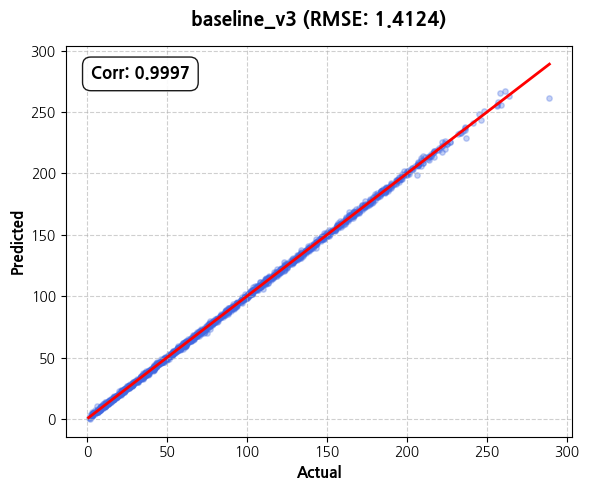

{'objective': 'reg:squarederror', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': 0.9275546634218009, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': None, 'feature_types': None, 'feature_weights': None, 'gamma': 1.9730600594442318, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': 0.06823926151272564, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 3, 'max_leaves': None, 'min_child_weight': 5, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': 1764, 'n_jobs': -1, 'num_parallel_tree': None, 'random_state': 42, 'reg_alpha': 2.384727955994853, 'reg_lambda': 3.9970785553362034, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': 0.6414667384771996, 'tree_method': 'hist', 'validate_parameters': None, 'verbosity': None

In [59]:
# 1. 함수 실행 결과를 변수에 저장 (반환값이 3개이므로 unpacking)
pipeline, val_preds, rmse = run_experiment_pipeline(train_x, train_y, 'baseline_v3')

# 2. 파이프라인에서 'regressor' (XGBoost) 단계만 꺼내서 파라미터 확인
xgb_model = pipeline.named_steps['regressor']

# 3. 설정된 모든 하이퍼파라미터 출력
print(xgb_model.get_params())

In [60]:
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns

# # 1. preprocessor에서 변환된 모든 컬럼명을 순서대로 가져오기
# # get_feature_names_out()을 쓰면 인코딩된 이름까지 한꺼번에 나옵니다.
# feature_names_out = final_pipeline.named_steps['preprocessor'].get_feature_names_out()

# # 2. 중요도 매칭 (이제 길이는 무조건 일치합니다)
# importances = final_pipeline.named_steps['regressor'].feature_importances_
# feature_df = pd.DataFrame({'feature': feature_names_out, 'importance': importances})
# feature_df = feature_df.sort_values(by='importance', ascending=False)

# # 3. 중요도 시각화
# plt.figure(figsize=(10, 10))
# sns.barplot(x='importance', y='feature', data=feature_df)
# plt.title('Feature Importance (XGBoost)')
# plt.show()

# # 4. 하위 10개 피처 출력
# print("--- 삭제 후보 (기여도 하위 10개) ---")
# print(feature_df.tail(10))

# Delete Feature Variables / 회귀에 강력한 영향을 미치지 않는 Feature를 제거

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   Exercise_Duration         7500 non-null   float64 
 1   Body_Temperature(F)       7500 non-null   float64 
 2   BPM                       7500 non-null   float64 
 3   Gender                    7500 non-null   object  
 4   Age                       7500 non-null   int64   
 5   Weight(kg)                7500 non-null   float64 
 6   Height(cm)                7500 non-null   float64 
 7   Height(m)                 7500 non-null   float64 
 8   BMI                       7500 non-null   float64 
 9   BMR_Harris                7500 non-null   float64 
 10  RMR_Mifflin               7500 non-null   float64 
 11  BPM_Multiplier            7500 non-null   float64 
 12  Session_Harris_Calories   7500 non-null   float64 
 13  Session_Mifflin_Calories  7500 non-null   float6

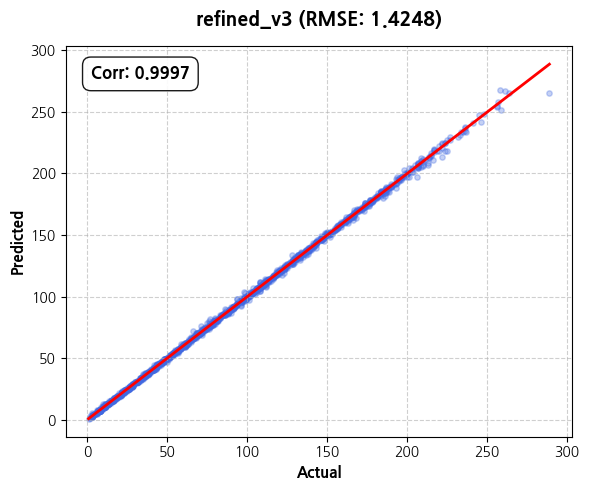

{'objective': 'reg:squarederror', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': 0.8849995601105662, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': None, 'feature_types': None, 'feature_weights': None, 'gamma': 0.12125299988056815, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': 0.015112624717889383, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 12, 'max_leaves': None, 'min_child_weight': 6, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': 1499, 'n_jobs': -1, 'num_parallel_tree': None, 'random_state': 42, 'reg_alpha': 2.2071076809186962, 'reg_lambda': 7.004195617911955, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': 0.689528033551232, 'tree_method': 'hist', 'validate_parameters': None, 'verbosity': No

In [ ]:
# 제거할 피처 리스트 정의
drops_features_v1 = [
    'Height(Feet)', 'Height(Remainder_Inches)', 'Weight(lb)',
    'Age_Range', 'Weight_Status', 
    'Is_Overheat'
]

# 학습 및 테스트 데이터에서 불필요한 피처 제거
train_x_refined_v1 = train_x.drop(columns=drops_features_v1, errors='ignore')
test_x_refined_v1 = test_x.drop(columns=drops_features_v1, errors='ignore')

# 정제된 학습 데이터의 기본 정보 출력
print(train_x_refined_v1.info())

# 모델 학습 파이프라인 실행 및 결과 반환
pipeline, val_preds, rmse = run_experiment_pipeline(train_x_refined_v1, train_y, 'refined_v3')

# 파이프라인 내 최종 회귀 모델(XGBoost) 객체 추출 및 파라미터 확인
xgb_model = pipeline.named_steps['regressor']
print(xgb_model.get_params())

# Residual Learning / 잔차 학습

📂 기존 모델 로드 중: ./model\residual_v3_keytel.pkl


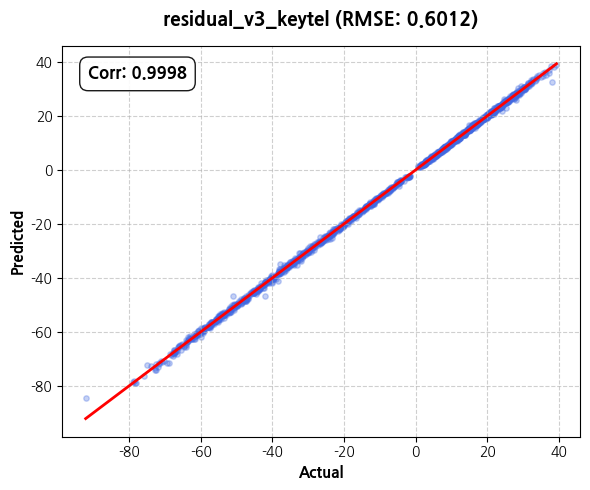

{'objective': 'reg:squarederror', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': 0.8742629933049748, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': None, 'feature_types': None, 'feature_weights': None, 'gamma': 0.08800244004715871, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': 0.03580096496879255, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 6, 'max_leaves': None, 'min_child_weight': 9, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': 1172, 'n_jobs': -1, 'num_parallel_tree': None, 'random_state': 42, 'reg_alpha': 7.700781842310082, 'reg_lambda': 5.0233796642124915, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': 0.6343781617658597, 'tree_method': 'hist', 'validate_parameters': None, 'verbosity': Non

In [ ]:
# 실제 칼로리 소모량과 기존 공식(Keytel) 추정치 간의 차이인 잔차(Residual)을 새로운 잔차로 학습
train_y_residual = train['Calories_Burned'] - train['Session_Keytel_Calories']

# 생성된 잔차를 타겟으로 하여 모델 학습 파이프라인 실행 및 결과 반환
pipeline, val_preds, rmse = run_experiment_pipeline(train_x_refined_v1, train_y_residual, 'residual_v3_keytel')

# 파이프라인 내 최종 회귀 모델(XGBoost) 객체 추출 및 파라미터 확인
xgb_model = pipeline.named_steps['regressor']
print(xgb_model.get_params())

# Evaluate Residual Model / 소모 칼로리에 대한 RMSE 값을 계산

In [ ]:
def evaluate_residual_model(model_name, train_x, train_y_res, train_df, is_kfold=False):
    """
    model_name: 저장된 모델명 (예: 'residual_v1_keytel')
    train_x: 독립변수 데이터프레임
    train_y: 종속변수 시리즈 (잔차 타겟)
    train_df: 원본 학습 데이터프레임 (칼로리 공식 결과 포함)
    is_kfold: K-Fold 검증 여부 (True면 전체 데이터로 검증, False면 Hold-out 검증)
    """
    
    # 검증 방식(K-Fold 또는 Hold-out)에 따른 평가용 데이터 및 타겟 변수 분리 설정
    if is_kfold:
        eval_x = train_x
        actual_calories = train_df['Calories_Burned']
        base_calories = train_df['Session_Keytel_Calories']
        mode_text = "케이폴드 전체 데이터"
    else:
        _, eval_x, _, _ = train_test_split(train_x, train_y_res, test_size=0.2, random_state=42)
        actual_calories = train_df.loc[eval_x.index, 'Calories_Burned']
        base_calories = train_df.loc[eval_x.index, 'Session_Keytel_Calories']
        mode_text = "단일 모델 검증 데이터"
    
    # 지정된 경로에서 사전 학습된 모델 파이프라인 로드
    save_path = f'./model/{model_name}.pkl'
    loaded_pipeline = joblib.load(save_path)

    # 설정된 평가 데이터에 대하여 잔차 예측 수행
    pred_residuals = loaded_pipeline.predict(eval_x)

    # 공식 계산값에 모델이 예측한 잔차를 더하여 최종 예측값 산출
    final_predictions = base_calories + pred_residuals

    # 실제 정답 칼로리와 보정된 예측 칼로리 간의 오차를 계산
    final_real_rmse = np.sqrt(mean_squared_error(actual_calories, final_predictions))
    print(f"최종 결과 {mode_text} 기준 실제 RMSE: {final_real_rmse:.4f}")

    # 시각화를 위한 임시 데이터프레임을 구성
    temp_df = pd.DataFrame({
        'Actual_Calories': actual_calories,
        'Predicted_Calories': final_predictions
    })

    # 실제값과 예측값의 분포 및 상관관계 시각화
    plot_scatter(
        df=temp_df, 
        x_col='Actual_Calories', 
        y_col='Predicted_Calories', 
        title=f'{model_name} (RMSE: {final_real_rmse:.4f})', 
        figsize=(10, 6)
    )

최종 결과 단일 모델 검증 데이터 기준 실제 RMSE: 0.1776


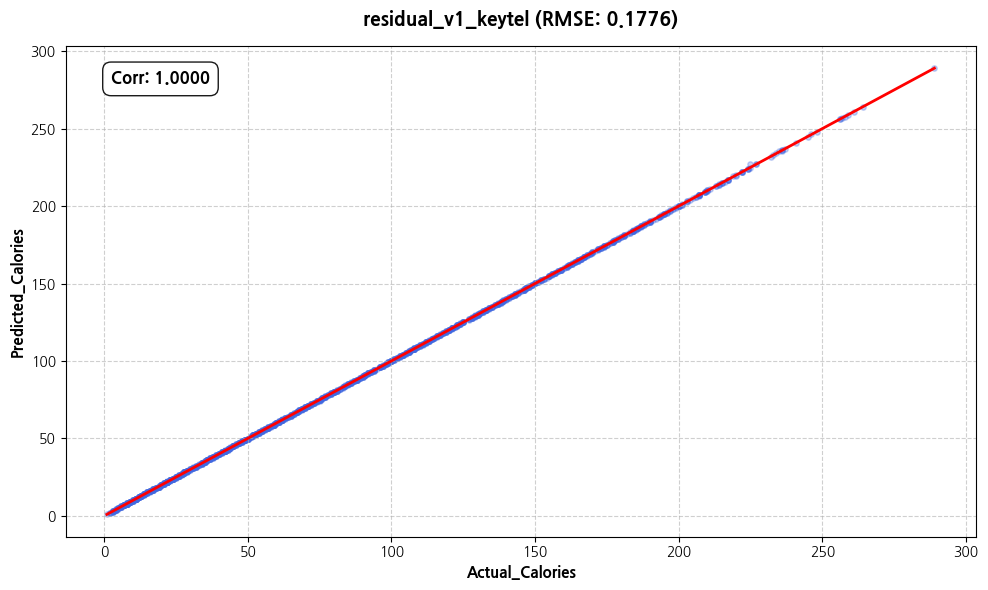

In [ ]:
# 학습된 잔차 예측 모델('residual_v1_keytel')을 Hold-out 방식으로 검증 및 최종 성능(RMSE) 시각화
evaluate_residual_model('residual_v1_keytel', train_x_refined_v1, train_y_residual, train)

# Try Submission / 데이콘 제출을 위한 Submission.csv 작성

In [65]:
def generate_submission(test_df, model_name, drop_features=None):
    submission_ids = test_df['ID']

    # 모델 추론에 불필요한 제거 대상 피처와 아이디를 제거
    if drop_features is not None:
        test_x_refined = test_df.drop(columns=drop_features + ['ID'], errors='ignore')
    else:
        test_x_refined = test_df.drop(columns=['ID'], errors='ignore')

    # 지정된 경로에서 학습된 잔차 예측 모델을 불러오기
    model_path= f"./model/{model_name}.pkl"
    print(f"📂 모델 로드 중: {model_name}")
    loaded_pipeline = joblib.load(model_path)

    # 테스트 데이터에 대한 잔차 예측
    print("🔍 테스트 데이터 잔차 예측 중...")
    test_pred_residuals = loaded_pipeline.predict(test_x_refined)

    # 기존 공식 계산값에 예측된 잔차 보정값을 더해 최종 예측값 산출
    test_final_predictions = test_df['Session_Keytel_Calories'] + test_pred_residuals

    # 제출 양식에 맞는 데이터프레임 구성
    submission = pd.DataFrame({
        'ID': submission_ids,
        'Calories_Burned': test_final_predictions
    })

    # 음수 칼로리가 나오는 이상 현상을 방지하기 위해 하한값을 0으로 제한
    submission['Calories_Burned'] = submission['Calories_Burned'].clip(lower=0)

    # 지정된 규칙에 따라 저장 경로를 설정하고, 폴더가 없다면 생성
    save_dir = './data/submission/'
    os.makedirs(save_dir, exist_ok=True)
    save_path = f"{save_dir}submission_{model_name}.csv"

    # 최종 산출물을 지정된 경로에 파일로 저장합니다
    submission.to_csv(save_path, index=False)

    print(f"🎉 성공적으로 저장되었습니다: {save_path}")
    print(submission.head())
    
    return submission

# Submission for Residual Model

In [66]:
generate_submission(test, 'residual_v3_keytel', drops_features_v1)

📂 모델 로드 중: residual_v3_keytel
🔍 테스트 데이터 잔차 예측 중...
🎉 성공적으로 저장되었습니다: ./data/submission/submission_residual_v3_keytel.csv
          ID  Calories_Burned
0  TEST_0000       173.052439
1  TEST_0001       190.561873
2  TEST_0002        53.350484
3  TEST_0003       161.156741
4  TEST_0004       225.829207


,ID,Calories_Burned
0,TEST_0000,173.052439
1,TEST_0001,190.561873
2,TEST_0002,53.350484
3,TEST_0003,161.156741
4,TEST_0004,225.829207
...,...,...
7495,TEST_7495,196.983155
7496,TEST_7496,10.118506
7497,TEST_7497,130.042720
7498,TEST_7498,31.964583


# K-fold Cross-Validation / K-겹 교차검증

📂 기존 모델 로드 중: ./model\residual_v3_kfold_keytel.pkl


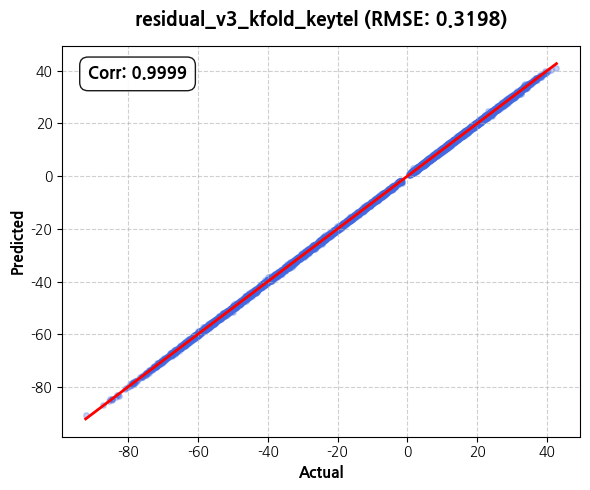

{'objective': 'reg:squarederror', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': 0.8222813390450193, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': None, 'feature_types': None, 'feature_weights': None, 'gamma': 0.028529509779425293, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': 0.09486806566871868, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 4, 'max_leaves': None, 'min_child_weight': 6, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': 872, 'n_jobs': -1, 'num_parallel_tree': None, 'random_state': 42, 'reg_alpha': 1.2358317743159615, 'reg_lambda': 6.429641572771191, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': 0.923695664971501, 'tree_method': 'hist', 'validate_parameters': None, 'verbosity': None

In [67]:
# 교차 검증을 위한 K-Fold 분할기 객체 생성
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# 잔차 타겟과 정제된 피처로 K-Fold 파이프라인 실행
pipeline, val_preds, rmse = run_experiment_pipeline(train_x_refined_v1, train_y_residual, 'residual_v3_kfold_keytel', cv=kf)
xgb_model = pipeline.named_steps['regressor']
print(xgb_model.get_params())

최종 결과 케이폴드 전체 데이터 기준 실제 RMSE: 0.3198


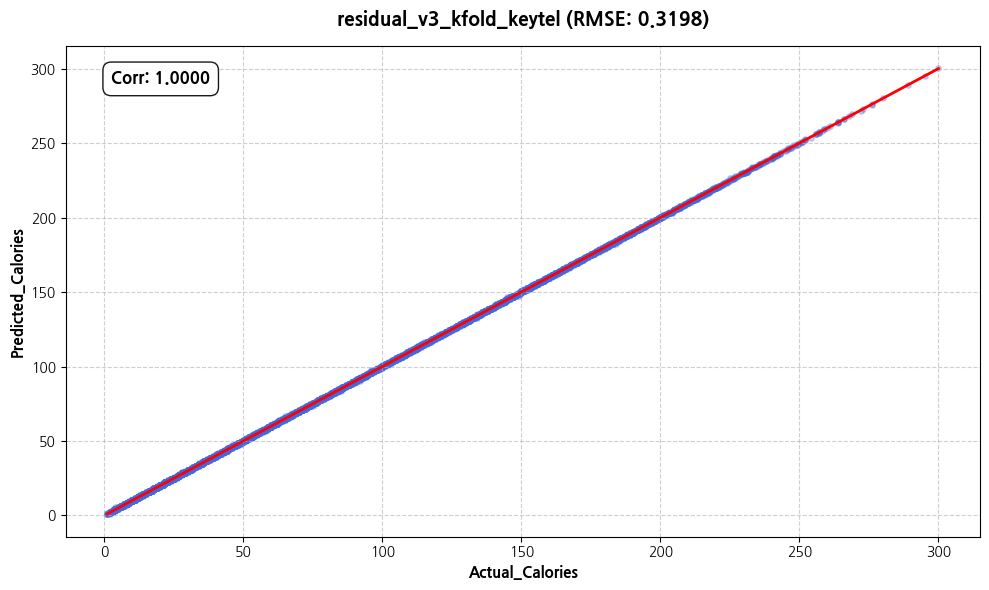

In [ ]:
# K-Fold 방식으로 학습된 잔차 모델('residual_v3_kfold_keytel')을 전체 데이터 기준으로 검증 및 최종 성능 평가
evaluate_residual_model('residual_v3_kfold_keytel', train_x_refined_v1, train_y_residual, train, is_kfold=True)

# Analyze Rounding Effect / 반올림 여부에 따라서 달라지는 성능 비교

In [69]:
def analyze_rounding_effect(model_name, train_x, train_y_res, train_df, is_kfold=False):
    """
    model_name: 저장된 모델명 (예: 'residual_v1_keytel')
    train_x: 독립변수 데이터프레임
    trian_y_res: 종속변수 시리즈 (잔차 타겟)
    train_df: 원본 학습 데이터프레임 (칼로리 공식 결과 포함)
    is_kfold: K-Fold 검증 여부 (True면 전체 데이터로 검증, False면 Hold-out 검증)
    """
    
    # 케이폴드 여부에 따라 평가에 사용할 데이터를 분기
    # K-Fold 검증인 경우 전체 데이터를 평가에 사용
    if is_kfold:
        eval_x = train_x 
        actual_calories = train_df['Calories_Burned']
        base_calories = train_df['Session_Keytel_Calories']
    # 단일 모델 검증인 경우 Hold-out 검증 데이터 사용
    else:
        _, eval_x, _, _ = train_test_split(train_x, train_y_res, test_size=0.2, random_state=42)
        actual_calories = train_df.loc[eval_x.index, 'Calories_Burned']
        base_calories = train_df.loc[eval_x.index, 'Session_Keytel_Calories']

    # 모델 경로를 지정하고 학습된 파이프라인을 불러오기
    save_path = f'./model/{model_name}.pkl'
    loaded_pipeline = joblib.load(save_path)

    # 평가 데이터에 대한 잔차를 예측하고 원본 최종 예측값을 계산
    val_pred_residuals = loaded_pipeline.predict(eval_x)
    val_final_raw = base_calories + val_pred_residuals
    
    # 원본 예측값을 반올림 처리
    val_final_rounded = np.round(val_final_raw)

    # 반올림 적용 전과 후의 오차를 각각 계산
    rmse_raw = np.sqrt(mean_squared_error(actual_calories, val_final_raw))
    rmse_rounded = np.sqrt(mean_squared_error(actual_calories, val_final_rounded))

    # 계산된 두 가지 버전의 점수를 화면에 출력
    print(f"반올림 효과 분석 모델 {model_name}")
    print(f"반올림 전 원본 RMSE: {rmse_raw:.4f}")
    print(f"반올림 후 최종 RMSE: {rmse_rounded:.4f}")

    # 시각화를 위해 임시 데이터프레임을 생성
    temp_df = pd.DataFrame({
        'Actual_Calories': actual_calories,
        'Predicted_Raw': val_final_raw,
        'Predicted_Rounded': val_final_rounded
    })

    # 반올림 적용 전의 예측값과 실제값 분포를 시각화
    plot_scatter(
        df=temp_df, 
        x_col='Actual_Calories', 
        y_col='Predicted_Raw', 
        title=f'{model_name} Before Rounding RMSE {rmse_raw:.4f}', 
        figsize=(8, 5)
    )

    # 반올림 적용 후의 예측값과 실제값 분포를 시각화
    plot_scatter(
        df=temp_df, 
        x_col='Actual_Calories', 
        y_col='Predicted_Rounded', 
        title=f'{model_name} After Rounding RMSE {rmse_rounded:.4f}', 
        figsize=(8, 5)
    )

In [1]:
# K-Fold 방식으로 학습된 모델('residual_v3_kfold_keytel')의 예측값 반올림 효과 분석
analyze_rounding_effect(
    model_name='residual_v3_kfold_keytel', 
    train_x=train_x_refined_v1, 
    train_y_res=train_y_residual, 
    train_df=train, 
    is_kfold=False  # K-Fold 모델이지만, Hold-out 모델과 공정하게 비교
)

NameError: name 'analyze_rounding_effect' is not defined

In [ ]:
def analyze_feature_importance(model_name, feature_names):  
    # 모델 저장 경로 설정 및 파일 존재 여부 확인
    model_path = f'./model/{model_name}.pkl'
    
    if not os.path.exists(model_path):
        print(f"❌ 모델 파일이 존재하지 않습니다: {model_path}")
        return
    
    # 지정된 경로에서 사전 학습된 파이프라인 로드
    print(f"📂 모델 로드 중: {model_name}")
    loaded_pipeline = joblib.load(model_path)
    
    # 파이프라인의 마지막 단계(모델) 추출
    final_model = list(loaded_pipeline.named_steps.values())[-1]
    importances = final_model.feature_importances_
    
    # 추출된 피처 중요도 배열과 입력된 피처명 리스트의 길이 일치 여부 검증
    if len(importances) != len(feature_names):
        print("❌ 피처 중요도와 피처 이름의 개수가 일치하지 않습니다.")
        return
    
    # 피처명과 중요도를 데이터프레임으로 묶고 중요도 기준 내림차순 정렬
    fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
    fi_df = fi_df.sort_values(by='Importance', ascending=False)
    
    # 정렬된 피처 중요도 결과를 텍스트 형식으로 화면에 출력
    print_divider()
    print(f"📊 [Feature Importance for {model_name}]")
    print_divider()
    print(fi_df.to_string(index=False))
    print_divider()
    
    # 상위 20개 피처에 대한 중요도를 막대 그래프(Bar Plot)로 시각화
    plt.figure(figsize=(12, 8))
    sns.barplot(x='Importance', y='Feature', data=fi_df.head(20), hue='Feature', palette='viridis', legend=False)
    plt.title(f'Feature Analysis: {model_name}', fontsize=15)
    plt.xlabel('Importance Score')
    plt.ylabel('Features')
    plt.tight_layout()
    plt.show()    

📂 모델 로드 중: residual_v3_kfold_keytel
------------------------------------------------------------------------------------------------------------------------
📊 [Feature Importance for residual_v3_kfold_keytel]
------------------------------------------------------------------------------------------------------------------------
                 Feature  Importance
                  Gender    0.838105
                     BPM    0.073689
       Duration_Category    0.027171
         Intensity_Level    0.020265
                     Age    0.013916
            Session_Type    0.010652
     Body_Temperature(F)    0.004975
 Session_Harris_Calories    0.003514
       Thermal_Intensity    0.003499
       Heat_Energy_Proxy    0.002559
             RMR_Mifflin    0.000492
                     BMI    0.000467
 Session_Keytel_Calories    0.000243
              Height(cm)    0.000155
       Exercise_Duration    0.000085
          BPM_Multiplier    0.000075
Session_Mifflin_Calories    0.000058
    

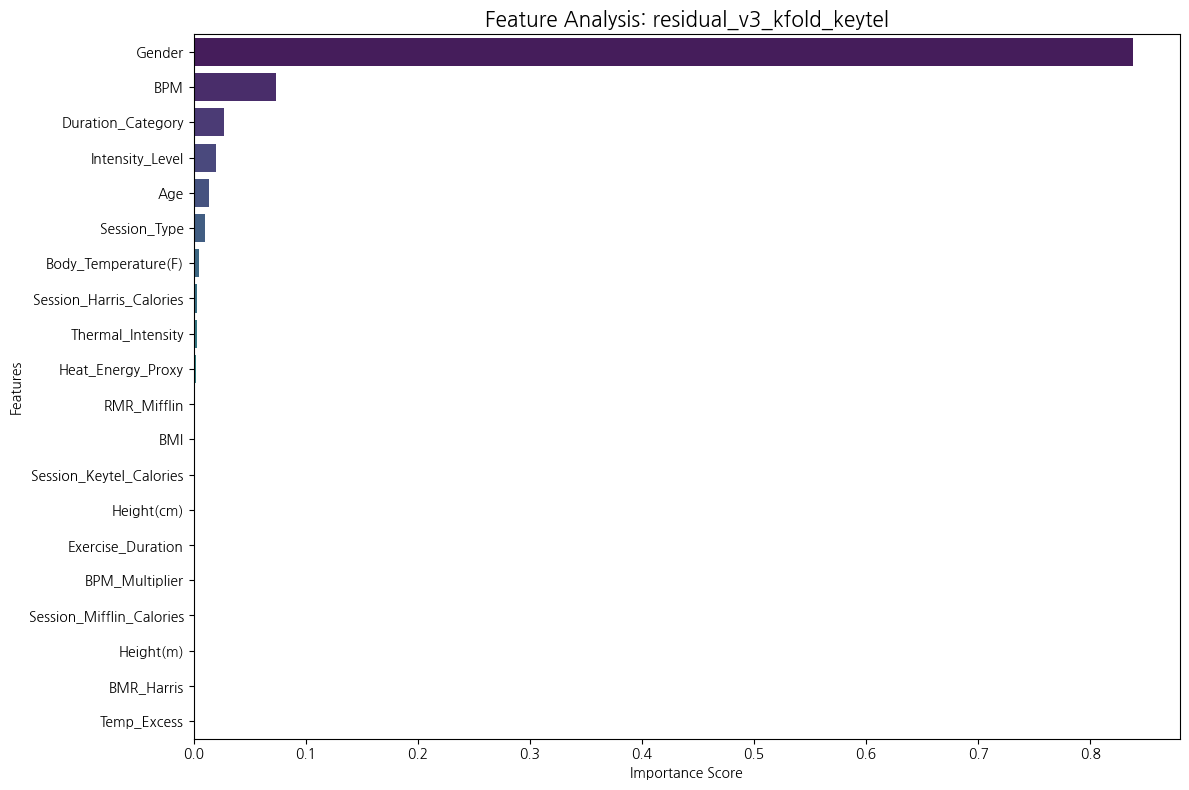

In [ ]:
# 학습된 K-Fold 잔차 예측 모델('residual_v3_kfold_keytel')의 피처 중요도(Feature Importance) 분석 및 시각화
analyze_feature_importance('residual_v3_kfold_keytel', train_x_refined_v1.columns)

# Gender Split Model/ 성별 분리 및 개별 학습 모델

['F' 'M']
👨 남자 데이터 학습 시작 (데이터 개수: 3731)
📂 기존 모델 로드 중: ./model\residual_v4_male.pkl


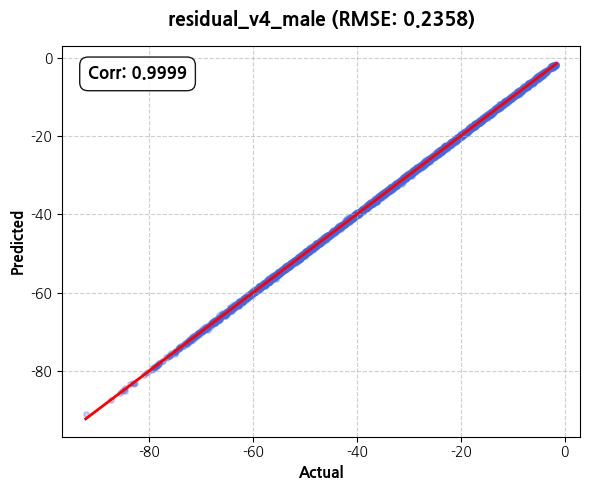

{'objective': 'reg:squarederror', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': 0.6982323001155836, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': None, 'feature_types': None, 'feature_weights': None, 'gamma': 0.016087116039914306, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': 0.08368103087651906, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 4, 'max_leaves': None, 'min_child_weight': 2, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': 1441, 'n_jobs': -1, 'num_parallel_tree': None, 'random_state': 42, 'reg_alpha': 1.6225280303871092, 'reg_lambda': 5.596199945539027, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': 0.9540562508317982, 'tree_method': 'hist', 'validate_parameters': None, 'verbosity': No

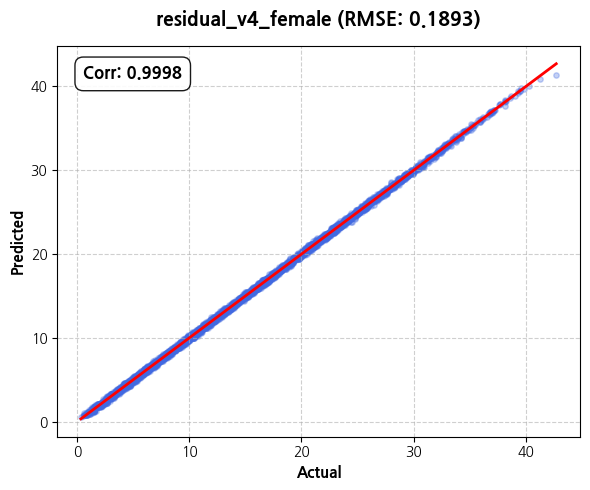

{'objective': 'reg:squarederror', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': 0.9571963706302129, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': None, 'feature_types': None, 'feature_weights': None, 'gamma': 0.016603145873345156, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': 0.025165596275392697, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 7, 'max_leaves': None, 'min_child_weight': 9, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': 752, 'n_jobs': -1, 'num_parallel_tree': None, 'random_state': 42, 'reg_alpha': 0.10043437066533567, 'reg_lambda': 2.494292654221201, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': 0.681504213139258, 'tree_method': 'hist', 'validate_parameters': None, 'verbosity': No

In [ ]:
# 성별(Gender) 컬럼의 고유값 확인
print(train_x_refined_v1['Gender'].unique())

# 남성(M) 데이터 추출 및 전처리 (단일 성별이므로 Gender 컬럼 제거)
mask_male = (train_x_refined_v1['Gender'] == 'M')
X_male = train_x_refined_v1[mask_male].drop(columns=['Gender'])
y_male = train_y_residual[mask_male]

# 남성 전용 잔차 예측 모델 학습 및 교차 검증(K-Fold) 수행
print(f"👨 남자 데이터 학습 시작 (데이터 개수: {len(X_male)})")
pipeline, val_preds, rmse = run_experiment_pipeline(X_male, y_male, 'residual_v4_male', cv=kf)

# 남성 모델 파이프라인 내 최종 회귀 객체 추출 및 파라미터 확인
xgb_model = pipeline.named_steps['regressor']
print(xgb_model.get_params())

# 여성(F) 데이터 추출 및 전처리 (단일 성별이므로 Gender 컬럼 제거)
mask_female = (train_x_refined_v1['Gender'] == 'F')
X_female = train_x_refined_v1[mask_female].drop(columns=['Gender'])
y_female = train_y_residual[mask_female]

# 여성 전용 잔차 예측 모델 학습 및 교차 검증(K-Fold) 수행
print(f"\n👩 여자 데이터 학습 시작 (데이터 개수: {len(X_female)})")
pipeline, val_preds, rmse = run_experiment_pipeline(X_female, y_female, 'residual_v4_female', cv=kf)

# 여성 모델 파이프라인 내 최종 회귀 객체 추출 및 파라미터 확인
xgb_model = pipeline.named_steps['regressor']
print(xgb_model.get_params())

📂 모델 로드 중: residual_v4_female
------------------------------------------------------------------------------------------------------------------------
📊 [Feature Importance for residual_v4_female]
------------------------------------------------------------------------------------------------------------------------
                 Feature  Importance
         Intensity_Level    0.711262
       Duration_Category    0.163019
                     Age    0.049825
                     BPM    0.024725
     Body_Temperature(F)    0.019214
       Heat_Energy_Proxy    0.014214
       Thermal_Intensity    0.006113
                     BMI    0.005230
              Height(cm)    0.002081
 Session_Keytel_Calories    0.002064
               Height(m)    0.000628
       Exercise_Duration    0.000376
          BPM_Multiplier    0.000305
              BMR_Harris    0.000176
             RMR_Mifflin    0.000155
 Session_Harris_Calories    0.000129
             Temp_Excess    0.000126
            Sess

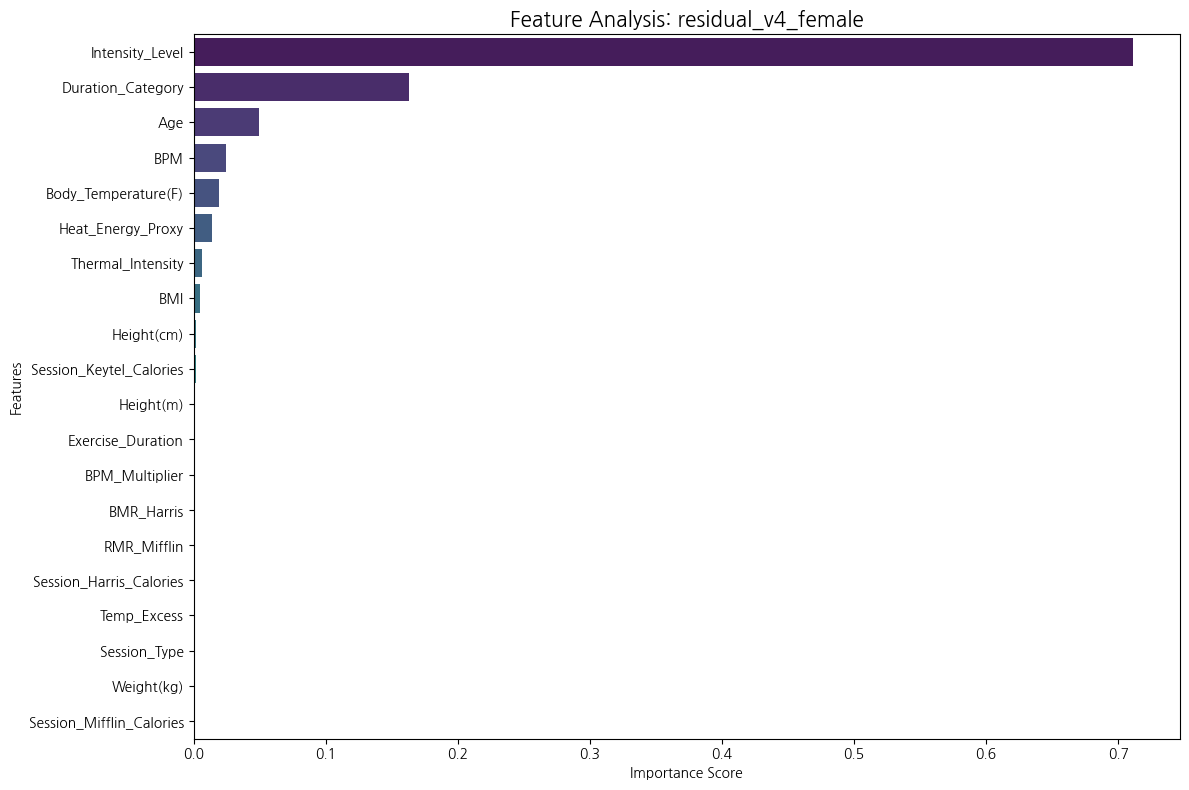

📂 모델 로드 중: residual_v4_male
------------------------------------------------------------------------------------------------------------------------
📊 [Feature Importance for residual_v4_male]
------------------------------------------------------------------------------------------------------------------------
                 Feature  Importance
                     BPM    0.705566
       Duration_Category    0.103147
     Body_Temperature(F)    0.079713
                     Age    0.048181
            Session_Type    0.030691
       Thermal_Intensity    0.015140
         Intensity_Level    0.007379
       Heat_Energy_Proxy    0.004598
                     BMI    0.002135
 Session_Keytel_Calories    0.000993
              BMR_Harris    0.000894
       Exercise_Duration    0.000563
              Height(cm)    0.000481
 Session_Harris_Calories    0.000159
               Height(m)    0.000148
          BPM_Multiplier    0.000083
             RMR_Mifflin    0.000046
Session_Mifflin_Calo

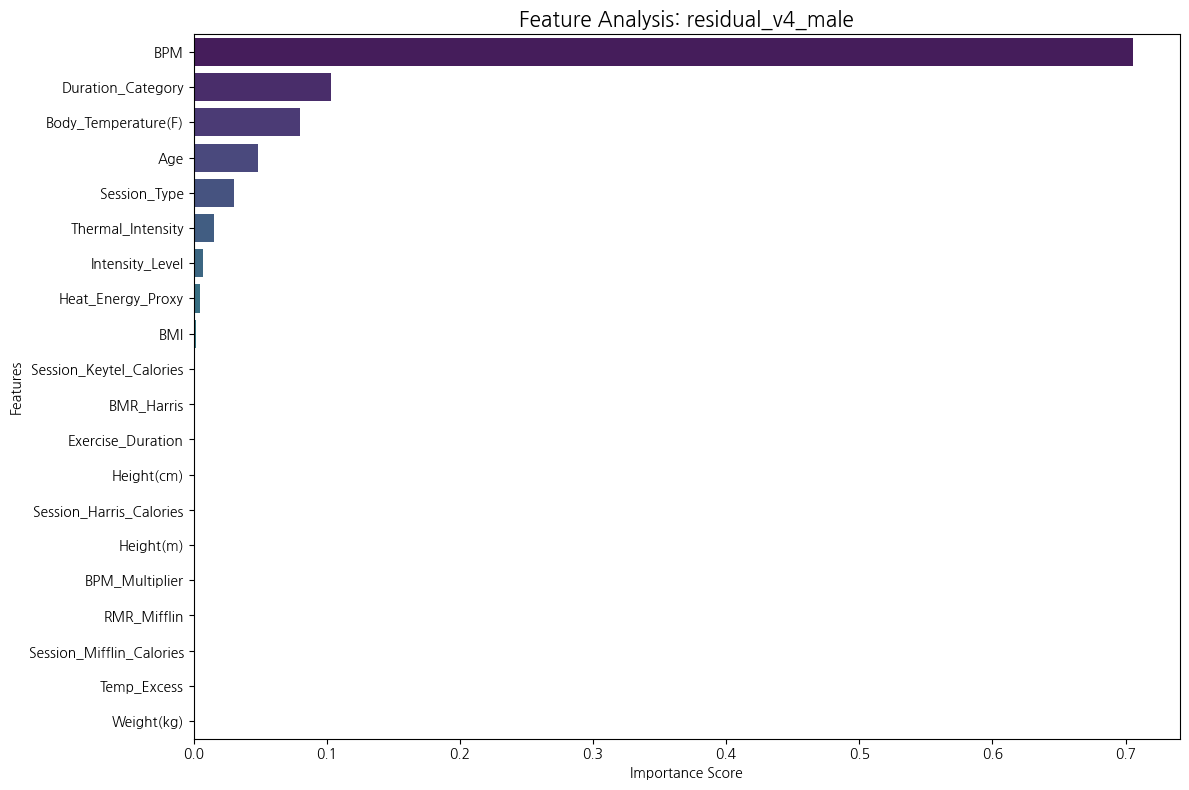

In [ ]:
# 학습된 여성 전용 잔차 예측 모델('residual_v4_female')의 피처 중요도 분석 및 시각화
analyze_feature_importance('residual_v4_female', X_female.columns)

# 학습된 남성 전용 잔차 예측 모델('residual_v4_male')의 피처 중요도 분석 및 시각화
analyze_feature_importance('residual_v4_male', X_male.columns)

반올림 효과 분석 모델 residual_v4_female
반올림 전 원본 RMSE: 0.1826
반올림 후 최종 RMSE: 0.0364


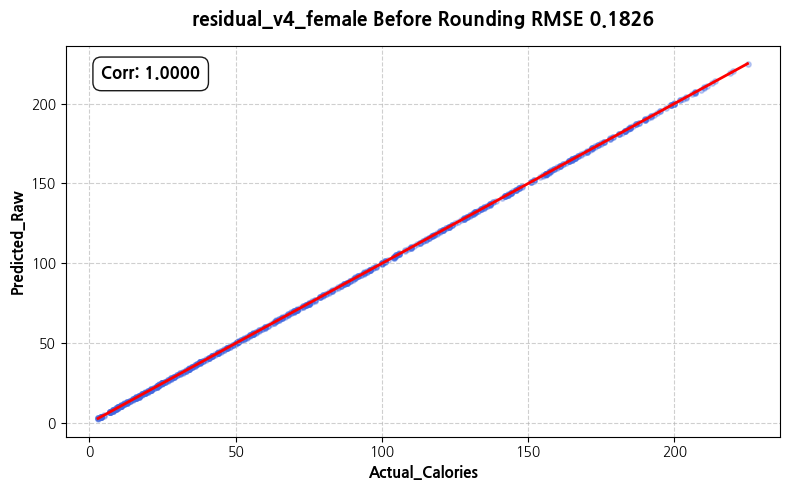

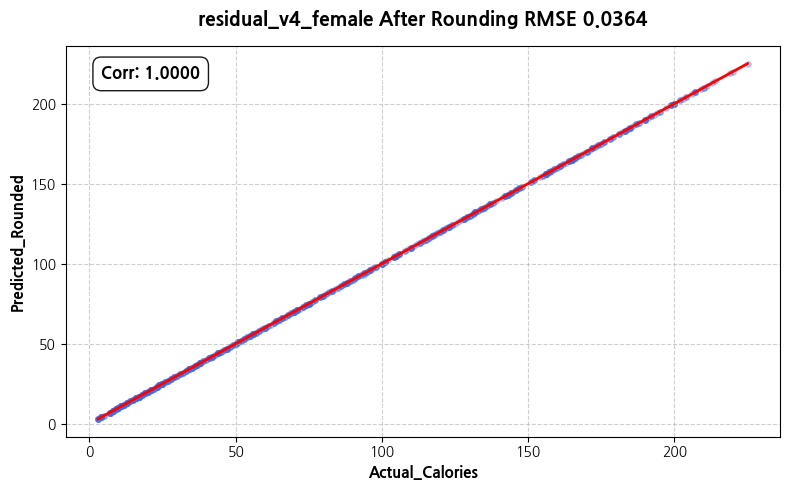

반올림 효과 분석 모델 residual_v4_male
반올림 전 원본 RMSE: 0.2390
반올림 후 최종 RMSE: 0.1970


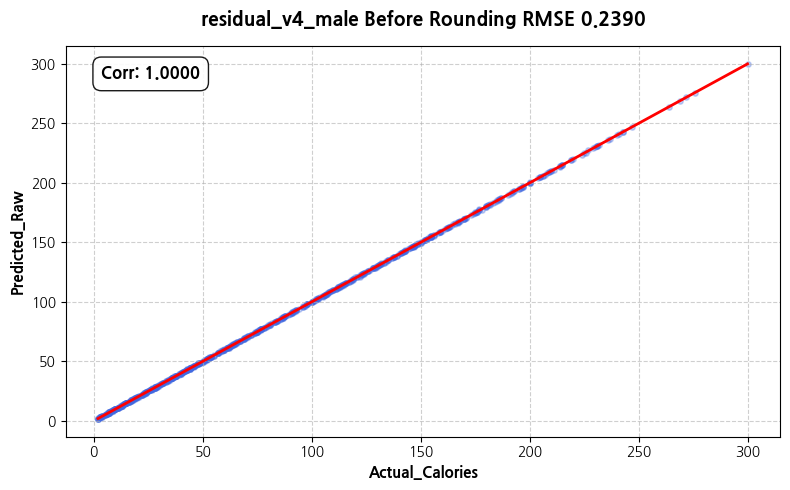

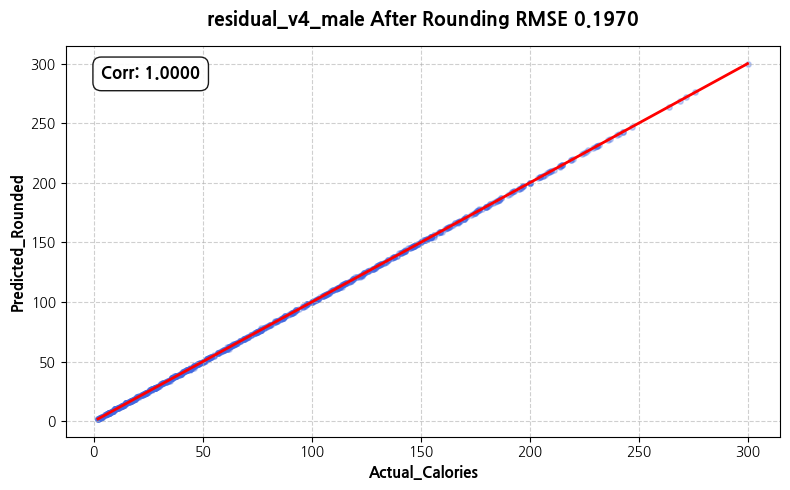

In [ ]:
# 학습된 여성 전용 모델('residual_v4_female')의 최종 예측값 반올림 적용 전후 성능(RMSE) 비교 및 시각화
analyze_rounding_effect('residual_v4_female', X_female, y_female, train)
# 학습된 남성 전용 모델('residual_v4_male')의 최종 예측값 반올림 적용 전후 성능(RMSE) 비교 및 시각화
analyze_rounding_effect('residual_v4_male', X_male, y_male, train)

In [ ]:
def generate_split_submission(test_df, group_col, model_map, save_suffix):
    """
    test_df: 추론 대상 테스트 데이터프레임
    group_col: 데이터를 분할할 기준 컬럼 (예: 'Gender')
    model_map: 그룹 값과 매핑될 모델명 딕셔너리 (예: {'M': 'residual_v4_male', 'F': 'residual_v4_female'})
    save_suffix: 저장 파일명에 사용할 접미사
    """
    
    # 원본 데이터 훼손 방지를 위한 복사본 생성
    df = test_df.copy()
    
    # ID 컬럼 누락 시 원본 파일에서 ID를 가져와서 추가 (예외 처리)
    if 'ID' not in df.columns:
        temp_test = pd.read_csv('./data/test.csv')
        df['ID'] = temp_test['ID']

    result_fragments = []
    
    print(f"🚀 [Raw Prediction] 기준: {group_col} (반올림 X)")
    
    # 모델 맵에 정의된 그룹(예: 성별) 단위로 순회하며 개별 예측 수행
    for group_val, model_name in model_map.items():
        # 현재 그룹에 해당하는 데이터만 필터링
        mask = (df[group_col] == group_val)
        sub_df = df[mask].copy()
        
        if len(sub_df) == 0: continue
            
        print(f"👉 그룹 [{group_val}] 처리 중... (데이터 {len(sub_df)}개)")
        
        # 사전 학습된 개별 그룹용 모델 로드
        model_path = f"./model/{model_name}.pkl"
        try:
            model = joblib.load(model_path)
        except FileNotFoundError:
            print(f"❌ 오류: 모델 파일을 찾을 수 없습니다 ({model_path})")
            return None

        # 예측에 불필요한 식별자 및 분할 기준 컬럼 제거
        X_test_sub = sub_df.drop(columns=['ID', group_col], errors='ignore')
        
        # 필터링된 데이터에 대한 잔차(Residual) 예측
        pred_residuals = model.predict(X_test_sub)
        
        # 기존 공식(Keytel) 값에 모델이 예측한 잔차를 더하여 최종 칼로리 산출
        final_preds = sub_df['Session_Keytel_Calories'] + pred_residuals
        
        # 예측 결과를 ID와 매핑하여 데이터프레임 생성 후 리스트에 추가
        fragment = pd.DataFrame({
            'ID': sub_df['ID'],
            'Calories_Burned': final_preds
        })
        result_fragments.append(fragment)
        
    # 처리된 결과가 없는 경우 함수 종료
    if not result_fragments:
        return None
        
    # 리스트에 모인 예측 결과 조각들을 하나의 데이터프레임으로 합치기
    submission = pd.concat(result_fragments)
    
    # 반올림 기능은 임시 비활성화
    # submission['Calories_Burned'] = submission['Calories_Burned'].round()  
    
    # 칼로리 소모량이 음수가 될 수 없으므로 0으로 하한값 보정 
    submission['Calories_Burned'] = submission['Calories_Burned'].clip(lower=0)
    
    # 제출 양식에 맞게 ID 기준으로 오름차순 정렬 및 인덱스 초기화
    submission = submission.sort_values('ID').reset_index(drop=True)
    
    # 지정된 경로에 따라 DACON 제출용 CSV 파일 저장
    save_dir = './data/submission/'
    os.makedirs(save_dir, exist_ok=True)
    save_path = f"{save_dir}submission_{save_suffix}_raw.csv"
    
    submission.to_csv(save_path, index=False)
    print(f"\n🎉 [Raw 파일 저장 완료] {save_path}")
    print(submission.head())
    
    return submission

In [ ]:
# 최종 제출 양식에 맞추기 위해 정제된 테스트 데이터에 원본 ID 컬럼 추가
test_x_refined_v1['ID'] = test['ID']

# 분할 추론을 위한 성별(Gender) 카테고리와 사전 학습된 전용 모델명 매핑
gender_map = {
    'M': 'residual_v4_male',  
    'F': 'residual_v4_female'
}

# 성별 기준으로 테스트 데이터를 분할하여 각각의 전용 모델로 추론한 뒤, 결과 병합하여 최종 제출 파일 생성
submission = generate_split_submission(
    test_df=test_x_refined_v1,   
    group_col='Gender',          
    model_map=gender_map,   
    save_suffix='v4_gender_split'
)

🚀 [Raw Prediction] 기준: Gender (반올림 X)
👉 그룹 [M] 처리 중... (데이터 3716개)
👉 그룹 [F] 처리 중... (데이터 3784개)

🎉 [Raw 파일 저장 완료] ./data/submission/submission_v4_gender_split_raw.csv
          ID  Calories_Burned
0  TEST_0000       172.689508
1  TEST_0001       190.149985
2  TEST_0002        53.767186
3  TEST_0003       161.403121
4  TEST_0004       225.824370


# Ensemble Model / 앙상블 모델
XGBoost가 판별하지 못한 패턴을 RandomForest가 보완하도록 하는 구조로
데이터를 학습하도록 합니다.

In [ ]:
def objective_ensemble(trial, X, y, cv):
    """
    XGBoost와 RandomForest의 하이퍼파라미터를 동시에 튜닝하고,
    두 모델 예측값의 '평균'을 기준으로 RMSE가 가장 낮은 조합을 찾습니다.
    """
    
    # Optuna를 활용한 XGBoost 하이퍼파라미터 탐색 공간 설정
    param_xgb = {
        'n_estimators': trial.suggest_int('xgb_n_estimators', 500, 2000),
        'max_depth': trial.suggest_int('xgb_max_depth', 3, 10),
        'learning_rate': trial.suggest_float('xgb_learning_rate', 0.01, 0.1),
        'subsample': trial.suggest_float('xgb_subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('xgb_colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('xgb_min_child_weight', 1, 10),
        'gamma': trial.suggest_float('xgb_gamma', 0, 5),
        'reg_alpha': trial.suggest_float('xgb_reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('xgb_reg_lambda', 1e-3, 10.0, log=True),
        'random_state': 42,
        'n_jobs': -1,
        # 'tree_method': 'gpu_hist' 
    }

    # Optuna를 활용한 Random Forest 하이퍼파라미터 탐색 공간 설정
    param_rf = {
        'n_estimators': trial.suggest_int('rf_n_estimators', 100, 300), # 속도를 위해 범위 조절
        'max_depth': trial.suggest_int('rf_max_depth', 5, 20),
        'min_samples_split': trial.suggest_int('rf_min_samples_split', 2, 10),
        'min_samples_leaf': trial.suggest_int('rf_min_samples_leaf', 1, 5),
        'random_state': 42,
        'n_jobs': -1
    }

    # K-Fold 교차 검증을 통한 개별 폴드 학습 및 앙상블 성능 평가
    scores = []
    
    for train_idx, val_idx in cv.split(X, y):
        # 학습 및 검증 데이터 분할
        X_train_fold, y_train_fold = X.iloc[train_idx], y.iloc[train_idx]
        X_val_fold, y_val_fold = X.iloc[val_idx], y.iloc[val_idx]
        
        # XGBoost 데이터 전처리 및 모델 파이프라인 구성 
        model_xgb = XGBRegressor(**param_xgb)
        pipe_xgb = Pipeline([
            ('preprocessor', get_preprocessor(X_train_fold)), 
            ('regressor', model_xgb)
        ])
        
        # Random Forest 데이터 전처리 및 모델 파이프라인 구성
        model_rf = RandomForestRegressor(**param_rf)
        pipe_rf = Pipeline([
            ('preprocessor', get_preprocessor(X_train_fold)), 
            ('regressor', model_rf)
        ])
        
        # 개별 파이프라인 학습 수행
        pipe_xgb.fit(X_train_fold, y_train_fold)
        pipe_rf.fit(X_train_fold, y_train_fold)
        
        # 검증 데이터에 대한 개별 모델 예측 수행
        pred_xgb = pipe_xgb.predict(X_val_fold)
        pred_rf = pipe_rf.predict(X_val_fold)
        
        # 두 모델의 예측값을 산술 평균하여 최종 앙상블 예측값 도출
        final_pred = (pred_xgb + pred_rf) / 2
        
        # 폴드별 앙상블 예측 결과의 검증 오차(RMSE) 산출 및 저장
        rmse = np.sqrt(mean_squared_error(y_val_fold, final_pred))
        scores.append(rmse)
    
    # 전체 폴드 RMSE의 평균값 반환 (Optuna 최적화 목표 지표)
    return np.mean(scores)

In [ ]:
def run_optuna_ensemble(X_train, y_train, X_val=None, y_val=None, cv=None):
    print("🔥 [앙상블] Optuna 최적화 시작 (체계적 파라미터 탐색)...")
    
    # RMSE 최소화를 목표로 Optuna Study 생성 및 30회 반복 탐색 수행
    study = optuna.create_study(direction='minimize')
    study.optimize(lambda trial: objective_ensemble(trial, X_train, y_train, cv), n_trials=30)
    
    # 탐색 완료 후 도출된 최적의 하이퍼파라미터 조합 추출 및 출력
    best_params = study.best_params
    print(f"\n✅ Best Params: {best_params}")
    
    # 추출된 파라미터 딕셔너리에서 접두어('xgb_', 'rf_')에 따라 각 모델의 파라미터를 분리 
    xgb_params = {k.replace('xgb_', ''): v for k, v in best_params.items() if k.startswith('xgb_')}
    rf_params = {k.replace('rf_', ''): v for k, v in best_params.items() if k.startswith('rf_')}
    
    # 분리된 최적 파라미터를 각각 적용하여 독립적인 회귀 모델 인스턴스 생성
    best_xgb = XGBRegressor(**xgb_params)
    best_rf = RandomForestRegressor(**rf_params)
    
    # VotingRgressor를 활용하여 두 개별 모델의 예측값을 산술 평균하는 최종 앙상블 객체 구축
    final_model = VotingRegressor(estimators=[('xgb', best_xgb), ('rf', best_rf)])
    
    # 데이터 전처리기와 앙상블 모델을 하나로 묶어 최종 학습 파이프라인 생성
    final_pipeline = Pipeline([
        ('preprocessor', get_preprocessor(X_train)),
        ('regressor', final_model)
    ])
    
    # 최적화된 최종 파이프라인을 전체 학습 데이터로 재학습
    final_pipeline.fit(X_train, y_train)
    
    # 교차 검증(CV) 적용 여부에 따른 성능 평가 및 최종 RMSE 산출
    if cv is None:
        # Hold-out 검증 시, 별도로 분리된 검증 데이터(X_val)를 사용하여 성능 평가
        val_preds = final_pipeline.predict(X_val)
        rmse = np.sqrt(mean_squared_error(y_val, val_preds))
        print(f"📉 Validation RMSE: {rmse:.4f}")
    else:
        # K-fold 검증 시, Optuna가 반환한 최적 RMSE 값이 이미 CV 결과이므로 이를 그대로 사용
        rmse = study.best_value
        val_preds = final_pipeline.predict(X_train) # 앙상블 구조 확인을 위한 참고용 예측
        print(f"📉 K-Fold Best RMSE: {rmse:.4f}")
    
    # 최종 학습 파이프라인, 예측 결과 배열, 오차율(RMSE) 반환  
    return final_pipeline, val_preds, rmse

In [ ]:
def run_experiment_ensemble(train_x, train_y, model_name, cv=None):
    """
    XGBoost 및 RandomForest 앙상블 모델 전용 실험 파이프라인
    기존 단일 모델 파이프라인과 동일한 구조를 가지며, 앙상블 전용 최적화(run_optuna_ensemble)를 수행
    """
    # 모델 저장 디렉토리 및 파일 경로 설정
    save_dir = './model'
    os.makedirs(save_dir, exist_ok=True)
    save_path = os.path.join(save_dir, f'{model_name}.pkl')

    # 교차 검증(CV) 적용 여부에 따른 학습 및 검증 데이터 분리 
    if cv is None:
        # Hold out 검증 시, 전체 데이터를 80% 학습용, 20% 검증용으로 분할
        X_train, X_val, y_train, y_val = train_test_split(train_x, train_y, test_size=0.2, random_state=42)
    else:
        # K-Fold 검증 시, 전체 데이터를 학습용으로 사용 (실제 검증 평가는 내부 CV 점수로 대체)
        X_train, y_train = train_x, train_y
        X_val, y_val = train_x, train_y

    is_new_model = False  
    
    # 기저장된 모델 파일 존재 여부에 따라 분기 처리
    if os.path.exists(save_path):
        print(f"📂 기존 앙상블 모델 로드 중: {save_path}")
        pipeline = joblib.load(save_path)
        
        # 로드된 모델을 사용한 예측 및 검증 데이터 기준 오차(RMSE) 산출
        val_preds = pipeline.predict(X_val)
        rmse = np.sqrt(mean_squared_error(y_val, val_preds))
        
    else:    
        print(f"🔥 앙상블 모델 없음. 최적화(Optuna) 시작...")
        is_new_model = True 
        
        # 신규 모델의 경우 앙상블 전용 Optuna 기반 하이퍼파라미터 탐색 및 파이프라인 구축
        pipeline, val_preds, rmse = run_optuna_ensemble(X_train, y_train, X_val, y_val, cv=cv)

    # 예측 성능 검토를 위한 실제값 대비 예측값 산점도(Scatter Plot) 시각화
    results_df = pd.DataFrame({'Actual': y_val, 'Predicted': val_preds})
    plot_scatter(results_df, 'Actual', 'Predicted', title=f"{model_name} (RMSE: {rmse:.4f})")

    # 신규로 학습 및 최적화된 모델 파이프라인을 지정된 경로로 직렬화하여 저장
    if is_new_model:
        joblib.dump(pipeline, save_path)
        print(f"💾 앙상블 파이프라인 저장 완료: {save_path}")
    
    # 최종 파이프라인 객체, 검증 예측값, 그리고 산출된 RMSE 반환
    return pipeline, val_preds, rmse

📂 기존 앙상블 모델 로드 중: ./model\ensemble_systematic_male.pkl


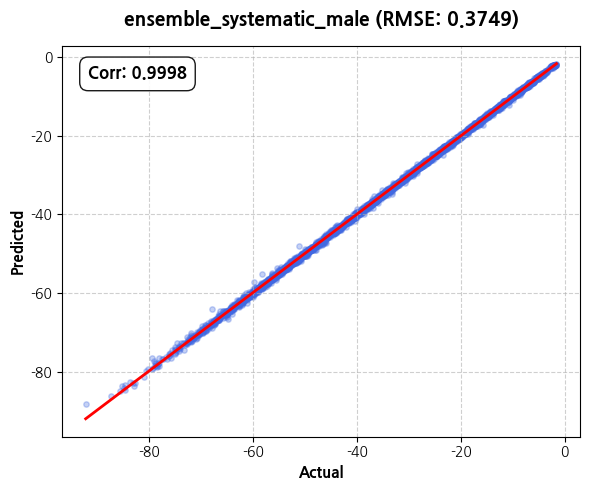

📂 기존 앙상블 모델 로드 중: ./model\ensemble_systematic_female.pkl


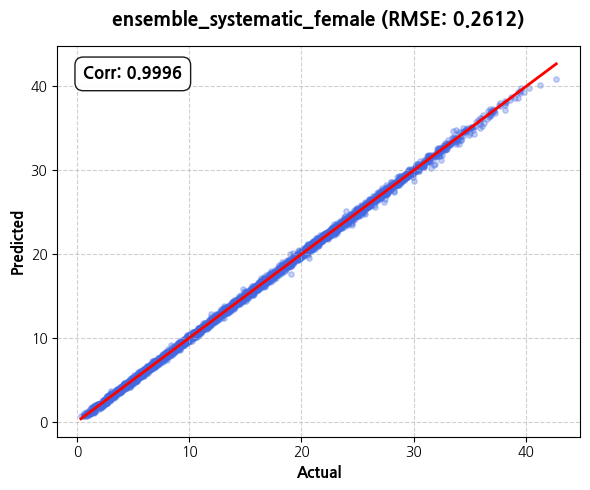

In [ ]:
# 남성(M) 데이터 전용 앙상블 모델 최적화(Optuna) 및 K-Fold 교차 검증 수행
model_male, preds_male, rmse_male = run_experiment_ensemble(
    X_male, y_male, "ensemble_systematic_male", cv=kf
)

# 여성(F) 데이터 전용 앙상블 모델 최적화(Optuna) 및 K-Fold 교차 검증 수행
model_female, preds_female, rmse_female = run_experiment_ensemble(
    X_female, y_female, "ensemble_systematic_female", cv=kf
)

In [ ]:
# 학습 완료된 남성 전용 앙상블 파이프라인 내 개별 추정기(XGBoost, RandomForest)의 최적 하이퍼파라미터 추출 및 출력
print("\n👨 [Male] XGBoost Params:")
print(model_male.named_steps['regressor'].named_estimators_['xgb'].get_params())

print("\n👨 [Male] RandomForest Params:")
print(model_male.named_steps['regressor'].named_estimators_['rf'].get_params())

# 학습 완료된 여성 전용 앙상블 파이프라인 내 개별 추정기(XGBoost, RandomForest)의 최적 하이퍼파라미터 추출 및 출력
print("\n👩 [Female] XGBoost Params:")
print(model_female.named_steps['regressor'].named_estimators_['xgb'].get_params())

print("\n👩 [Female] RandomForest Params:")
print(model_female.named_steps['regressor'].named_estimators_['rf'].get_params())


👨 [Male] XGBoost Params:
{'objective': 'reg:squarederror', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': 0.7922333572834604, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': None, 'feature_types': None, 'feature_weights': None, 'gamma': 0.3567715789920674, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': 0.06197623519432588, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 4, 'max_leaves': None, 'min_child_weight': 6, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': 1984, 'n_jobs': None, 'num_parallel_tree': None, 'random_state': None, 'reg_alpha': 0.27405517155290804, 'reg_lambda': 1.5844231833984703, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': 0.8673925193618833, 'tree_method': None, 'validate_parame

반올림 효과 분석 모델 ensemble_systematic_female
반올림 전 원본 RMSE: 0.2518
반올림 후 최종 RMSE: 0.1927


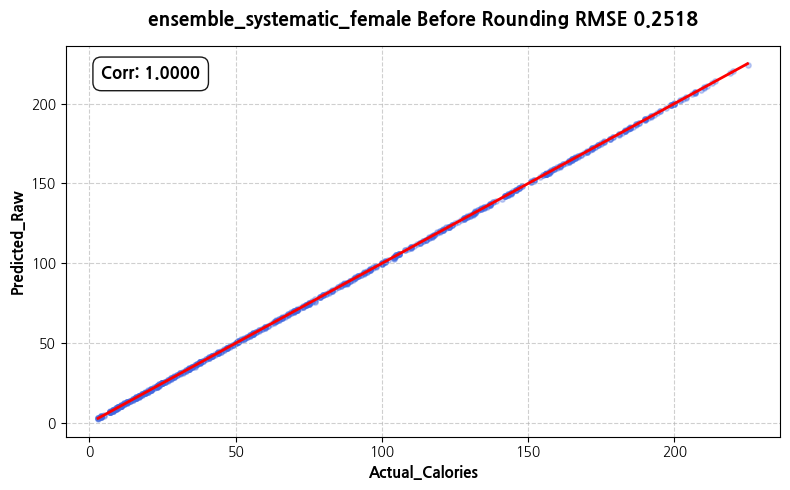

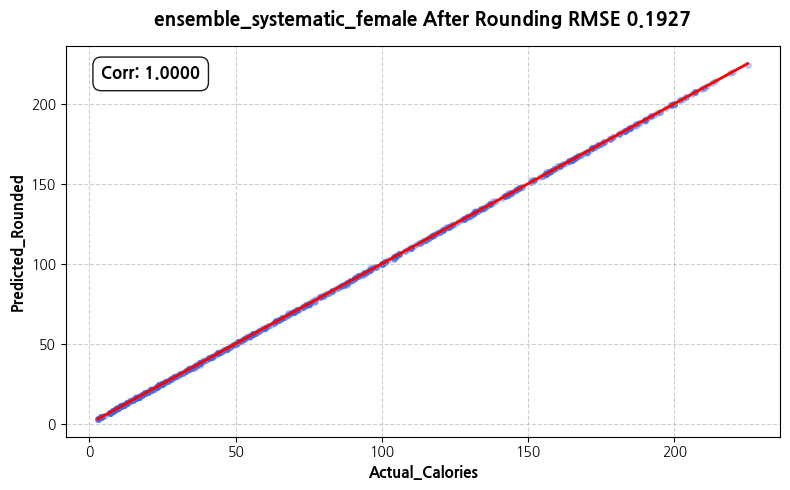

반올림 효과 분석 모델 ensemble_systematic_male
반올림 전 원본 RMSE: 0.3793
반올림 후 최종 RMSE: 0.3991


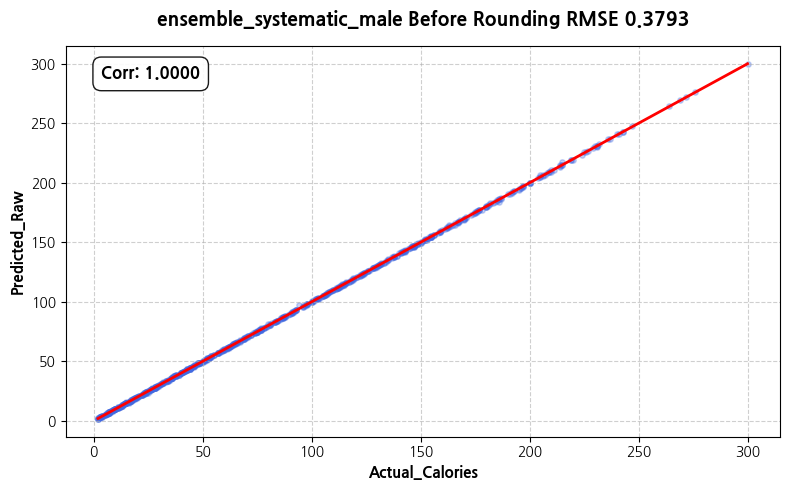

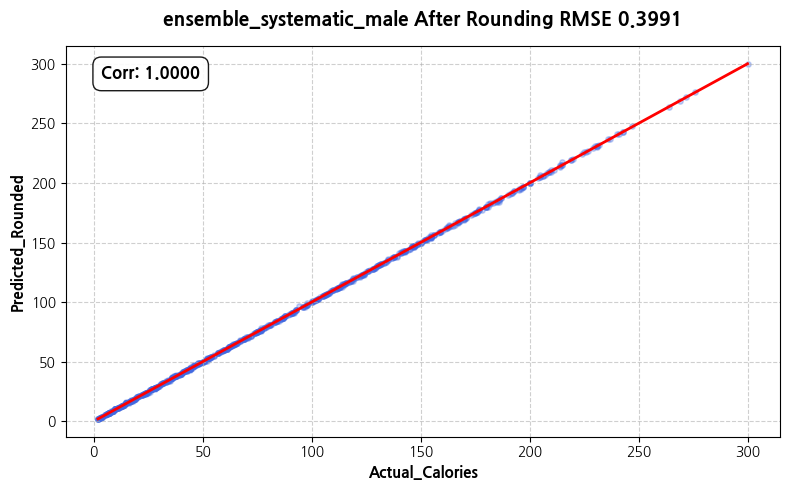

In [ ]:
# 학습된 여성 전용 앙상블 모델('ensemble_systematic_female')의 예측값 반올림 적용 전후 성능(RMSE) 비교 및 시각화
analyze_rounding_effect('ensemble_systematic_female', X_female, y_female, train)

# 학습된 남성 전용 앙상블 모델('ensemble_systematic_male')의 예측값 반올림 적용 전후 성능(RMSE) 비교 및 시각화
analyze_rounding_effect('ensemble_systematic_male', X_male, y_male, train)

# 3 GradientBoosting + RandomForest Ensemble

In [ ]:
# Scikit-Learn의 BaseEstimator와 RegressorMixin을 상속받아 사용자 정의 하이브리드 앙상블 래퍼 클래스 구축
class HybridWrapper(BaseEstimator, RegressorMixin):
    def __init__(self, models, weights, kmeans, scaler, preprocessor, keytel_col, cluster_cols):
        # 앙상블에 사용할 사전 학습된 모델, 가중치, 군집화 모델, 스케일러, 전처리기 및 주요 컬럼 정보 초기화
        self.models = models
        self.weights = weights
        self.kmeans = kmeans
        self.scaler = scaler
        self.preprocessor = preprocessor
        self.keytel_col = keytel_col
        self.cluster_cols = cluster_cols
        
    def fit(self, X, y):
        # 사전 학습된 모델들을 통합하는 용도이므로, 래퍼 자체의 별도 학습 과정 없이 객체를 반환
        return self
        
    def predict(self, X):
        # 원본 데이터 훼손 방지를 위한 복사본 생성
        X_t = X.copy()
        
        # 군집화 생성에 사용할 특정 컬럼들만 추출하여 스케일링 수행
        X_sc = self.scaler.transform(X_t[self.cluster_cols])
        
        # K-Means 군집화 예측 결과를 새로운 피처(Cluster_ID)로 추가
        X_t['Cluster_ID'] = self.kmeans.predict(X_sc)
        
        # 군집 정보가 포함된 전체 데이터에 메인 전처리기 적용
        X_ready = self.preprocessor.transform(X_t)
        
        # 예측 모델 입력 규격을 맞추기 위해 최소 행렬(Sparse Matrix) 또는 데이터프레임을 넘파이 배열로 변환
        if hasattr(X_ready, 'toarray'): X_ready = X_ready.toarray()
        elif isinstance(X_ready, pd.DataFrame): X_ready = X_ready.to_numpy()
        
        # 기존 공식 예측값(Keytel ) 배열 추출
        keytel = X_t[self.keytel_col].values
        
        # 모델별 예측 수행
        # 잔차(Residual)를 예측하도록 학습된 모델(XGB, LGBM, CatBoost)은 기본 공식(Keytel)을 더해 최종값 산출
        p_xgb = self.models['xgb'].predict(X_ready) + keytel
        p_lgbm = self.models['lgbm'].predict(X_ready) + keytel
        p_cat = self.models['cat'].predict(X_ready) + keytel
        
        # 최종 칼로리를 직접 예측하도록 학습한 모델(RandomForest)은 예측값을 그대로 사용
        p_rf = self.models['rf'].predict(X_ready)
        
        # 설정된 모델별 가중치의 전체 합산값 계산
        total_w = sum(self.weights.values())
        
        # 각 모델의 예측값에 가중치를 곱하여 합산한 뒤, 전체 가중치 합으로 나누어 최종 예측값 정규화
        final_pred = (self.weights['xgb']*p_xgb + 
                      self.weights['lgbm']*p_lgbm + 
                      self.weights['cat']*p_cat + 
                      self.weights['rf']*p_rf) / total_w
                      
        return final_pred

In [ ]:
def objective_ensemble_v2(trial, X, y, cv, keytel_col='Session_Keytel_Calories'):
    # Optuna 최적화를 위한 4개 모델(XGB, LGBM, CatBoost, RandomForest)의 하이퍼파라미터 탐색
    param_xgb = {
        'n_estimators': trial.suggest_int('xgb_n', 500, 1500),
        'max_depth': trial.suggest_int('xgb_depth', 3, 10),
        'learning_rate': trial.suggest_float('xgb_lr', 0.01, 0.1),
        'subsample': trial.suggest_float('xgb_sub', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('xgb_col', 0.6, 1.0),
        'random_state': 42, 'n_jobs': -1, 'verbosity': 0
    }
    
    param_lgbm = {
        'n_estimators': trial.suggest_int('lgbm_n', 500, 1500),
        'max_depth': trial.suggest_int('lgbm_depth', 3, 15),
        'learning_rate': trial.suggest_float('lgbm_lr', 0.01, 0.1),
        'num_leaves': trial.suggest_int('lgbm_leaves', 20, 100),
        'random_state': 42, 'n_jobs': -1, 'verbose': -1
    }
    
    param_cat = {
        'iterations': trial.suggest_int('cat_iterations', 500, 1500),
        'depth': trial.suggest_int('cat_depth', 4, 10),
        'learning_rate': trial.suggest_float('cat_lr', 0.01, 0.1),
        'random_seed': 42, 'verbose': 0, 'allow_writing_files': False
    }
    
    param_rf = {
        'n_estimators': trial.suggest_int('rf_n', 100, 300),
        'max_depth': trial.suggest_int('rf_depth', 5, 20),
        'random_state': 42, 'n_jobs': -1
    }
    
    # 앙상블에 적용할 각 모델별 가중치 탐색 및 정규화를 위한 총합 계산
    w_xgb = trial.suggest_float('w_xgb', 0.1, 1.0)
    w_lgbm = trial.suggest_float('w_lgbm', 0.1, 1.0)
    w_cat = trial.suggest_float('w_cat', 0.1, 1.0)
    w_rf = trial.suggest_float('w_rf', 0.1, 1.0)
    total_w = w_xgb + w_lgbm + w_cat + w_rf
    
    scores = []
    cluster_cols = ['Exercise_Duration', 'BPM', 'Body_Temperature(F)']

    # K-Fold 교차 검증 반복 수행
    for train_idx, val_idx in cv.split(X, y):
        X_tr, X_val = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
        
        # 지정된 변수들에 대해 스케일링 진행 후 K-Means 군집화(Cluster_ID) 피처 추가
        scaler_temp = StandardScaler()
        X_tr_cluster = scaler_temp.fit_transform(X_tr[cluster_cols])
        X_val_cluster = scaler_temp.transform(X_val[cluster_cols])
        
        kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
        X_tr['Cluster_ID'] = kmeans.fit_predict(X_tr_cluster)
        X_val['Cluster_ID'] = kmeans.predict(X_val_cluster)
        
        # 잔차 예측 모델(XGB, LightGBM, CatBoost)을 위한 타겟 변환 (실제값 - Keytel 예측값)
        keytel_tr = X_tr[keytel_col]
        keytel_val = X_val[keytel_col]
        y_tr_resid = y_tr - keytel_tr

        # 범주형/수치형 데이터 전처리 파이프라인 적용 및 배열(Array) 형태로 변환 
        preprocessor = get_preprocessor(X_tr)
        X_tr_ready = preprocessor.fit_transform(X_tr)
        X_val_ready = preprocessor.transform(X_val)
        
        if hasattr(X_tr_ready, 'toarray'): X_tr_ready = X_tr_ready.toarray()
        if hasattr(X_val_ready, 'toarray'): X_val_ready = X_val_ready.toarray()
        
        # 타겟 특성에 맞추어 각 모델 학습 (XGBoost, LightGBM, CatBoost은 잔차 학습 / RandomForest는 원본 타겟 학습)
        m_xgb = XGBRegressor(**param_xgb).fit(X_tr_ready, y_tr_resid)
        m_lgbm = LGBMRegressor(**param_lgbm).fit(X_tr_ready, y_tr_resid)
        m_cat = CatBoostRegressor(**param_cat).fit(X_tr_ready, y_tr_resid)
        m_rf = RandomForestRegressor(**param_rf).fit(X_tr_ready, y_tr)
        
        # 예측 수행 및 잔차 모델의 경우 기본값(Keytel)을 더하여 최종 칼로리 복원 
        p_xgb = m_xgb.predict(X_val_ready) + keytel_val
        p_lgbm = m_lgbm.predict(X_val_ready) + keytel_val
        p_cat = m_cat.predict(X_val_ready) + keytel_val
        p_rf = m_rf.predict(X_val_ready)
        
        # 탐색된 가중치를 곱하고 총합으로 나누어 최종 앙상블 예측값 산출 및 검증 RMSE 계산
        final_pred = (w_xgb*p_xgb + w_lgbm*p_lgbm + w_cat*p_cat + w_rf*p_rf) / total_w
        rmse = np.sqrt(mean_squared_error(y_val, final_pred))
        scores.append(rmse)
    
    # 전체 폴드의 평균 RMSE 반환 (Optuna 최소화 목표 지표)
    return np.mean(scores)

In [ ]:
def run_optuna_ensemble_v2(X_train, y_train, cv, keytel_col='Session_Keytel_Calories'):
    print(f"🚀 [Hybrid V2] 최적화 시작...")
    
    # Optuna를 활용하여 하이브리드 앙상블 모델의 하이퍼파라미터 및 가중치 최적화 수행 (30회 반복)
    study = optuna.create_study(direction='minimize')
    study.optimize(lambda trial: objective_ensemble_v2(trial, X_train, y_train, cv, keytel_col), n_trials=30)
    
    print(f"\n✅ Best RMSE: {study.best_value:.4f}")
    bp = study.best_params
    
    # 탐색된 최적 파라미터를 각 개별 모델(XGBoost, LightGBM, CatBoost, RandomForest)의 인자명에 직접 맞추어 직접 매핑
    p_xgb = {
        'n_estimators': bp['xgb_n'], 'max_depth': bp['xgb_depth'], 'learning_rate': bp['xgb_lr'],
        'subsample': bp['xgb_sub'], 'colsample_bytree': bp['xgb_col'],
        'random_state': 42, 'n_jobs': -1, 'verbosity': 0
    }
    p_lgbm = {
        'n_estimators': bp['lgbm_n'], 'max_depth': bp['lgbm_depth'], 'learning_rate': bp['lgbm_lr'],
        'num_leaves': bp['lgbm_leaves'], 'random_state': 42, 'n_jobs': -1, 'verbose': -1
    }
    p_cat = {
        'iterations': bp['cat_iterations'], 'depth': bp['cat_depth'], 'learning_rate': bp['cat_lr'],
        'random_seed': 42, 'verbose': 0, 'allow_writing_files': False
    }
    p_rf = {
        'n_estimators': bp['rf_n'], 'max_depth': bp['rf_depth'], 'random_state': 42, 'n_jobs': -1
    }
    
    # 각 모델별 최적 가중치를 추출하고, 전체 합이 1이 되도록 비율을 정규화(Nomalization)
    weights = {'xgb': bp['w_xgb'], 'lgbm': bp['w_lgbm'], 'cat': bp['w_cat'], 'rf': bp['w_rf']}
    total = sum(weights.values())
    for k in weights: weights[k] /= total
    
    print(f"⚖️ Final Weights: {weights}")
    
    # 도출된 최적 파라미터와 가중치를 바탕으로 전체 학습 데이터 대상으로 최종 모델 재학습 진행 
    print("🔄 전체 데이터로 최종 모델 재학습 중...")
    
    # 특정 컬럼 스케일링 및 K-Means 군집화(Cluster_ID) 피처 추가
    cluster_cols = ['Exercise_Duration', 'BPM', 'Body_Temperature(F)']
    scaler = StandardScaler()
    X_full_sc = scaler.fit_transform(X_train[cluster_cols])
    
    kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
    X_train_final = X_train.copy()
    X_train_final['Cluster_ID'] = kmeans.fit_predict(X_full_sc)
    
    # 통합 전처리기 적용 및 예측 모델 입력 규격(Numpy Array)에 맞춰 데이터 변환
    preprocessor = get_preprocessor(X_train_final)
    X_train_ready = preprocessor.fit_transform(X_train_final)
    
    if hasattr(X_train_ready, 'toarray'): X_train_ready = X_train_ready.toarray()
    elif isinstance(X_train_ready, pd.DataFrame): X_train_ready = X_train_ready.to_numpy()
        
    # 잔차 모델(XGBoost, LightGBM, CatBoost) 학습을 위해 실제값에서 Keytel 추정값을 뺀 잔차 타겟 생성 
    y_resid = y_train - X_train[keytel_col]
    
    # 타겟 특성에 맞춰 4개의 개별 추정기(Estimator) 최종 학습
    m_xgb = XGBRegressor(**p_xgb).fit(X_train_ready, y_resid)
    m_lgbm = LGBMRegressor(**p_lgbm).fit(X_train_ready, y_resid)
    m_cat = CatBoostRegressor(**p_cat).fit(X_train_ready, y_resid)
    m_rf = RandomForestRegressor(**p_rf).fit(X_train_ready, y_train)
    
    # 학습 완료된 모델, 스케일러, 전처리기, 정규화된 가중치 등을 모두 포함하는 최종 래퍼(Wrapper) 객체 생성
    final_model = HybridWrapper(
        models={'xgb': m_xgb, 'lgbm': m_lgbm, 'cat': m_cat, 'rf': m_rf},
        weights=weights,
        kmeans=kmeans,
        scaler=scaler,
        preprocessor=preprocessor,
        keytel_col=keytel_col,
        cluster_cols=cluster_cols
    )
    
    # 래퍼 객체를 사용한 전체 데이터 예측(참고용) 및 Optuna 탐색 과정에서의 최상의 K-Fold RMSE 도출
    val_preds = final_model.predict(X_train) 
    rmse = study.best_value
    
    print("🎉 학습 완료! 반환된 모델로 바로 predict() 하세요.")
    return final_model, val_preds, rmse

In [ ]:
def run_experiment_ensemble_v2(train_x, train_y, model_name, cv=None, keytel_col='Session_Keytel_Calories'):
    """
    하이브리드 앙상블 V2 실험 파이프라인
    내부적으로 타겟 분리(잔차 계산)을 수행하므로, train_y에 반드시 실제 칼로리 정답을 전달해야 합니다
    """
    
    # 앙상블 모델(HybridWrapper)을 저장하거나 불러올 디렉토리 및 파일 경로 설정
    save_dir = './model'
    os.makedirs(save_dir, exist_ok=True)
    save_path = os.path.join(save_dir, f'{model_name}.pkl')

    # 원본 데이터 훼손 방지를 위해 독립변수와 종속변수의 복사본 생성
    X_train = train_x.copy()
    y_train = train_y.copy() 

    is_new_model = False  
    
    # 기저장된 앙상블 모델의 존재 여부에 따라 로드 또는 신규 최적화 분기 수행
    if os.path.exists(save_path):
        print(f"📂 기존 앙상블 모델 로드 중: {save_path}")
        final_model = joblib.load(save_path)
        
        # 로드된 모델을 활용해 전체 학습 데이터에 대한 예측 및 성능(RMSE) 산출
        val_preds = final_model.predict(X_train)
        rmse = np.sqrt(mean_squared_error(y_train, val_preds))
        
    else:    
        print(f"🔥 앙상블(Hybrid V2) 모델 없음. 최적화(Optuna) 시작...")
        is_new_model = True 
        
        # 신규 모델인 경우 하이브리드 V2 전용 Optuna 함수를 호출하여 최적화, 재학습 및 성능 도출
        final_model, val_preds, rmse = run_optuna_ensemble_v2(
            X_train, y_train, cv, keytel_col
        )

    # 실제값 대비 예측값 성능 검토를 위한 데이터 병합 및 산점도 시각화
    results_df = pd.DataFrame({'Actual': y_train, 'Predicted': val_preds})
    
    # 시각화 함수(plot_scatter ) 부재로 인한 에러 발생 방지 (예외 처리)
    try:
        plot_scatter(results_df, 'Actual', 'Predicted', title=f"{model_name} (RMSE: {rmse:.4f})")
    except NameError:
        print("⚠️ plot_scatter 함수가 없어 시각화를 건너뜁니다.")

    # 새롭게 탐색 및 학습이 완료된 앙상블 모델 객체를 지정된 경로에 .pkl 파일로 저장
    if is_new_model:
        joblib.dump(final_model, save_path)
        print(f"💾 앙상블 파이프라인 저장 완료: {save_path}")
    
    # 최종 하이브리드 모델 객체, 예측 결과 배열, 오차율(RMSE) 반환
    return final_model, val_preds, rmse

Index(['Exercise_Duration', 'Body_Temperature(F)', 'BPM', 'Gender', 'Age',
       'Weight(kg)', 'Height(cm)', 'Height(m)', 'BMI', 'BMR_Harris',
       'RMR_Mifflin', 'BPM_Multiplier', 'Session_Harris_Calories',
       'Session_Mifflin_Calories', 'Session_Keytel_Calories',
       'Intensity_Level', 'Duration_Category', 'Session_Type', 'Temp_Excess',
       'Thermal_Intensity', 'Heat_Energy_Proxy'],
      dtype='object')
📂 기존 앙상블 모델 로드 중: ./model\ensemble_hybrid_v2.pkl


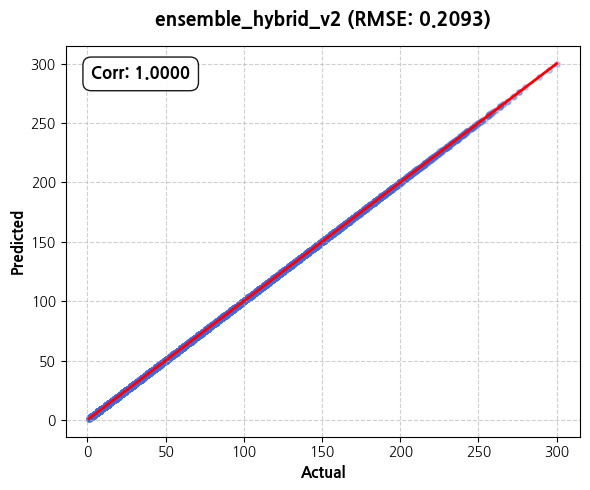


⚖️  [Hybrid Ensemble V2] 최적 가중치 분석
 • CAT       : 0.3760  (37.6%)
 • LGBM      : 0.3632  (36.3%)
 • XGB       : 0.1851  (18.5%)
 • RF        : 0.0757  (7.6%)

🛠️  [Hybrid Ensemble V2] 모델별 하이퍼파라미터

🔹 [XGB] Best Params:
{'objective': 'reg:squarederror', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': 0.9991828066505518, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': None, 'feature_types': None, 'feature_weights': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': 0.08169383436162603, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 9, 'max_leaves': None, 'min_child_weight': None, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': 1008, 'n_jobs': -1, 'num_parallel_tree': None, 'random_state': 42, 'reg_alpha'

In [ ]:
# 5-Fold 교차 검증(K-Fold) 객체 생성 (데이터 셔플링 적용 및 난수 시드 고정)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# 학습에 사용될 정제된 데이터의 피처(컬럼) 구성 최종 확인
print(train_x_refined_v1.columns)

# 전체 데이터를 대상으로 하이브리드 앙상블 V2 파이프라인(최적화 및 재학습) 실행
# V2 로직에 따라 타겟 변수에는 잔차가 아닌 실제 칼로리 정답(train_y)을 전달
final_model, preds, score = run_experiment_ensemble_v2(
    train_x = train_x_refined_v1,    
    train_y = train_y, 
    model_name = 'ensemble_hybrid_v2', 
    cv = kf,                                   
    keytel_col = 'Session_Keytel_Calories'
)

print("\n" + "="*50)
print("⚖️  [Hybrid Ensemble V2] 최적 가중치 분석")
print("="*50)

# 산출된 개별 모델의 가중치를 내림차순으로 정렬하여 기여도(%)와 함께 출력
sorted_weights = sorted(final_model.weights.items(), key=lambda x: x[1], reverse=True)

for model_name, weight in sorted_weights:
    print(f" • {model_name.upper():<10}: {weight:.4f}  ({weight*100:.1f}%)")

print("\n" + "="*50)
print("🛠️  [Hybrid Ensemble V2] 모델별 하이퍼파라미터")
print("="*50)

# 앙상블 래퍼(HybridWrapper) 내부에 저장된 개별 추정기(XGB, LightGBM, Cat, RandomForest)의 최종 하이퍼파라미터 추출 및 출력 
for key, model_obj in final_model.models.items():
    print(f"\n🔹 [{key.upper()}] Best Params:")
    print(model_obj.get_params())

In [ ]:
def analyze_rounding_effect_ensemble_v2(model_name, X, y):
    """
    하이브리드 앙상블 V2 모델 전용 예측값 반올림 효과 분석
    모델 내부에서 이미 최종 칼로리 값이 반환되므로 기존 공식(Keytel) 추정치를 중복 합산하지 않음
    """
    
    # 지정된 경로에서 학습 완료된 하이브리드 V2 모델 객체 로드
    save_path = f'./model/{model_name}.pkl'
    if not os.path.exists(save_path):
        print(f"❌ 모델 파일이 없습니다: {save_path}")
        return

    print(f"📂 모델 로드 중: {model_name}")
    loaded_model = joblib.load(save_path)

    # 평가 데이터에 대한 최종 칼로리 예측 (모델 자체에서 가중치 정규화 및 Keytel 병합 완료)
    pred_raw = loaded_model.predict(X)
    
    # 원본 예측값 반올림 처리
    pred_rounded = np.round(pred_raw)

    # 반올림 적용 전과 후의 예측값에 대한 각각의 오차율(RMSE) 산출
    rmse_raw = np.sqrt(mean_squared_error(y, pred_raw))
    rmse_rounded = np.sqrt(mean_squared_error(y, pred_rounded))

    # 산출된 성능 평가 결과 화면 출력
    print(f"\n📊 [분석 결과] {model_name}")
    print(f" - 반올림 전 RMSE: {rmse_raw:.4f}")
    print(f" - 반올림 후 RMSE: {rmse_rounded:.4f}")
    print("-" * 30)

    # 시각화를 위한 실제값 및 원본/반올림 예측값 데이터프레임 구성
    df_res = pd.DataFrame({
        'Actual': y.values if hasattr(y, 'values') else y,
        'Predicted_Raw': pred_raw,
        'Predicted_Rounded': pred_rounded
    })

    # 반올람 적용 전(Raw) 실제값 대비 예측값 산점도 시각화 
    try:
        print("📈 1. 반올림 전 (Raw) 산점도")
        plot_scatter(
            df=df_res, 
            x_col='Actual', 
            y_col='Predicted_Raw', 
            title=f"{model_name} [Before Rounding] RMSE: {rmse_raw:.4f}",
            figsize=(6, 6)
        )
    except NameError:
        print("⚠️ plot_scatter 함수가 없습니다.")

    # 반올리 적용 후(Rounded) 실제값 대비 예측값 산점도 시각화 
    try:
        print("📈 2. 반올림 후 (Rounded) 산점도")
        plot_scatter(
            df=df_res, 
            x_col='Actual', 
            y_col='Predicted_Rounded', 
            title=f"{model_name} [After Rounding] RMSE: {rmse_rounded:.4f}",
            figsize=(6, 6)
        )
    except NameError:
        pass

📂 모델 로드 중: ensemble_hybrid_v2

📊 [분석 결과] ensemble_hybrid_v2
 - 반올림 전 RMSE: 0.2093
 - 반올림 후 RMSE: 0.1249
------------------------------
📈 1. 반올림 전 (Raw) 산점도


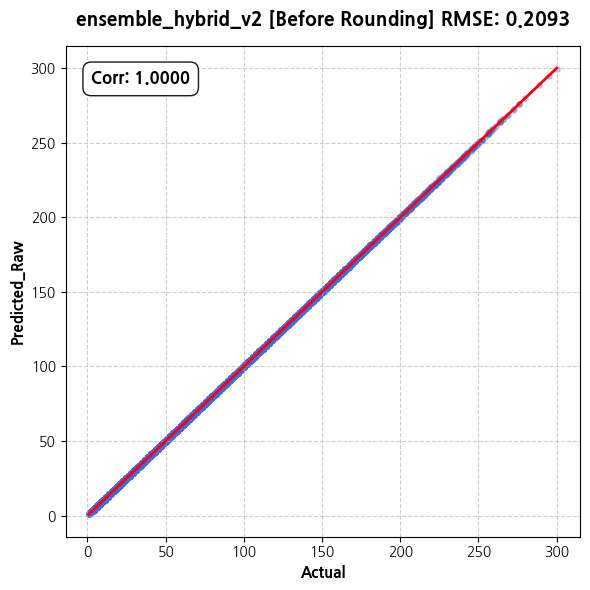

📈 2. 반올림 후 (Rounded) 산점도


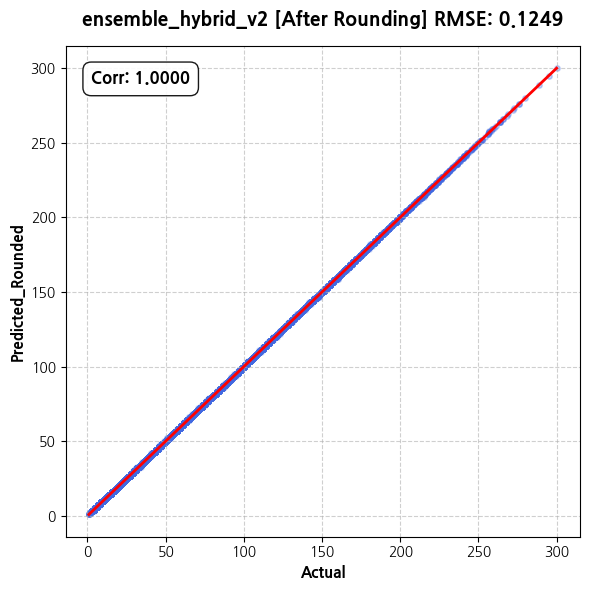

In [ ]:
# 학습된 하이브리드 앙상블 V2 모델의 예측값 반올림 적용 전후 성능(RMSE) 비교 및 시각화
analyze_rounding_effect_ensemble_v2('ensemble_hybrid_v2', train_x_refined_v1, train_y)

In [ ]:
def analyze_feature_importance_ensemble_v2(model_name):  
    # 지정된 경로에서 사전 학습된 하이브리드 V2 앙상블 모델 파일 로드
    model_path = f'./model/{model_name}.pkl'
    
    if not os.path.exists(model_path):
        print(f"❌ 모델 파일이 존재하지 않습니다: {model_path}")
        return
    
    print(f"📂 앙상블 모델 로드 중: {model_name}")
    loaded_model = joblib.load(model_path)
    
    # 파이프라인 내 전처리기(ColumnTransformer 등)를 통해 변환이 완료된 최종 피처명 추출
    try:
        feature_names = loaded_model.preprocessor.get_feature_names_out()
    except:
        print("⚠️ 피처 이름을 자동으로 가져오는데 실패했습니다.")
        return

    # 앙상블 내부 다중 추정기 중 RandomForest 모델의 피처 중요도 추출
    rf_model = loaded_model.models['rf']
    importances = rf_model.feature_importances_
    
    # 추출된 피처 중요도 배열과 피처명 리스트의 길이 일치 여부 검증
    if len(importances) != len(feature_names):
        print(f"❌ 피처 개수 불일치! (Importances: {len(importances)}, Names: {len(feature_names)})")
        return
    
    # 피처명과 중요도를 데이터프레임으로 묶어 중요도 기준 내림차순 정렬
    fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
    fi_df = fi_df.sort_values(by='Importance', ascending=False)
    
    # 정렬된 피처 중요도 결과(상위 20개)를 텍스트 형식으로 화면에 출력
    print("-" * 30)
    print(f"📊 [Feature Importance (by Random Forest)]")
    print("-" * 30)
    print(fi_df.head(20).to_string(index=False))
    
    # 상위 20개 피처에 대한 중요도를 막대 그래프(Bar Plot)로 시각화
    plt.figure(figsize=(10, 8))
    sns.barplot(x='Importance', y='Feature', data=fi_df.head(20), hue='Feature', palette='viridis', legend=False)
    plt.title(f'Feature Importance: {model_name} (RF Component)', fontsize=15)
    plt.xlabel('Importance Score')
    plt.ylabel('Features')
    plt.tight_layout()
    plt.show()

📂 앙상블 모델 로드 중: ensemble_hybrid_v2
------------------------------
📊 [Feature Importance (by Random Forest)]
------------------------------
                      Feature  Importance
       num__Exercise_Duration    0.801693
              num__Cluster_ID    0.098695
 num__Session_Keytel_Calories    0.056130
        ord_cat__Session_Type    0.013643
                     num__BPM    0.010537
                     num__Age    0.007133
   ord_cat__Duration_Category    0.004725
             num__RMR_Mifflin    0.001685
              num__BMR_Harris    0.001679
          num__BPM_Multiplier    0.000897
       num__Thermal_Intensity    0.000705
            nom_cat__Gender_M    0.000523
     ord_cat__Intensity_Level    0.000466
       num__Heat_Energy_Proxy    0.000284
 num__Session_Harris_Calories    0.000252
              num__Weight(kg)    0.000224
                     num__BMI    0.000207
num__Session_Mifflin_Calories    0.000196
               num__Height(m)    0.000093
              num__Hei

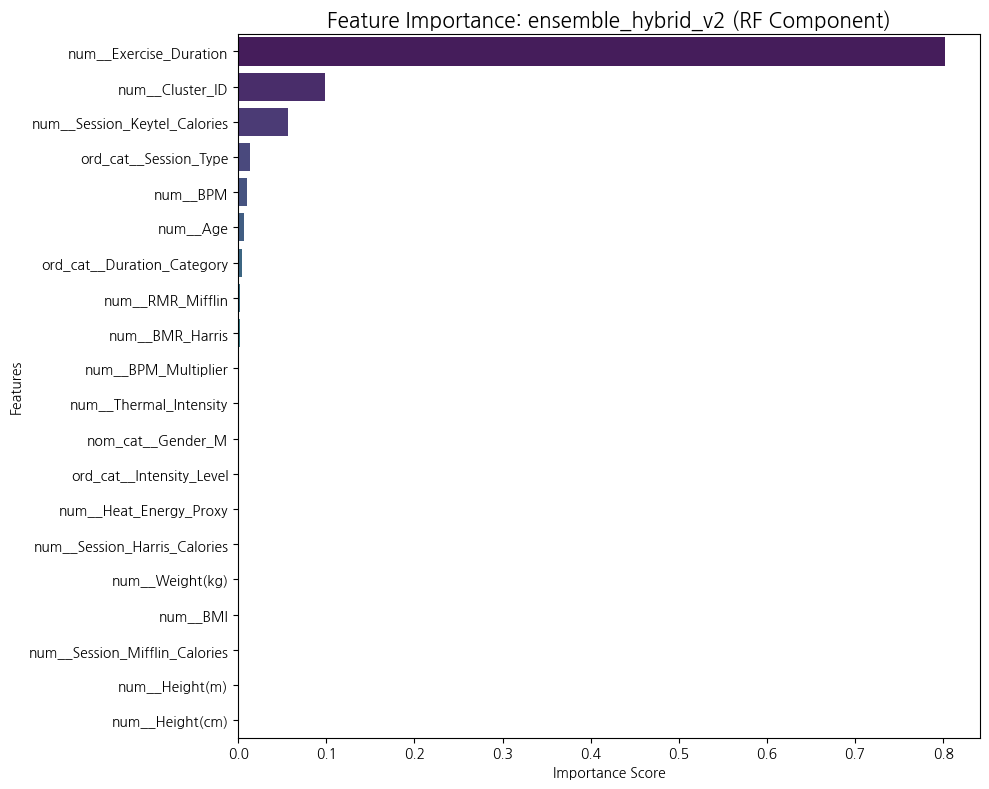

In [ ]:
# 학습 완료된 하이브리드 V2 앙상블 모델의 피처 중요도 분석 및 시각화
analyze_feature_importance_ensemble_v2('ensemble_hybrid_v2')

In [ ]:
def generate_submission_ensemble_v2(test_df, model_name):
    """
    학습된 하이브리드 앙상블 V2 모델을 활용하여
    최종 테스트 데이터 추론 및 데이콘 제출용 CSV 파일을 생성하는 함수
    """
    
    # 제출 양식에 필요한 식별자(ID) 컬럼 분리 및 추론용 독립변수 데이터프레임(test_x) 구성
    # 파이프라인에서 불필요한 피처 제거가 처리되므로 원본 피처 구조를 유지하여 전달
    submission_ids = test_df['ID']
    test_x = test_df.drop(columns=['ID'], errors='ignore')

    # 지정된 경로에서 사전 학습 및 직렬화된 앙상블 V2 파이프라인 객체(.pkl) 구조
    model_path = f"./model/{model_name}.pkl"
    if not os.path.exists(model_path):
        print(f"❌ 모델 파일이 없습니다: {model_path}")
        return None
        
    print(f"📂 모델 로드 중: {model_name}")
    loaded_model = joblib.load(model_path)

    # 평가 데이터(test_x)에 대한 최종 칼로리 소모량 예측 수행
    # V2 모델(HybridWrapper) 내부에서 가중치 정규화 및 기존 공식(Keytel) 합산이 완료되므로 별도 처리 없이 그대로 사용
    print("🔍 테스트 데이터 예측 중...")
    test_pred = loaded_model.predict(test_x)

    # 예측 결과 배열과 사전 분리해둔 ID 식별자를 매핑하여 최종 제출용 데이터프레임 구축
    submission = pd.DataFrame({
        'ID': submission_ids,
        'Calories_Burned': test_pred
    })

    #  물리적으로 판별할 수 없는 음수 칼로리 소모량을 0으로 하한값 보정
    submission['Calories_Burned'] = submission['Calories_Burned'].clip(lower=0)
    
    # 타겟 변수의 일반적인 정수 형태에 맞추어 소수점 반올림 처리
    submission['Calories_Burned'] = np.round(submission['Calories_Burned']) 

    # 최종 결과물 저장을 위한 디렉토리 생성 및 지정된 경로에 CSV 포맷으로 파일 출력 (인덱스 제외)
    save_dir = './data/submission/'
    os.makedirs(save_dir, exist_ok=True)
    save_path = f"{save_dir}submission_{model_name}.csv"

    submission.to_csv(save_path, index=False)

    print(f"🎉 성공적으로 저장되었습니다: {save_path}")
    print(submission.head())
    
    return submission

In [ ]:
# 사전 정제가 완료된 최종 테스트 데이터를 입력하여 데이콘 제출용 CSV 파일 생성
generate_submission_ensemble_v2(
    test_df=test_x_refined_v1, 
    model_name='ensemble_hybrid_v2'
)

📂 모델 로드 중: ensemble_hybrid_v2
🔍 테스트 데이터 예측 중...
🎉 성공적으로 저장되었습니다: ./data/submission/submission_ensemble_hybrid_v2.csv
          ID  Calories_Burned
0  TEST_0000            173.0
1  TEST_0001            190.0
2  TEST_0002             54.0
3  TEST_0003            161.0
4  TEST_0004            225.0


,ID,Calories_Burned
0,TEST_0000,173.0
1,TEST_0001,190.0
2,TEST_0002,54.0
3,TEST_0003,161.0
4,TEST_0004,225.0
...,...,...
7495,TEST_7495,197.0
7496,TEST_7496,10.0
7497,TEST_7497,130.0
7498,TEST_7498,32.0


# Stacking
- 1차: Gradient Boosting 3종 + RandomForest로 잔차 학습
- 2차: RidgeCV로 최종 학습

In [ ]:
# Scikit-learn의 BaseEstimator와 RegressorMixin을 상속받아 스태킹(Stacking) 앙상블 모델을 서빙하기 위한 커스텀 래퍼 클래스 구축 
class StackingWrapper(BaseEstimator, RegressorMixin):
    def __init__(self, stacking_model, kmeans, scaler, preprocessor, keytel_col, cluster_cols):
        # 학습이 완료된 메타 모델(Stacking), K-Means 군집화 객체, 스케일러, 전처리기 및 타겟 복원을 위한 기준(Keytel) 컬럼 초기화 
        self.stacking_model = stacking_model
        self.kmeans = kmeans
        self.scaler = scaler
        self.preprocessor = preprocessor
        self.keytel_col = keytel_col
        self.cluster_cols = cluster_cols
        
    def fit(self, X, y):
        # 모든 모델과 전처리기가 외부에서 이미 학습된 상태로 주입되므로, 별도의 재학습 없이 래퍼 객체 자신을 반환
        return self
        
    def predict(self, X):
        # 원본 테스트 데이터의 훠ㅔ손을 방지하기 위해 복사본 생성
        X_t = X.copy()
        
        # 파생 변수 생성 (군집화)
        # 지정된 수치형 컬럼들(cluster_cols)에 대해 스케일링을 적용한 후, 사전 학습된 K-Means로 군집을 예측하여 'Cluster_ID' 변수 추가
        X_sc = self.scaler.transform(X_t[self.cluster_cols])
        X_t['Cluster_ID'] = self.kmeans.predict(X_sc)
        
        # 메인 데이터 전처리
        # 군집 정보가 포함된 전체 데이터셋에 대해 원-핫 인코딩 등 메인 전처리기 파이프라인 적용
        X_ready = self.preprocessor.transform(X_t)
        
        # 스태킹 모델의 입력 데이터 규격 오류를 방지하기 위해 희소 행렬(Sparse Matrix)이나 데이터프레임을 Numpy 배열(Array) 형식으로 통일
        if hasattr(X_ready, 'toarray'): X_ready = X_ready.toarray()
        elif isinstance(X_ready, pd.DataFrame): X_ready = X_ready.to_numpy()
            
        # 메타 모델(Stacking) 예측
        # 전처리가 완료된 배열 데이터를 스태킹 앙상블 모델에 통과시켜 잔차(Residual) 값을 예측
        pred_resid = self.stacking_model.predict(X_ready)
        
        # 최종 칼로리 소모량 복원
        # 원본 데이터에서 베이스라인 추정치인 기존 공식(Keytel) 배열을 추출하여, 모델이 예측한 잔차에 더해 최종 예측값 산출
        keytel = X_t[self.keytel_col].values
        final_pred = pred_resid + keytel
        
        return final_pred

In [ ]:
def objective_stacking_v3(trial, X, y, cv, keytel_col='Session_Keytel_Calories'):
    """
    Optuna 최적화를 위한 스태킹(Stacking) 앙상블 V3 목적 함수
    개별 가중치를 Optuna로 탐색하지 않고, 2차 메타 모델(Meta Model)이 1차 모델들의 예측 결과를 학습하여 최적의 조합을 도출함
    """
    # 1차 모델(Base Models)을 위한 하이퍼파라미터 탐색 공간 정의
    param_xgb = {
        'n_estimators': trial.suggest_int('xgb_n', 500, 1500),
        'max_depth': trial.suggest_int('xgb_depth', 3, 10),
        'learning_rate': trial.suggest_float('xgb_lr', 0.01, 0.1),
        'subsample': trial.suggest_float('xgb_sub', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('xgb_col', 0.6, 1.0),
        'random_state': 42, 'n_jobs': -1, 'verbosity': 0
    }
    
    param_lgbm = {
        'n_estimators': trial.suggest_int('lgbm_n', 500, 1500),
        'max_depth': trial.suggest_int('lgbm_depth', 3, 15),
        'learning_rate': trial.suggest_float('lgbm_lr', 0.01, 0.1),
        'num_leaves': trial.suggest_int('lgbm_leaves', 20, 100),
        'random_state': 42, 'n_jobs': -1, 'verbose': -1
    }
    
    param_cat = {
        'iterations': trial.suggest_int('cat_iterations', 500, 1500),
        'depth': trial.suggest_int('cat_depth', 4, 10),
        'learning_rate': trial.suggest_float('cat_lr', 0.01, 0.1),
        'random_seed': 42, 'verbose': 0, 'allow_writing_files': False
    }
    
    param_rf = {
        'n_estimators': trial.suggest_int('rf_n', 100, 300),
        'max_depth': trial.suggest_int('rf_depth', 5, 20),
        'random_state': 42, 'n_jobs': -1
    }
    
    # 1차 모델(Base Estimator) 파이프라인 리스트 구성
    estimators = [
        ('xgb', XGBRegressor(**param_xgb)),
        ('lgbm', LGBMRegressor(**param_lgbm)),
        ('cat', CatBoostRegressor(**param_cat)),
        ('rf', RandomForestRegressor(**param_rf))
    ]
    
    # 2차 모델 (Meta Model) 정의
    # RidgeCV를 사용하여 교차 검증 기반으로 최적의 L2 규제 강도(Alpha)를 자동 탐색
    final_estimator = RidgeCV()
    
    # 최종 스태킹 회귀 모델(Stacking Regressor) 객체 생성
    reg = StackingRegressor(
        estimators=estimators,
        final_estimator=final_estimator,
        cv=3, # 내부적으로 3-Fold를 수행하여 Out-of-Fold(OOF) 예측값을 메타 모델의 학습 데이터로 생성
        passthrough=True, # 1차 모델의 예측값뿐만 아니라 원본 입력 데이터(X)도 메타 모델에 함께 전달하여 학습 고도화
        n_jobs=-1 
    )
    
    # 외부 K-Fold 교차 검증을 통한 파이프라인 성능 평가
    scores = []
    cluster_features = ['Exercise_Duration', 'BPM', 'Body_Temperature(F)'] 

    for train_idx, val_idx in cv.split(X, y):
        # 학습 및 검증 데이터 분할
        X_tr, X_val = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
        
        # 튻정 피처 스케일링 및 K-Means 기반 군집화(Cluster_ID) 변수 파생
        scaler_temp = StandardScaler()
        X_tr_cluster = scaler_temp.fit_transform(X_tr[cluster_features])
        X_val_cluster = scaler_temp.transform(X_val[cluster_features])
        
        kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
        X_tr['Cluster_ID'] = kmeans.fit_predict(X_tr_cluster)
        X_val['Cluster_ID'] = kmeans.predict(X_val_cluster)
        
        # 잔차 타겟 분리
        # 스태킹 결합의 일관성을 위해 1차 모두가 잔차(실제값 - Keytel 예측치)를 학습하도록 타겟 통일
        keytel_tr = X_tr[keytel_col]
        keytel_val = X_val[keytel_col]
        y_tr_resid = y_tr - keytel_tr  

        # 메인 전처리 파이프라인 적용 및 규격(Array) 변환
        preprocessor = get_preprocessor(X_tr)
        X_tr_ready = preprocessor.fit_transform(X_tr)
        X_val_ready = preprocessor.transform(X_val)
        
        if hasattr(X_tr_ready, 'toarray'): X_tr_ready = X_tr_ready.toarray()
        if hasattr(X_val_ready, 'toarray'): X_val_ready = X_val_ready.toarray()
        
        # 스태킹 파이프라인 일괄 학습
        # 1차 모델 학습 -> OOF 예측 생성 -> 메타 모델 학습이 내부적으로 순차 처리
        reg.fit(X_tr_ready, y_tr_resid)
        
        # 검증 데이터에 대한 최종 잔차 예측 및 베이스라인(Keytel) 합산을 통한 최종 칼로리 복원
        pred_resid = reg.predict(X_val_ready)
        final_pred = pred_resid + keytel_val
        
        # 폴드별 RMSE 성능 기록
        rmse = np.sqrt(mean_squared_error(y_val, final_pred))
        scores.append(rmse)
    
    # 전체 폴드 평균 RMSE 반환 
    return np.mean(scores)

In [ ]:
def run_stacking_ensemble_v3(X_train, y_train, cv, keytel_col='Session_Keytel_Calories'):
    """
    Optuna를 활용하여 스태킹 V3 앙상블 모델의 하이퍼파라미터를 최적화하고,
    최적 파라미터로 전체 데이터를 재학습하여 최종 래퍼(Wrapper) 객체를 반환하는 실행 함수
    """
    print(f"🚀 [Stacking V3] 최적화 시작 (메타 모델: Ridge)...")
    
    # Optuna를 활용한 30회 반복 하이퍼파라미터 최적화 수행
    study = optuna.create_study(direction='minimize')
    study.optimize(lambda trial: objective_stacking_v3(trial, X_train, y_train, cv, keytel_col), n_trials=30)
    
    print(f"\n✅ Best RMSE: {study.best_value:.4f}")
    bp = study.best_params
    
    # 개별 회귀 모델에 적용할 최적 파라미터 매핑
    p_xgb = {
        'n_estimators': bp['xgb_n'], 'max_depth': bp['xgb_depth'], 'learning_rate': bp['xgb_lr'],
        'subsample': bp['xgb_sub'], 'colsample_bytree': bp['xgb_col'],
        'random_state': 42, 'n_jobs': -1, 'verbosity': 0
    }
    p_lgbm = {
        'n_estimators': bp['lgbm_n'], 'max_depth': bp['lgbm_depth'], 'learning_rate': bp['lgbm_lr'],
        'num_leaves': bp['lgbm_leaves'], 'random_state': 42, 'n_jobs': -1, 'verbose': -1
    }
    p_cat = {
        'iterations': bp['cat_iterations'], 'depth': bp['cat_depth'], 'learning_rate': bp['cat_lr'],
        'random_seed': 42, 'verbose': 0, 'allow_writing_files': False
    }
    p_rf = {
        'n_estimators': bp['rf_n'], 'max_depth': bp['rf_depth'], 'random_state': 42, 'n_jobs': -1
    }
    
    print("🔄 전체 데이터로 스태킹 모델 최종 재학습 중...")
    
    # K-Means 군집화를 위한 파생 변수 스케일링 및 생성
    cluster_cols = ['Exercise_Duration', 'BPM', 'Body_Temperature(F)']
    scaler = StandardScaler()
    X_full_sc = scaler.fit_transform(X_train[cluster_cols])
    
    kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
    X_train_final = X_train.copy()
    X_train_final['Cluster_ID'] = kmeans.fit_predict(X_full_sc)
    
    # 전체 데이터 대상 통합 전처리 파이프라인 적용 
    preprocessor = get_preprocessor(X_train_final)
    X_train_ready = preprocessor.fit_transform(X_train_final)
    
    if hasattr(X_train_ready, 'toarray'): X_train_ready = X_train_ready.toarray()
    elif isinstance(X_train_ready, pd.DataFrame): X_train_ready = X_train_ready.to_numpy()
        
    # 모델 학습용 잔차(Residual) 타겟 분리
    y_resid = y_train - X_train[keytel_col]
    
    # 1차 추정기(Base Models) 및 2차 메타 모델(RidgeCV) 정의
    estimators = [
        ('xgb', XGBRegressor(**p_xgb)),
        ('lgbm', LGBMRegressor(**p_lgbm)),
        ('cat', CatBoostRegressor(**p_cat)),
        ('rf', RandomForestRegressor(**p_rf))
    ]
    
    final_estimator = RidgeCV()
    
    # 최종 스태킹 앙상블 모델 구축 및 학습 (원본 피처 정보 전달 옵션 활성화)
    reg = StackingRegressor(
        estimators=estimators,
        final_estimator=final_estimator,
        cv=5,              
        passthrough=True,   
        n_jobs=-1
    )
    
    reg.fit(X_train_ready, y_resid)
    
    # 전처리 및 모델 객체를 통합한 커스텀 래퍼 클래스 생성
    final_model = StackingWrapper(
        stacking_model=reg,
        kmeans=kmeans,
        scaler=scaler,
        preprocessor=preprocessor,
        keytel_col=keytel_col,
        cluster_cols=cluster_cols
    )
    
    # 최종 모델 검증을 위한 예측 수행 및 최적 RMSE 기록
    val_preds = final_model.predict(X_train) 
    rmse = study.best_value
    
    print("🎉 학습 완료! Stacking V3 모델이 생성되었습니다.")
    return final_model, val_preds, rmse

In [ ]:
def run_experiment_ensemble_v3(train_x, train_y, model_name, cv=None, keytel_col='Session_Keytel_Calories'):
    """
    스태킹 앙상블 실험 관리를 위한 파이프라인 함수
    기존에 학습된 모델 파일이 존재하면 로드하여 평가하고, 없을 경우 새로운 최적화 및 학습을 수행
    """
    
    # 모델 저장 디렉토리 및 파일 경로 지정
    save_dir = './model'
    os.makedirs(save_dir, exist_ok=True)
    save_path = os.path.join(save_dir, f'{model_name}.pkl')

    # StackingWrapper 내부에서 전처리가 진행되므로 원본 데이터의 훼손을 방지하기 위해 복사본 할당
    X_train = train_x.copy()
    y_train = train_y.copy()

    is_new_model = False  
    
    # 기저장된 스태킹 모델 파일(.pkl) 존재 여부에 따른 분기 처리
    if os.path.exists(save_path):
        print(f"📂 기존 스태킹 모델 로드 중: {save_path}")
        final_model = joblib.load(save_path)
        
        # 로드된 래퍼 객체를 사용해 검증 예측 수행 (내부적으로 전처리, 잔차 예측, 기준값 복원 일괄 처리)
        val_preds = final_model.predict(X_train)
        rmse = np.sqrt(mean_squared_error(y_train, val_preds))
        
    else:    
        print(f"🔥 스태킹(Stacking V3) 모델 없음. 최적화 및 학습 시작...")
        is_new_model = True 
        
        # 신규 모델인 경우 Optuna 기반 스태킹 최적화 및 학습 수행
        final_model, val_preds, rmse = run_stacking_ensemble_v3(
            X_train, y_train, cv, keytel_col
        )

    # 파이프라인 성능 점검을 위한 실제값 대비 예측값 시각화 데이터 구성
    results_df = pd.DataFrame({'Actual': y_train, 'Predicted': val_preds})
    
    try:
        plot_scatter(results_df, 'Actual', 'Predicted', title=f"{model_name} (RMSE: {rmse:.4f})")
    except NameError:
        print("⚠️ plot_scatter 함수가 없어 시각화를 건너뜁니다.")

    # 새롭게 학습이 완료된 스태킹 파이프라인 전체를 직렬화하여 지정된 경로에 보존
    if is_new_model:
        joblib.dump(final_model, save_path)
        print(f"💾 스태킹 파이프라인 저장 완료: {save_path}")
    
    # 최종 학습 객체, 예측 결과, 그리고 오차율 반환
    return final_model, val_preds, rmse

📂 기존 스태킹 모델 로드 중: ./model\ensemble_stacking_v3.pkl


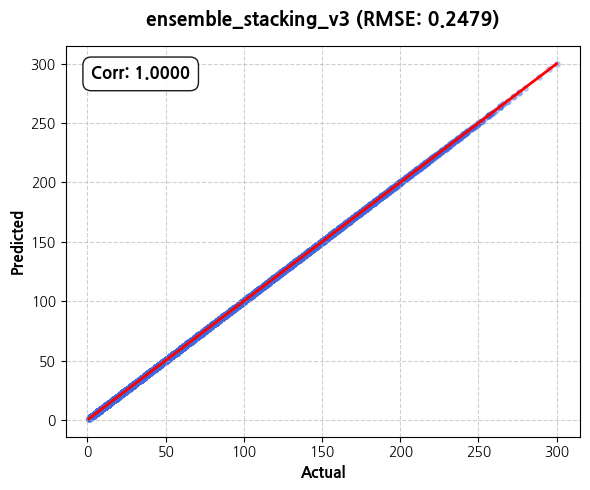


🧠 [Stacking V3] 메타 모델 (RidgeCV) 분석
 • 선택된 규제 강도 (Alpha): 10.0000

⚖️ 1차 모델 예측값에 부여된 회귀 계수 (가중치 흐름):
 • XGB   : 0.1534
 • LGBM  : 0.3334
 • CAT   : 0.5599
 • RF    : -0.0469

🛠️ [Stacking V3] 1차 모델(Base Models) 하이퍼파라미터

🔹 [XGB] Best Params:
{'objective': 'reg:squarederror', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': 0.8251233005739006, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': None, 'feature_types': None, 'feature_weights': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': 0.019687327541606944, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 5, 'max_leaves': None, 'min_child_weight': None, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': 1074, 'n_jobs': -1, 'num_parallel_tree': None, 'random_

In [ ]:
# 사전 정제된 전체 학습 데이터와 K-Fold 객체를 전달하여 스태킹 V3 파이프라인 실행
final_model, preds, score = run_experiment_ensemble_v3(
    train_x=train_x_refined_v1,
    train_y=train_y,
    model_name='ensemble_stacking_v3',
    cv=kf,
    keytel_col='Session_Keytel_Calories'
)

print("\n" + "="*50)
print("🧠 [Stacking V3] 메타 모델 (RidgeCV) 분석")
print("="*50)

# 파이프라인 내부의 StackingRegressor 객체에서 2차 메타 모델인 RidgeCV 추출
ridge_meta_model = final_model.stacking_model.final_estimator_

# 교차 검증을 통해 RidgeCV가 자체적으로 도출한 최적의 L2 규제 강도 출력
print(f" • 선택된 규제 강도 (Alpha): {ridge_meta_model.alpha_:.4f}")

# passthrough=True 설정으로 인해 데이터 배열 최상단에 배치된 1차 모델(XGB, LGBM, CAT, RF)의 회귀 계수(가중치) 추출
meta_coefs = ridge_meta_model.coef_[:4] 
model_names = ['XGB', 'LGBM', 'CAT', 'RF']

print("\n⚖️ 1차 모델 예측값에 부여된 회귀 계수 (가중치 흐름):")
for name, coef in zip(model_names, meta_coefs):
    print(f" • {name:<5} : {coef:.4f}")

print("\n" + "="*50)
print("🛠️ [Stacking V3] 1차 모델(Base Models) 하이퍼파라미터")
print("="*50)

# 1차 추정기 딕셔너리에 접근하여 기반 모델별 최종 최적화 하이퍼파라미터 일괄 출력
estimators = final_model.stacking_model.named_estimators_

for name in model_names:
    print(f"\n🔹 [{name}] Best Params:")
    print(estimators[name.lower()].get_params())

📂 모델 로드 중: ensemble_stacking_v3

📊 [분석 결과] ensemble_stacking_v3
 - 반올림 전 RMSE: 0.2479
 - 반올림 후 RMSE: 0.1883
------------------------------
📈 1. 반올림 전 (Raw) 산점도


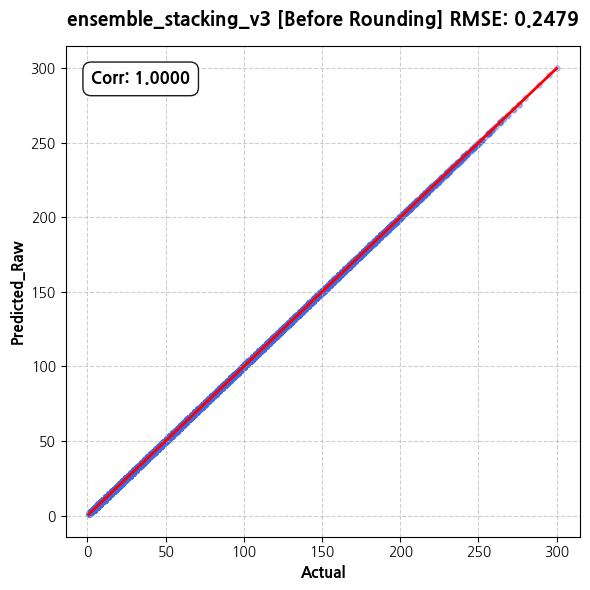

📈 2. 반올림 후 (Rounded) 산점도


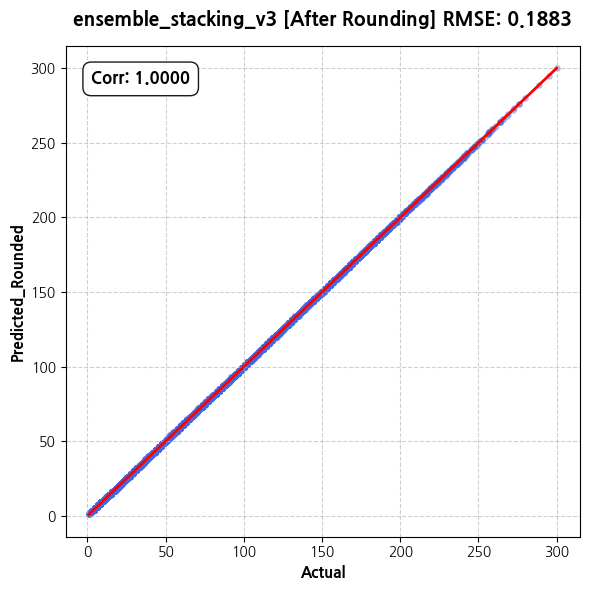

In [100]:
# V3 모델 분석 실행
analyze_rounding_effect_ensemble_v2(
    model_name='ensemble_stacking_v3', 
    X=train_x_refined_v1, 
    y=train_y
)

In [ ]:
def analyze_all_feature_importance_v3(model_name):
    """
    스태킹 V3 앙상블 모델 내부에 포함된
    4개의 1차 추정기(Base Estimators) 전체에 대한 피처 중요도를
    병렬적으로 비교하고 시각화하는 분석 함수 
    """
    
    # 지정된 경로에서 학습 완료된 스태킹 파이프라인 객체 로드
    model_path = f'./model/{model_name}.pkl'
    
    if not os.path.exists(model_path):
        print(f"❌ 모델 파일이 없습니다: {model_path}")
        return
    
    print(f"📂 스태킹 모델 로드 중: {model_name}")
    loaded_model = joblib.load(model_path)
    
    # 전처리기를 통과하여 최종적으로 모델에 입력된 변환 피처명 배열 추출 
    try:
        feature_names = loaded_model.preprocessor.get_feature_names_out()
    except:
        print("⚠️ 피처 이름을 가져올 수 없습니다.")
        return

    # 스태킹 파이프라인에 등록된 1차 트리 모델 리스트 매핑 (등록 순서 기준) 
    model_names = ['XGBoost', 'LightGBM', 'CatBoost', 'Random Forest']
    estimators = loaded_model.stacking_model.estimators_
    
    # 피처별 중요도 통합 저장을 위한 빈 데이터프레임 초기화 
    all_imp_df = pd.DataFrame({'Feature': feature_names})
    
    # 개별 트리 모델을 순회하며 고유의 피처 중요도 추출 및 병합
    for i, name in enumerate(model_names):
        try:
            model = estimators[i]
            imp = model.feature_importances_
            all_imp_df[name] = imp
        except Exception as e:
            # 특정 모델에서 속성 추출 실패 시 파이프라인 중단을 막기 위해 결측치를 0으로 처리
            print(f"⚠️ {name} 중요도 추출 실패: {e}")
            all_imp_df[name] = 0

    # 4개 모델의 피처 중요도 산술 평균 파생 변수 생성 및 전체 영향력 기준 내림차순 정렬
    all_imp_df['Average'] = all_imp_df[model_names].mean(axis=1)
    all_imp_df = all_imp_df.sort_values(by='Average', ascending=False)
    
    # 평균 중요도 상위 15개 피처에 대한 모델별 수치 비교표 콘솔 출력 
    print("-" * 60)
    print("📊 [모델별 Feature Importance 비교표 (상위 15개)]")
    print("-" * 60)
    print(all_imp_df.head(15).to_string(index=False, float_format='%.4f'))
    print("-" * 60)

    # 2x2 형태의 서브플롯 그리드를 생성하여 4개 모델의 피처 중요도 개별 시각화
    fig, axes = plt.subplots(2, 2, figsize=(18, 14))
    axes = axes.flatten() # 2x2 배열을 1줄로 펴서 인덱싱 편하게 함
    
    for i, name in enumerate(model_names):
        # 각 모델별 독립적인 상위 15개 피처 추출을 위해 데이터프레임 재정렬
        sorted_df = all_imp_df.sort_values(by=name, ascending=False).head(15)
        
        # 모델별 중요도 막대 그래프 렌더링
        sns.barplot(x=name, y='Feature', data=sorted_df, ax=axes[i], palette='viridis')
        axes[i].set_title(f'{name} Feature Importance', fontsize=14, fontweight='bold')
        axes[i].set_xlabel('Importance')
        axes[i].set_ylabel('')
        
    plt.tight_layout()
    plt.show()

📂 스태킹 모델 로드 중: ensemble_stacking_v3
------------------------------------------------------------
📊 [모델별 Feature Importance 비교표 (상위 15개)]
------------------------------------------------------------
                      Feature  XGBoost  LightGBM  CatBoost  Random Forest   Average
       num__Thermal_Intensity   0.0031      5125    0.8235         0.0000 1281.4567
       num__Heat_Energy_Proxy   0.0015      5070    0.5309         0.0028 1267.6338
 num__Session_Keytel_Calories   0.0147      4320    0.5650         0.0012 1080.1452
                     num__BMI   0.0004      4086    0.0644         0.0000 1021.5162
 num__Session_Harris_Calories   0.0149      3242    2.6357         0.0438  811.1736
                     num__Age   0.0000      3189    0.0260         0.0001  797.2565
              num__BMR_Harris   0.0397      3135    0.1424         0.0000  783.7955
                     num__BPM   0.0001      3115    0.0728         0.0000  778.7682
num__Session_Mifflin_Calories   0.0377      28

C:\Users\Administrator\AppData\Local\Temp\ipykernel_26208\3486903065.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=name, y='Feature', data=sorted_df, ax=axes[i], palette='viridis')
C:\Users\Administrator\AppData\Local\Temp\ipykernel_26208\3486903065.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=name, y='Feature', data=sorted_df, ax=axes[i], palette='viridis')
C:\Users\Administrator\AppData\Local\Temp\ipykernel_26208\3486903065.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=name, y='Feature', data=sorted_df, ax=axes[

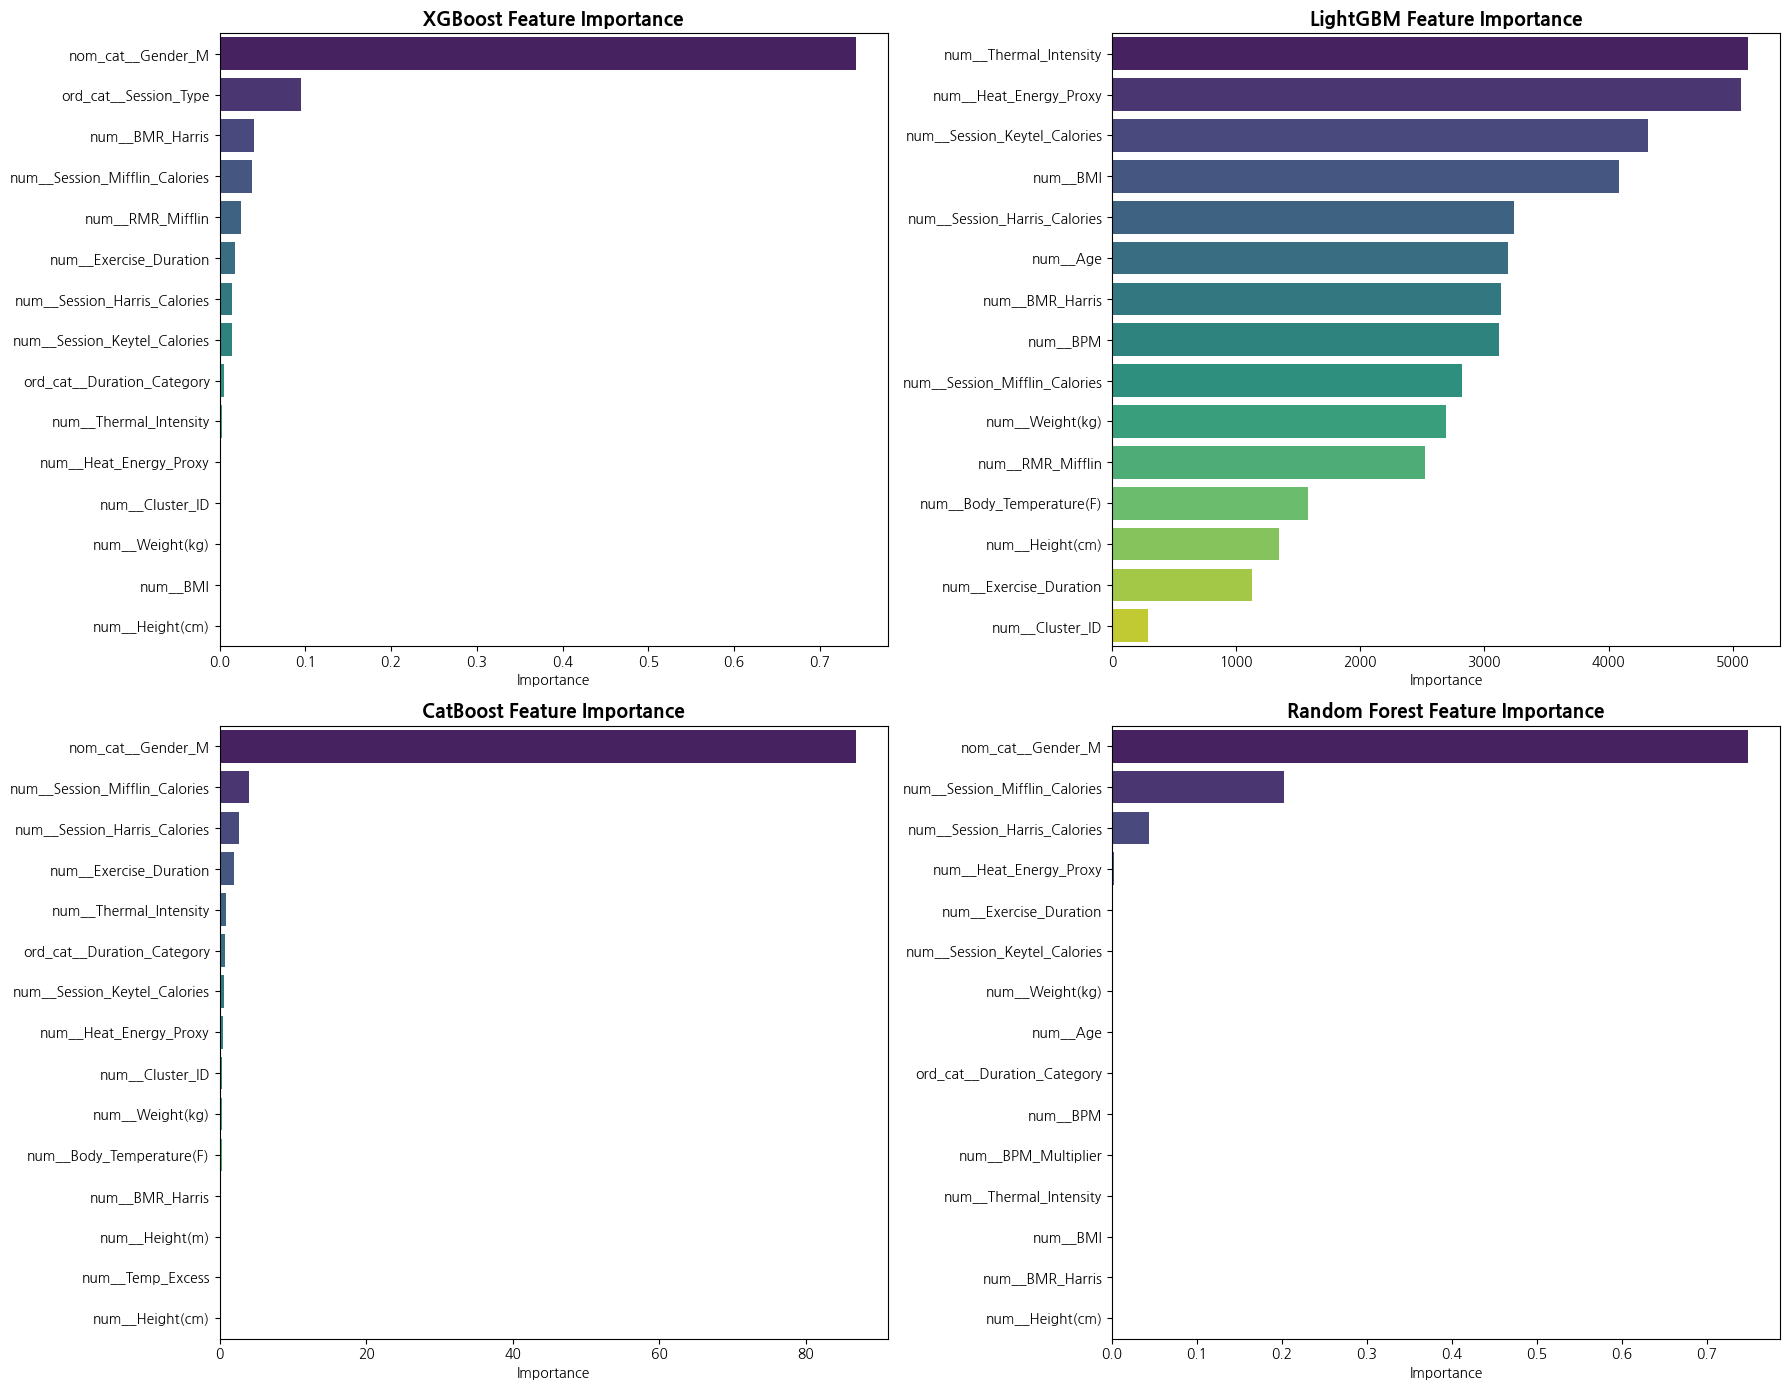

In [ ]:
# 학습 완료된 스태킹 V3 앙상블 모델 내부 1차 추정기(Base Models)들의 피처 중요도 병렬 분석 및 시각화 수행
analyze_all_feature_importance_v3('ensemble_stacking_v3')

In [ ]:
# V2 하이브리드 모델용으로 작성된 제출 파일 생성 함수를 재사용하여 V3 스태킹 앙상블 모델의 최종 추론 수행
submission_v3 = generate_submission_ensemble_v2(
    test_df=test_x_refined_v1, 
    model_name='ensemble_stacking_v3' 
)

📂 모델 로드 중: ensemble_stacking_v3
🔍 테스트 데이터 예측 중...
🎉 성공적으로 저장되었습니다: ./data/submission/submission_ensemble_stacking_v3.csv
          ID  Calories_Burned
0  TEST_0000            173.0
1  TEST_0001            190.0
2  TEST_0002             54.0
3  TEST_0003            161.0
4  TEST_0004            226.0


# 로그화 적용 

In [ ]:
class StackingWrapper_V4(BaseEstimator, RegressorMixin):
    """
    로그 변환(log1p)된 타겟을 학습한 스태킹 앙상블 V4 커스텀 래퍼 클래스
    내부 전처리 파이프라인을 거쳐 예측을 수행한 뒤, 지수 변환(expm1)으로 최종 값을 복원합니다.
    """
    def __init__(self, stacking_model, kmeans, scaler, preprocessor, cluster_cols):
        self.stacking_model = stacking_model
        self.kmeans = kmeans
        self.scaler = scaler
        self.preprocessor = preprocessor
        self.cluster_cols = cluster_cols
        
    def fit(self, X, y):
        # 외부에서 이미 학습된 파이프라인 객체들을 주입받으므로 자체 학습 과정은 생략
        return self
        
    def predict(self, X):
        X_t = X.copy()
        
        # 지정된 수치형 변수 스케일링 및 K-Means 군집화 피처 추가
        X_sc = self.scaler.transform(X_t[self.cluster_cols])
        X_t['Cluster_ID'] = self.kmeans.predict(X_sc)
        
        # 메인 데이터 전처리 적용 및 모델 입력 규격(Numpy 배열) 변환
        X_ready = self.preprocessor.transform(X_t)
        
        if hasattr(X_ready, 'toarray'): X_ready = X_ready.toarray()
        elif isinstance(X_ready, pd.DataFrame): X_ready = X_ready.to_numpy()
            
        # 메타 모델(Stacking) 예측 수행 (출력값은 로그 변환된 상태의 수치)
        pred_log = self.stacking_model.predict(X_ready)
        
        # np.expm1을 적용하여 로그 스케일의 예측값을 실제 칼로리 도메인으로 역변환
        final_pred = np.expm1(pred_log)
        
        return final_pred

In [ ]:
def objective_stacking_v4_log(trial, X, y_log, cv):
    """
    Optuna 최적화를 위한 스태킹 V4 목적 함수
    잔차(Residual) 계산 과정을 생략하고, 로그 변환된 타겟(y_log) 자체를 직접 학습하여 분산을 안정화하는 구조입니다.
    """
    
    # 1차 추정기(Base Modles)의 하이퍼파라미터 탐색 공간 정의
    p_xgb = {'n_estimators': trial.suggest_int('xgb_n', 500, 1500), 'max_depth': trial.suggest_int('xgb_depth', 3, 10), 'learning_rate': trial.suggest_float('xgb_lr', 0.01, 0.1), 'n_jobs': -1, 'random_state': 42}
    p_lgbm = {'n_estimators': trial.suggest_int('lgbm_n', 500, 1500), 'max_depth': trial.suggest_int('lgbm_depth', 3, 15), 'learning_rate': trial.suggest_float('lgbm_lr', 0.01, 0.1), 'num_leaves': trial.suggest_int('lgbm_leaves', 20, 100), 'n_jobs': -1, 'random_state': 42, 'verbose': -1}
    p_cat = {'iterations': trial.suggest_int('cat_iterations', 500, 1500), 'depth': trial.suggest_int('cat_depth', 4, 10), 'learning_rate': trial.suggest_float('cat_lr', 0.01, 0.1), 'random_seed': 42, 'verbose': 0, 'allow_writing_files': False}
    p_rf = {'n_estimators': trial.suggest_int('rf_n', 100, 300), 'max_depth': trial.suggest_int('rf_depth', 5, 20), 'n_jobs': -1, 'random_state': 42}

    # 1차 모델 파이프라인 리스트 구성
    estimators = [
        ('xgb', XGBRegressor(**p_xgb)),
        ('lgbm', LGBMRegressor(**p_lgbm)),
        ('cat', CatBoostRegressor(**p_cat)),
        ('rf', RandomForestRegressor(**p_rf))
    ]
    
    # 교차 검증을 통해 최적의 규제 강도를 도출하는 2차 메타 모델(RidgeCV) 정의
    final_estimator = RidgeCV()
    
    reg = StackingRegressor(estimators=estimators, final_estimator=final_estimator, cv=3, passthrough=True, n_jobs=-1)
    
    # 파이프라인 성능 평가를 위한 초기화
    scores = []
    cluster_features = ['Exercise_Duration', 'BPM', 'Body_Temperature(F)'] 

    for train_idx, val_idx in cv.split(X, y_log):
        # 학습 및 검증 데이터 분할 (타겟은 로그 변환된 y_log 사용)
        X_tr, X_val = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
        y_tr_log, y_val_log = y_log.iloc[train_idx], y_log.iloc[val_idx]
        
        # 특정 피처 스케일링 및 K-Means 기반 군집화 파생 변수 생성
        scaler_temp = StandardScaler()
        X_tr_cluster = scaler_temp.fit_transform(X_tr[cluster_features])
        X_val_cluster = scaler_temp.transform(X_val[cluster_features])
        kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
        X_tr['Cluster_ID'] = kmeans.fit_predict(X_tr_cluster)
        X_val['Cluster_ID'] = kmeans.predict(X_val_cluster)
        
        # 전체 학습 데이터에 대한 메인 전처리 적용
        preprocessor = get_preprocessor(X_tr)
        X_tr_ready = preprocessor.fit_transform(X_tr)
        X_val_ready = preprocessor.transform(X_val)
        
        # 기존 공식(Keytel)을 활용한 잔차 추출 로직을 제외하고, 로그 처리된 정답을 모델에 직접 학습 
        reg.fit(X_tr_ready, y_tr_log)
        
        # 검증 데이터 예측 및 로그 스케일 단위에서의 평균 제곱근 오차(RMSE) 산출 
        pred_log = reg.predict(X_val_ready)
        rmse = np.sqrt(mean_squared_error(y_val_log, pred_log))
        scores.append(rmse)

    # K-Fold 전체의 로그 스케일 평균 RMSE 반환        
    return np.mean(scores)

In [ ]:
def run_stacking_v4_log(X_train, y_train, cv):
    """
    타겟 변수에 로그 변환(log1p)을 적용하여 분산을 안정화한 상태로 학습하는 스태킹 V4 파이프라인 실행 함수
    예측 시 V4 래퍼 클래스가 지수 변환(expm1)을 통해 실제 칼로리 값으로 자동 복원합니다. 
    """
    print(f"🚀 [V4 Log-Target] 로그 변환 학습 시작...")
    
    # 타겟 변수의 치우침(Skewness)를 완화하고 정규성을 확보하기 위해 로그 변환 수행
    y_train_log = np.log1p(y_train)
    
    # 로그 변환된 타겟을 기준으로 하이퍼파라미터 최적화(Optuna) 진행
    study = optuna.create_study(direction='minimize')
    study.optimize(lambda trial: objective_stacking_v4_log(trial, X_train, y_train_log, cv), n_trials=20)
    
    print(f"\n✅ Best Log-RMSE: {study.best_value:.4f}")
    bp = study.best_params
    
    # 도출된 최적 파라미터를 1차 모델(Base Estimators) 파라미터로 매핑
    p_xgb = {'n_estimators': bp['xgb_n'], 'max_depth': bp['xgb_depth'], 'learning_rate': bp['xgb_lr'], 'n_jobs': -1, 'random_state': 42}
    p_lgbm = {'n_estimators': bp['lgbm_n'], 'max_depth': bp['lgbm_depth'], 'learning_rate': bp['lgbm_lr'], 'num_leaves': bp['lgbm_leaves'], 'n_jobs': -1, 'random_state': 42, 'verbose': -1}
    p_cat = {'iterations': bp['cat_iterations'], 'depth': bp['cat_depth'], 'learning_rate': bp['cat_lr'], 'random_seed': 42, 'verbose': 0, 'allow_writing_files': False}
    p_rf = {'n_estimators': bp['rf_n'], 'max_depth': bp['rf_depth'], 'n_jobs': -1, 'random_state': 42}
    
    print("🔄 전체 데이터로 최종 재학습 중 (Target: Log Scale)...")
    
    # K-Means 군집화를 위한 파생 변수 스케일링 및 생성
    cluster_cols = ['Exercise_Duration', 'BPM', 'Body_Temperature(F)']
    scaler = StandardScaler()
    X_full_sc = scaler.fit_transform(X_train[cluster_cols])
    kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
    X_train_final = X_train.copy()
    X_train_final['Cluster_ID'] = kmeans.fit_predict(X_full_sc)
    
    # 전체 학습 데이터 대상 통합 전처리 파이프라인 적용 
    preprocessor = get_preprocessor(X_train_final)
    X_train_ready = preprocessor.fit_transform(X_train_final)
    
    # 기반 모델 및 메타 모델(RidgeCV)을 결합한 스태킹 회귀 파이프라인 정의
    estimators = [('xgb', XGBRegressor(**p_xgb)), ('lgbm', LGBMRegressor(**p_lgbm)), ('cat', CatBoostRegressor(**p_cat)), ('rf', RandomForestRegressor(**p_rf))]
    reg = StackingRegressor(estimators=estimators, final_estimator=RidgeCV(), cv=5, passthrough=True, n_jobs=-1)
    
    # 전처리가 완료된 피처와 로그 변환된 타겟(y_train_log)을 사용하여 최종 스태킹 모델 학습
    reg.fit(X_train_ready, y_train_log)
    
    # 학습된 객체들을 통합하고, 내부적으로 지수 역변환(expm1)을 수행하는 V4 전용 래퍼
    # 타겟을 직접 로그 변환하여 학습하므로 기존 공식(Keytel)을 활용한 잔차 계산 로직이 제외됨
    final_model = StackingWrapper_V4(reg, kmeans, scaler, preprocessor, cluster_cols)
    
    # 복원이 포함된 래퍼 클래스의 예측 기능을 활용하여 학습 데이터 검증 및 원본 스케일 기준 오차율(RMSE) 산출
    val_preds = final_model.predict(X_train)
    real_rmse = np.sqrt(mean_squared_error(y_train, val_preds))
    
    print(f"🎉 V4 학습 완료! Real RMSE: {real_rmse:.4f}")
    return final_model, val_preds

In [ ]:
def run_experiment_stacking_v4_log(train_x, train_y, model_name, cv=None):
    """
    타겟 로그 변환 기반 스태킹 V4 모델의 실험 관리 및 영속화를 담당하는 파이프라인 함수
    사전 학습된 모델 로드 또는 신규 최적화 학습을 수행하며, 예측값의 지수 복원(expm1) 과정을 포함합니다.
    """
    
    # 모델 파일 관리를 위한 디렉토리 생성 및 저장 경로 설정
    save_dir = './model'
    os.makedirs(save_dir, exist_ok=True)
    save_path = os.path.join(save_dir, f'{model_name}.pkl')

    # 원본 학습 데이터 보존을 위한 데이터셋 복사
    X_train = train_x.copy()
    y_train = train_y.copy()

    is_new_model = False  
    
    # 기학습된 V4 모델 파일 존재 여부에 따른 조건부 실행
    if os.path.exists(save_path):
        print(f"📂 기존 V4(Log) 모델 로드 중: {save_path}")
        final_model = joblib.load(save_path)
        
        # 로드된 V4 래퍼 객체를 이용해 예측 수행 (내부적으로 지수 복원 과정을 거쳐 실제 도메인 수치 반환)
        val_preds = final_model.predict(X_train)
        
    else:    
        print(f"🔥 V4(Log-Target) 모델 없음. 최적화 및 학습 시작...")
        is_new_model = True 
        
        # 신규 최적화를 위해 V4 전용 학습 함수 호출 (로그 변환 및 스태킹 재학습 수행)
        final_model, val_preds = run_stacking_v4_log(
            X_train, y_train, cv
        )

    # 지수 역변환이 완료된 최종 예측값을 기준으로 실제 스케일의 RMSE 성능 지표 산출
    rmse = np.sqrt(mean_squared_error(y_train, val_preds))

    # 추론 결과와 실제값의 상관관계를 확인하기 위한 시각화 데이터 구성
    results_df = pd.DataFrame({'Actual': y_train, 'Predicted': val_preds})
    
    # 시각화 함수 존재 여부 체크 및 산점도 출력 시도
    try:
        plot_scatter(results_df, 'Actual', 'Predicted', title=f"{model_name} (RMSE: {rmse:.4f})")
    except NameError:
        print("⚠️ plot_scatter 함수가 없어 시각화를 건너뜁니다.")

    # 신규 학습된 파이프라인 객체 전체를 지정된 파일 경로에 직렬화하여 저장
    if is_new_model:
        joblib.dump(final_model, save_path)
        print(f"💾 V4 모델 저장 완료: {save_path}")
    
    return final_model, val_preds, rmse

📂 기존 V4(Log) 모델 로드 중: ./model\ensemble_stacking_v4_log.pkl


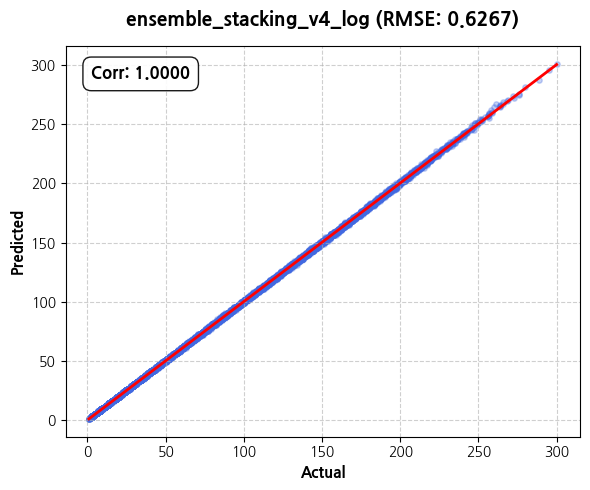


🧠 [Stacking V4 Log] 메타 모델 (RidgeCV) 분석
 • 선택된 규제 강도 (Alpha): 0.1000

⚖️ 1차 모델 예측값에 부여된 회귀 계수 (가중치 흐름):
 • XGB   : 0.2401
 • LGBM  : 0.2222
 • CAT   : 0.5321
 • RF    : 0.0195

🛠️ [Stacking V4 Log] 1차 모델(Base Models) 하이퍼파라미터

🔹 [XGB] Best Params:
{'objective': 'reg:squarederror', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': None, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': None, 'feature_types': None, 'feature_weights': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': 0.054557614994377876, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 4, 'max_leaves': None, 'min_child_weight': None, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': 684, 'n_jobs': -1, 'num_parallel_tree': None, 'random_state': 4

In [ ]:
# 정제된 학습 데이터와 K-Fold 객체를 전달하여 타겟 로그 변환 기반 스태킹 V4 실험 실행
final_model_v4, preds_v4, score_v4 = run_experiment_stacking_v4_log(
    train_x=train_x_refined_v1,
    train_y=train_y,
    model_name='ensemble_stacking_v4_log',
    cv=kf
)

print("\n" + "="*50)
print("🧠 [Stacking V4 Log] 메타 모델 (RidgeCV) 분석")
print("="*50)

# V4 래퍼 클래스 내부에 저장된 StackingRegressor의 최종 추정기(RidgeCV) 추춝
ridge_meta_model_v4 = final_model_v4.stacking_model.final_estimator_

# 로그 스케일 데이터에 대해 최적화된 Ridge 모델의 L2 규제 강도(Alpha) 확인
print(f" • 선택된 규제 강도 (Alpha): {ridge_meta_model_v4.alpha_:.4f}")

# 로그 변환된 값을 예측하는 각 기반 모델(XGBoost, LightGBM, CatBoost, RandomForest)에 할당된 메타 회귀 계수 
meta_coefs_v4 = ridge_meta_model_v4.coef_[:4] 
model_names = ['XGB', 'LGBM', 'CAT', 'RF']

print("\n⚖️ 1차 모델 예측값에 부여된 회귀 계수 (가중치 흐름):")
for name, coef in zip(model_names, meta_coefs_v4):
    print(f" • {name:<5} : {coef:.4f}")

print("\n" + "="*50)
print("🛠️ [Stacking V4 Log] 1차 모델(Base Models) 하이퍼파라미터")
print("="*50)

# 스태킹 파이프라인에 포함된 각 기반 모델별 상세 하이퍼파라미터 설정값 확인
estimators_v4 = final_model_v4.stacking_model.named_estimators_

for name in model_names:
    print(f"\n🔹 [{name}] Best Params:")
    print(estimators_v4[name.lower()].get_params())

📂 모델 로드 중: ensemble_stacking_v4_log

📊 [분석 결과] ensemble_stacking_v4_log
 - 반올림 전 RMSE: 0.6267
 - 반올림 후 RMSE: 0.6696
------------------------------
📈 1. 반올림 전 (Raw) 산점도


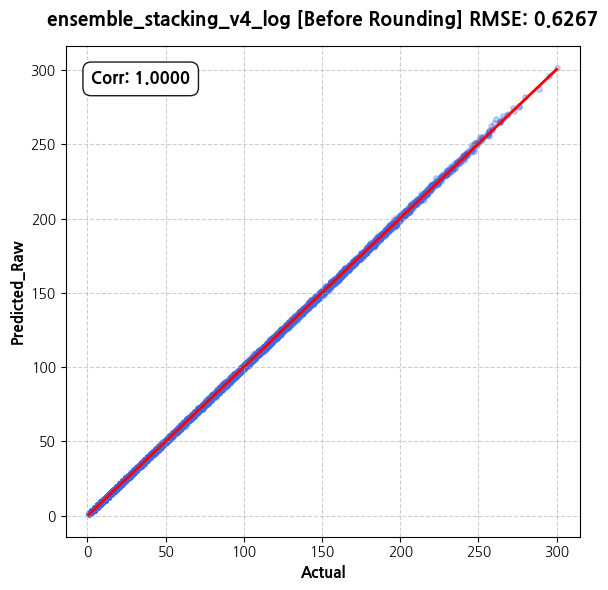

📈 2. 반올림 후 (Rounded) 산점도


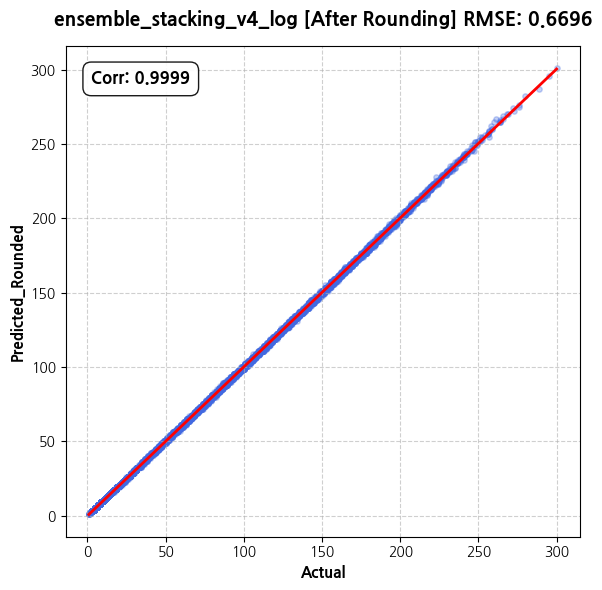

In [ ]:
# 저장된 스태킹 V4(로그 변환) 모델을 로드하여 반올림(Rounding) 처리에 따른 RMSE 변화 분석 수행
# 로그 스케일에서 지수 복원(exmp1)된 연속형 예측값을 정수형으로 변환했을 때의 성능 지표 차이를 검증
analyze_rounding_effect_ensemble_v2(
    model_name='ensemble_stacking_v4_log', 
    X=train_x_refined_v1, 
    y=train_y
)

📂 스태킹 모델 로드 중: ensemble_stacking_v4_log
------------------------------------------------------------
📊 [모델별 Feature Importance 비교표 (상위 15개)]
------------------------------------------------------------
                      Feature  XGBoost  LightGBM  CatBoost  Random Forest  Average
                     num__BPM   0.0073      2937    3.5565         0.0121 735.1440
 num__Session_Keytel_Calories   0.0035      2921    2.9736         0.0171 730.9985
                     num__Age   0.0039      2508    5.8822         0.0080 628.4735
       num__Exercise_Duration   0.2116      1606   14.3532         0.8523 405.3543
       num__Thermal_Intensity   0.0009      1598    6.8551         0.0002 401.2140
                     num__BMI   0.0000      1554    0.0943         0.0002 388.5236
              num__BMR_Harris   0.0015      1325    0.5428         0.0023 331.3866
       num__Heat_Energy_Proxy   0.0000      1324    0.1779         0.0001 331.0445
              num__Weight(kg)   0.0005      1112   

C:\Users\Administrator\AppData\Local\Temp\ipykernel_26208\3486903065.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=name, y='Feature', data=sorted_df, ax=axes[i], palette='viridis')
C:\Users\Administrator\AppData\Local\Temp\ipykernel_26208\3486903065.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=name, y='Feature', data=sorted_df, ax=axes[i], palette='viridis')
C:\Users\Administrator\AppData\Local\Temp\ipykernel_26208\3486903065.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=name, y='Feature', data=sorted_df, ax=axes[

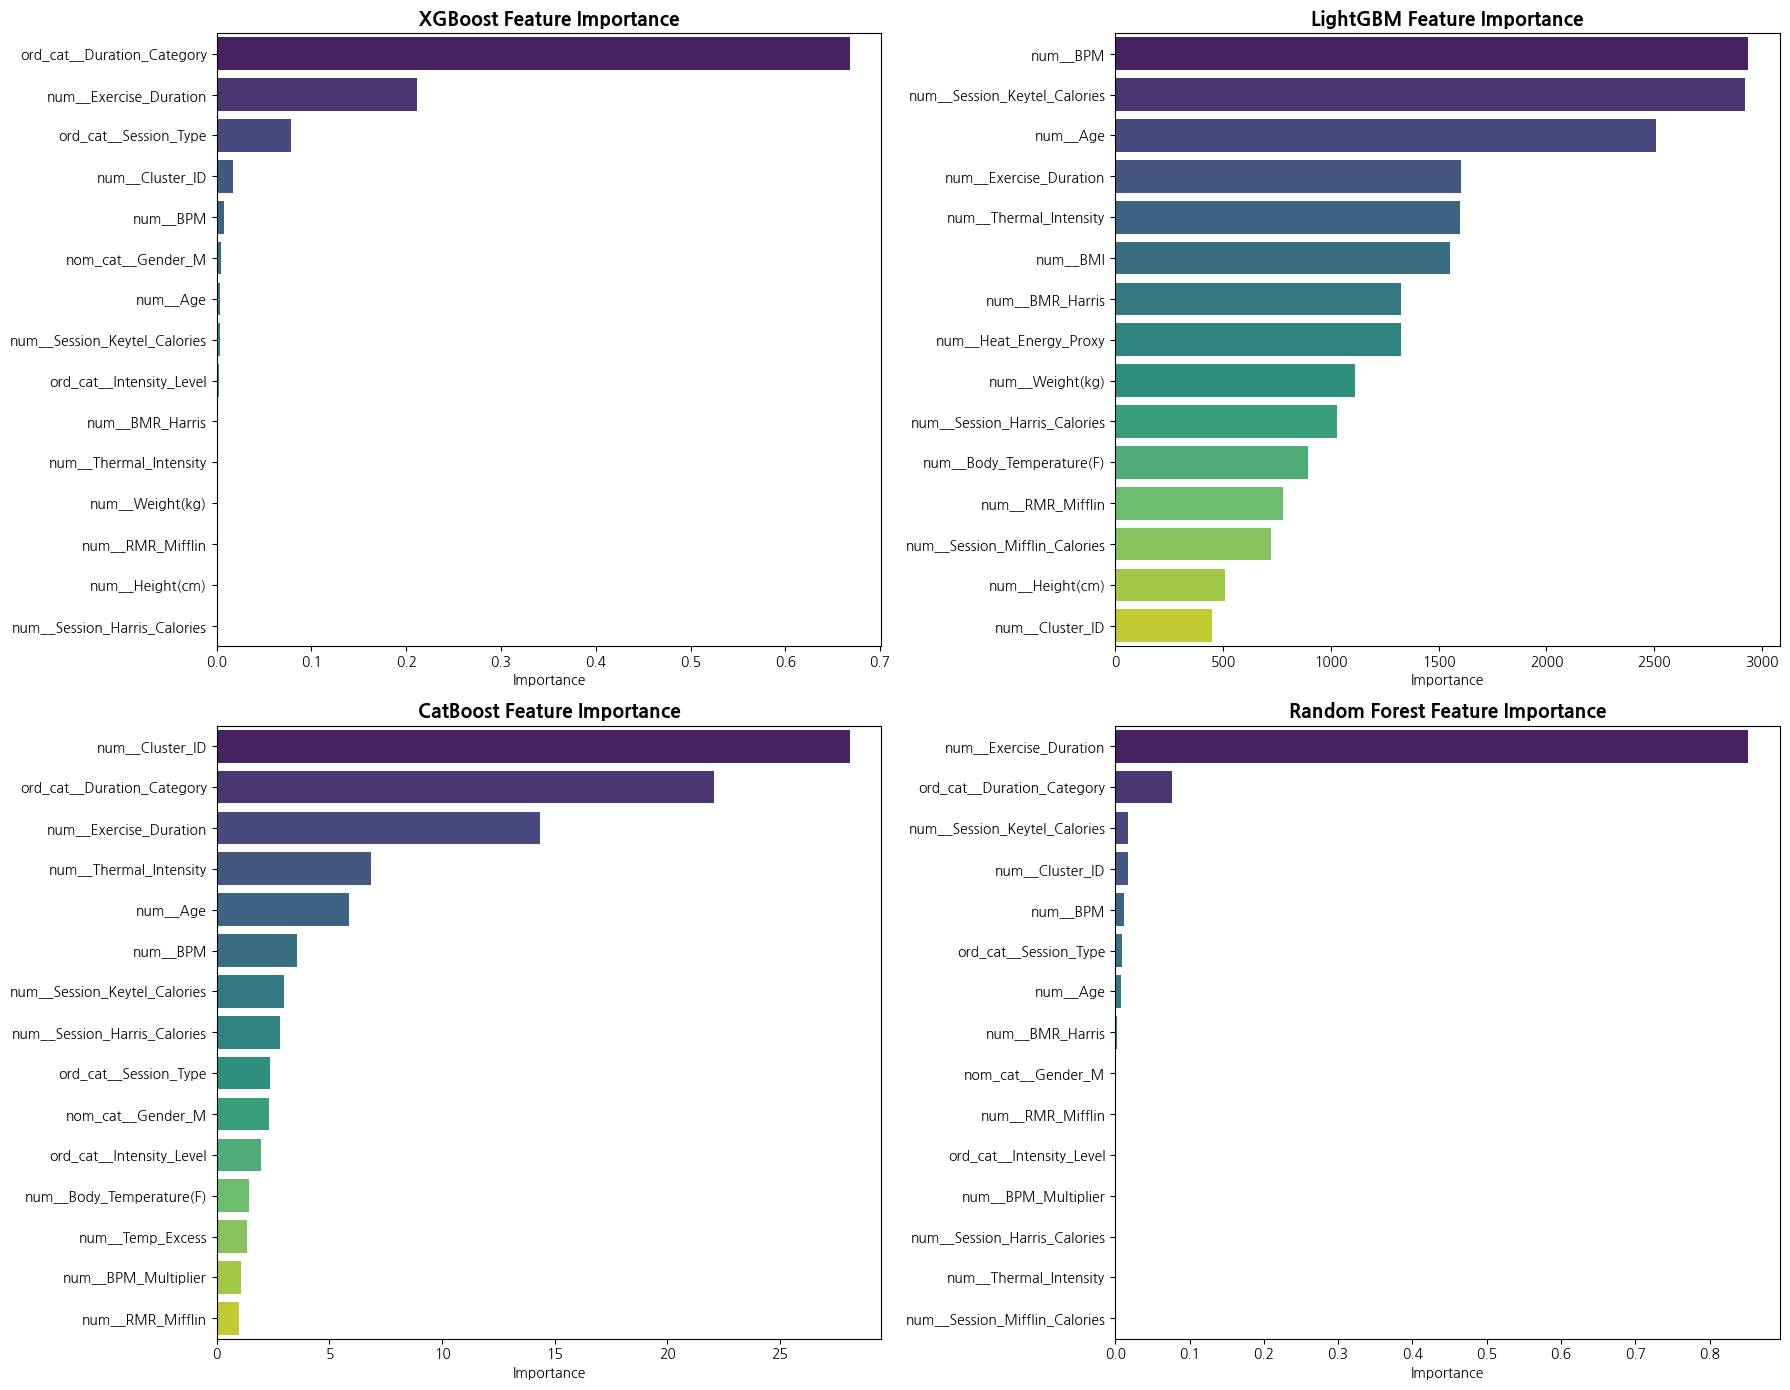

In [ ]:
# 로그 변환 타겟을 학습한 스태킹 V4 모델 내부의 1차 기반 모델별 피처 중요도 분석 실행
analyze_all_feature_importance_v3('ensemble_stacking_v4_log')

In [ ]:
# 로그 변환 타겟을 학습한 스태킹 V4 모델을 활용하여 최종 테스트 데이터에 대한 추론 수행
# StackingWrapper_V4 내부 로직에 의해 로그 스케일의 예측값이 지수 함수(expm1)로 자동 복원되어 최종 제출용 칼로리 값으로 생성됨
submission_v4 = generate_submission_ensemble_v2(
    test_df=test_x_refined_v1, 
    model_name='ensemble_stacking_v4_log' 
)

📂 모델 로드 중: ensemble_stacking_v4_log
🔍 테스트 데이터 예측 중...
🎉 성공적으로 저장되었습니다: ./data/submission/submission_ensemble_stacking_v4_log.csv
          ID  Calories_Burned
0  TEST_0000            172.0
1  TEST_0001            191.0
2  TEST_0002             53.0
3  TEST_0003            161.0
4  TEST_0004            227.0


# 로그끼리의 잔차 학습

In [ ]:
# 로그 스케일 잔차(Log-Residual)를 학습하고 물리 공식(Keytel)을 기준으로 값을 복원하는 V5 전용 래퍼 클래스 
class StackingWrapper_V5(BaseEstimator, RegressorMixin):
    def __init__(self, stacking_model, kmeans, scaler, preprocessor, keytel_col, cluster_cols):
        # 학습 완료된 스태킹 모델 및 전처리 요소, 기준(Keytel) 컬럼 정보 초기화
        self.stacking_model = stacking_model
        self.kmeans = kmeans
        self.scaler = scaler
        self.preprocessor = preprocessor
        self.keytel_col = keytel_col    
        self.cluster_cols = cluster_cols
        
    def fit(self, X, y):
        # 외부에서 학습된 객체들을 캡슐화하므로 자체 학습 로직은 생략
        return self
        
    def predict(self, X):
        X_t = X.copy()
        
        # 복원 프로세스에 활용할 베이스라인(Keytel) 수치 별도 추출
        keytel_values = X_t[self.keytel_col].values
        
        # 군집화 피처 스케일링 및 K-Means 레이블 생성
        X_sc = self.scaler.transform(X_t[self.cluster_cols])
        X_t['Cluster_ID'] = self.kmeans.predict(X_sc)
        
        # 통합 전처리기 적용 및 모델 입력 규격 변환
        X_ready = self.preprocessor.transform(X_t)
        
        # 모델 예측 수행 (결과값은 log(Actual) - log(Keytel)에 해당하는 로그 차이)
        pred_log_diff = self.stacking_model.predict(X_ready)
        
        # 로그 도메인에서 기준값과 예측 차이값을 합산하여 최종 로그 예측값 산출
        log_keytel = np.log1p(keytel_values)
        final_log_pred = log_keytel + pred_log_diff
        
        # 지수 변환(expm1)을 통한 실제 칼로리 단위 복원 및 물리적 음수 발생 방지
        final_pred = np.expm1(final_log_pred)
        final_pred = np.maximum(final_pred, 0)
        
        return final_pred

In [ ]:
def objective_stacking_v5(trial, X, y_real, cv, keytel_col):
    """
    로그 차분 기반 스태킹 V5 모델 최적화를 위한 Optuna 목적 함수
    실제값과 물리 공식(Keytel) 간의 로그 스케일 차이를 타겟으로 설정하여 학습합니다. 
    """
    
    # 1차 추정기군(Base Estimators) 하이퍼파라미터 탐색 공간 정의
    p_xgb = {
        'n_estimators': trial.suggest_int('xgb_n', 500, 2000),
        'max_depth': trial.suggest_int('xgb_depth', 3, 10),
        'learning_rate': trial.suggest_float('xgb_lr', 0.01, 0.1),
        'subsample': trial.suggest_float('xgb_sub', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('xgb_col', 0.6, 1.0),
        'n_jobs': -1, 'random_state': 42
    }
    p_lgbm = {
        'n_estimators': trial.suggest_int('lgbm_n', 500, 2000),
        'max_depth': trial.suggest_int('lgbm_depth', 3, 15),
        'learning_rate': trial.suggest_float('lgbm_lr', 0.01, 0.1),
        'num_leaves': trial.suggest_int('lgbm_leaves', 20, 150),
        'subsample': trial.suggest_float('lgbm_sub', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('lgbm_col', 0.6, 1.0),
        'n_jobs': -1, 'random_state': 42, 'verbose': -1
    }
    p_cat = {
        'iterations': trial.suggest_int('cat_iterations', 500, 2000),
        'depth': trial.suggest_int('cat_depth', 4, 10),
        'learning_rate': trial.suggest_float('cat_lr', 0.01, 0.1),
        'random_seed': 42, 'verbose': 0, 'allow_writing_files': False
    }
    p_rf = {
        'n_estimators': trial.suggest_int('rf_n', 100, 500),
        'max_depth': trial.suggest_int('rf_depth', 5, 25),
        'min_samples_split': trial.suggest_int('rf_min_split', 2, 10),
        'n_jobs': -1, 'random_state': 42
    }

    # 1차 모델 앙상블 및 2차 메타 모델(RidgeCV)을 결합한 스태킹 회귀 모델 정의
    estimators = [
        ('xgb', XGBRegressor(**p_xgb)),
        ('lgbm', LGBMRegressor(**p_lgbm)),
        ('cat', CatBoostRegressor(**p_cat)),
        ('rf', RandomForestRegressor(**p_rf))
    ]
    
    reg = StackingRegressor(
        estimators=estimators, 
        final_estimator=RidgeCV(), 
        cv=3, 
        passthrough=True, 
        n_jobs=-1
    )
    
    scores = []
    cluster_features = ['Exercise_Duration', 'BPM', 'Body_Temperature(F)'] 

    for train_idx, val_idx in cv.split(X, y_real):
        X_tr, X_val = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
        y_tr_real, y_val_real = y_real.iloc[train_idx], y_real.iloc[val_idx]
        
        # 로그 도메인에서 실제값과 Keytel 기준값의 차이를 학습 타겟으로 생성
        y_tr_target = np.log1p(y_tr_real) - np.log1p(X_tr[keytel_col])
        y_val_target = np.log1p(y_val_real) - np.log1p(X_val[keytel_col])

        # 군집화 피처 스케일링 및 K-Means 레이블링 수행
        scaler_temp = StandardScaler()
        X_tr_cluster = scaler_temp.fit_transform(X_tr[cluster_features])
        X_val_cluster = scaler_temp.transform(X_val[cluster_features])
        
        kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
        X_tr['Cluster_ID'] = kmeans.fit_predict(X_tr_cluster)
        X_val['Cluster_ID'] = kmeans.predict(X_val_cluster)
        
        # 통합 전처리기 적용 및 모델 입력 규격 변환
        preprocessor = get_preprocessor(X_tr)
        X_tr_ready = preprocessor.fit_transform(X_tr)
        X_val_ready = preprocessor.transform(X_val)
        
        # 생성된 로그 차분 타겟을 사용하여 스태킹 모델 학습
        reg.fit(X_tr_ready, y_tr_target)
        
        # 로그 차분 스케일 상에서의 예측 수행 및 RMSE 오차 기록
        pred = reg.predict(X_val_ready)
        rmse = np.sqrt(mean_squared_error(y_val_target, pred))
        scores.append(rmse)
        
    # 교차 검증 폴드 전체의 평균 RMSE 반환    
    return np.mean(scores)

In [ ]:
def run_stacking_v5_log_resid(X_train, y_train, cv, keytel_col='Session_Keytel_Calories'):
    """
    믈리 공식(Keytel) 기반 로그 잔차 학습을 수행하여 V5 스태킹 모델을 생성하는 함수
    실제값과 공식 결과의 로그 스케일 비율을 학습한 뒤 Wrapper를 통해 원래 단위로 복원합니다.
    """
    print(f"🚀 [V5 Final] 물리 공식 기반 로그 잔차(Log-Ratio) 학습 시작...")
    print(f"👉 Target = log(Actual) - log({keytel_col})")
    
    # Optuna 최적화를 통해 로그 차분 타겟에 최적화된 하이퍼파라미터 탐색
    print("🔎 최적의 파라미터를 찾는 중 (생략 없음)...")
    study = optuna.create_study(direction='minimize')
    study.optimize(lambda trial: objective_stacking_v5(trial, X_train, y_train, cv, keytel_col), n_trials=20)
    
    print(f"\n✅ Best Log-Diff RMSE: {study.best_value:.4f}")
    bp = study.best_params
    
    # 도출된 최적 파라미터를 기반으로 개별 모델 설정값 매핑
    p_xgb = {'n_estimators': bp['xgb_n'], 'max_depth': bp['xgb_depth'], 'learning_rate': bp['xgb_lr'], 'subsample': bp['xgb_sub'], 'colsample_bytree': bp['xgb_col'], 'n_jobs': -1, 'random_state': 42}
    p_lgbm = {'n_estimators': bp['lgbm_n'], 'max_depth': bp['lgbm_depth'], 'learning_rate': bp['lgbm_lr'], 'num_leaves': bp['lgbm_leaves'], 'subsample': bp['lgbm_sub'], 'colsample_bytree': bp['lgbm_col'], 'n_jobs': -1, 'random_state': 42, 'verbose': -1}
    p_cat = {'iterations': bp['cat_iterations'], 'depth': bp['cat_depth'], 'learning_rate': bp['cat_lr'], 'random_seed': 42, 'verbose': 0, 'allow_writing_files': False}
    p_rf = {'n_estimators': bp['rf_n'], 'max_depth': bp['rf_depth'], 'min_samples_split': bp['rf_min_split'], 'n_jobs': -1, 'random_state': 42}

    print("🔄 전체 데이터로 최종 재학습 중...")
    
    # 전체 학습 데이터를 대상으로 한 로그 잔차 타겟 생성
    y_full_target = np.log1p(y_train) - np.log1p(X_train[keytel_col])
    
    # K-Means 군집화를 위한 특정 피처 스케일링 및 파생 변수 생성
    cluster_cols = ['Exercise_Duration', 'BPM', 'Body_Temperature(F)']
    scaler = StandardScaler()
    X_full_sc = scaler.fit_transform(X_train[cluster_cols])
    
    kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
    X_train_final = X_train.copy()
    X_train_final['Cluster_ID'] = kmeans.fit_predict(X_full_sc)
    
    # 통합 전처리기 적용 및 모델 입력 규격 변환
    preprocessor = get_preprocessor(X_train_final)
    X_train_ready = preprocessor.fit_transform(X_train_final)
    
    # 기반 모델군과 메타 모델(RidgeCV)을 결합한 최종 스태킹 파이프라인 구성 
    estimators = [('xgb', XGBRegressor(**p_xgb)), ('lgbm', LGBMRegressor(**p_lgbm)), ('cat', CatBoostRegressor(**p_cat)), ('rf', RandomForestRegressor(**p_rf))]
    reg = StackingRegressor(estimators=estimators, final_estimator=RidgeCV(), cv=5, passthrough=True, n_jobs=-1)
    
    # 생성된 로그 잔차 타겟을 학습 데이터로 사용하여 전체 재학습 수행
    reg.fit(X_train_ready, y_full_target) 
    
    # 학습된 구성 요소들을 V5 전용 래퍼 클래스로 캡슐화하여 추론 파이프라인 완성
    final_model = StackingWrapper_V5(reg, kmeans, scaler, preprocessor, keytel_col, cluster_cols)
    
    # 래퍼의 복원 로직(지수 변환)이 포함된 예측을 수행하여 실제 단위 기준 RMSE 검증
    val_preds = final_model.predict(X_train)
    real_rmse = np.sqrt(mean_squared_error(y_train, val_preds))
    
    print(f"🎉 V5 학습 완료! 학습 데이터 기준 Real RMSE: {real_rmse:.4f}")
    
    return final_model, val_preds

In [ ]:
def run_experiment_stacking_v5_log_resid(train_x, train_y, model_name, cv=None, keytel_col='Session_Keytel_Calories'):
    """
    로그 잔차(Log-Ratio) 기반 스태킹 V5 실험 파이프라인 관리 함수
    사전 학습된 모델 로드 또는 신규 최적화/학습을 총괄하며 물리 공식(Keytel)을 활용한 복원 과정을 포함합니다.
    """
    
    # 모델 저장 디렉토리 생성 및 경로 설정
    save_dir = './model'
    os.makedirs(save_dir, exist_ok=True)
    save_path = os.path.join(save_dir, f'{model_name}.pkl')

    # 원본 데이터 보호를 위한 복사본 생성
    X_train = train_x.copy()
    y_train = train_y.copy()

    is_new_model = False  
    
    # 기저장된 V5 모델 존재 여부에 따른 조건부 로드 및 예측 수행
    if os.path.exists(save_path):
        print(f"📂 기존 V5(Log-Resid) 모델 로드 중: {save_path}")
        final_model = joblib.load(save_path)
        
        # StackingWrapper_V5 내부 로직을 통해 로그 비율 예측, 기준값 합산, 지수 복원 과정을 일괄 처리 
        val_preds = final_model.predict(X_train)
        
    else:    
        print(f"🔥 V5 모델 없음. 최적화 및 학습 시작 (Target: Log-Ratio)...")
        is_new_model = True 
        
        # 신규 학습 시 로그 잔차 타겟 생성이 포함된 V5 전용 실행 함수 호출
        final_model, val_preds = run_stacking_v5_log_resid(
            X_train, y_train, cv, keytel_col
        )

    # 지수 역변환이 완료된 최종 예측값을 바탕으로 실제 칼로리 도메인 기준 RMSE 산출
    rmse = np.sqrt(mean_squared_error(y_train, val_preds))

    # 성능 검증을 위한 실제값과 예측값의 상관관계 데이터프레임 구성
    results_df = pd.DataFrame({'Actual': y_train, 'Predicted': val_preds})
    
    # 시각화 함수 가용 여부 확인 후 산점도 출력
    try:
        plot_scatter(results_df, 'Actual', 'Predicted', title=f"{model_name} (RMSE: {rmse:.4f})")
    except NameError:
        print("⚠️ plot_scatter 함수가 없어 시각화를 건너뜁니다.")

    # 신규 생성된 모델인 경우 전체 파이프라인 객체를 .pkl 형식으로 저장
    if is_new_model:
        joblib.dump(final_model, save_path)
        print(f"💾 V5 모델 저장 완료: {save_path}")
    
    return final_model, val_preds, rmse

📂 기존 V5(Log-Resid) 모델 로드 중: ./model\ensemble_stacking_v5_log_resid.pkl


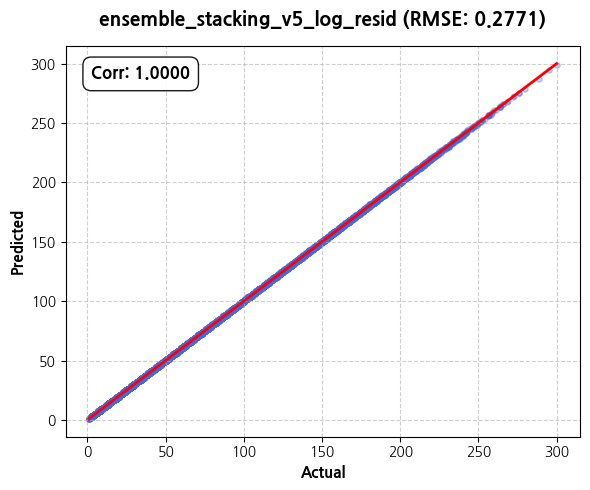


🧠 [Stacking V5 Log Residual] 메타 모델 (RidgeCV) 분석
 • 선택된 규제 강도 (Alpha): 0.1000

⚖️ 1차 모델 예측값에 부여된 회귀 계수 (가중치 흐름):
 • XGB   : 0.1671
 • LGBM  : 0.0963
 • CAT   : 0.4493
 • RF    : 0.3141

🛠️ [Stacking V5 Log Residual] 1차 모델(Base Models) 하이퍼파라미터

🔹 [XGB] Best Params:
{'objective': 'reg:squarederror', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': 0.8032862598635435, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': None, 'feature_types': None, 'feature_weights': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': 0.09832857883405538, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 5, 'max_leaves': None, 'min_child_weight': None, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': 1158, 'n_jobs': -1, 'num_paralle

In [ ]:
# 정제된 데이터와 물리 공식(Keytel) 컬럼을 지정하여 로그 잔차 기반 스태킹 V5 실험 실행
final_model_v5, preds_v5, score_v5 = run_experiment_stacking_v5_log_resid(
    train_x=train_x_refined_v1,
    train_y=train_y,
    model_name='ensemble_stacking_v5_log_resid',
    cv=kf,
    keytel_col='Session_Keytel_Calories' # Keytel 컬럼명 확인 필수
)

print("\n" + "="*50)
print("🧠 [Stacking V5 Log Residual] 메타 모델 (RidgeCV) 분석")
print("="*50)

# V5 래퍼 내부 스태킹 모델의 최종 추정기인 RidgeCV 객체 추출
ridge_meta_model_v5 = final_model_v5.stacking_model.final_estimator_

# 로그 차분 데이터를 학습한 메타 모델의 최적 L2 규제 강도 확인
print(f" • 선택된 규제 강도 (Alpha): {ridge_meta_model_v5.alpha_:.4f}")

# 로그 비율을 예측하는 4개 기반 모델(XGBoost, LightGBM, CatBoost, RandomForset)에 할당된 메타 회귀 계수 추출 
meta_coefs_v5 = ridge_meta_model_v5.coef_[:4] 
model_names = ['XGB', 'LGBM', 'CAT', 'RF']

print("\n⚖️ 1차 모델 예측값에 부여된 회귀 계수 (가중치 흐름):")
for name, coef in zip(model_names, meta_coefs_v5):
    print(f" • {name:<5} : {coef:.4f}")

print("\n" + "="*50)
print("🛠️ [Stacking V5 Log Residual] 1차 모델(Base Models) 하이퍼파라미터")
print("="*50)

# 스태킹 파이프라인에 등록된 각 기반 모델의 최적 파라미터 구성 확인
estimators_v5 = final_model_v5.stacking_model.named_estimators_

for name in model_names:
    print(f"\n🔹 [{name}] Best Params:")
    print(estimators_v5[name.lower()].get_params())

📂 모델 로드 중: ensemble_stacking_v5_log_resid

📊 [분석 결과] ensemble_stacking_v5_log_resid
 - 반올림 전 RMSE: 0.2771
 - 반올림 후 RMSE: 0.2590
------------------------------
📈 1. 반올림 전 (Raw) 산점도


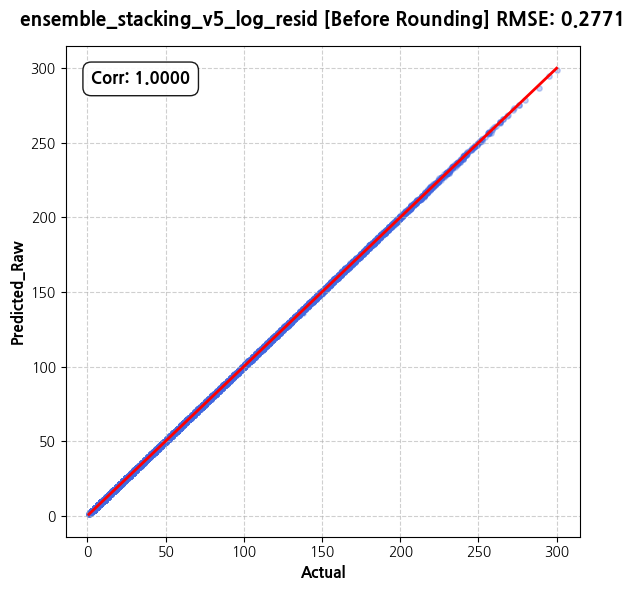

📈 2. 반올림 후 (Rounded) 산점도


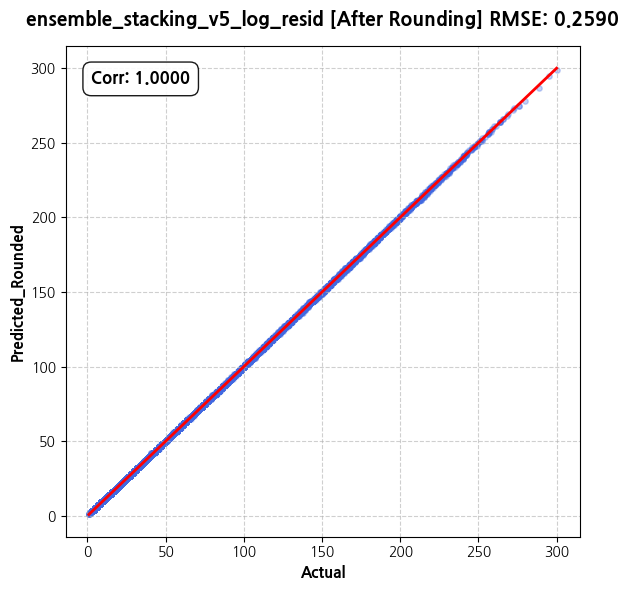

In [ ]:
# 로그 잔차 기반 스태킹 V5 모델의 지수 복원 예측치에 대한 반올림 영향도 분석
analyze_rounding_effect_ensemble_v2('ensemble_stacking_v5_log_resid', train_x_refined_v1, train_y)

📂 스태킹 모델 로드 중: ensemble_stacking_v5_log_resid
------------------------------------------------------------
📊 [모델별 Feature Importance 비교표 (상위 15개)]
------------------------------------------------------------
                      Feature  XGBoost  LightGBM  CatBoost  Random Forest   Average
                     num__BPM   0.0038      4859    2.2129         0.0502 1215.3167
 num__Session_Keytel_Calories   0.0004      4149    0.1796         0.0028 1037.2957
                     num__BMI   0.0003      3559    0.1185         0.0005  889.7798
              num__BMR_Harris   0.0048      3301    0.6328         0.0101  825.4119
                     num__Age   0.0017      3248    1.8575         0.0138  812.4682
       num__Heat_Energy_Proxy   0.0001      2995    0.0757         0.0006  748.7691
       num__Thermal_Intensity   0.0000      2885    0.1227         0.0004  721.2808
             num__RMR_Mifflin   0.0205      2532    0.4089         0.0019  633.1078
 num__Session_Harris_Calories   0.00

C:\Users\Administrator\AppData\Local\Temp\ipykernel_26208\3486903065.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=name, y='Feature', data=sorted_df, ax=axes[i], palette='viridis')
C:\Users\Administrator\AppData\Local\Temp\ipykernel_26208\3486903065.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=name, y='Feature', data=sorted_df, ax=axes[i], palette='viridis')
C:\Users\Administrator\AppData\Local\Temp\ipykernel_26208\3486903065.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=name, y='Feature', data=sorted_df, ax=axes[

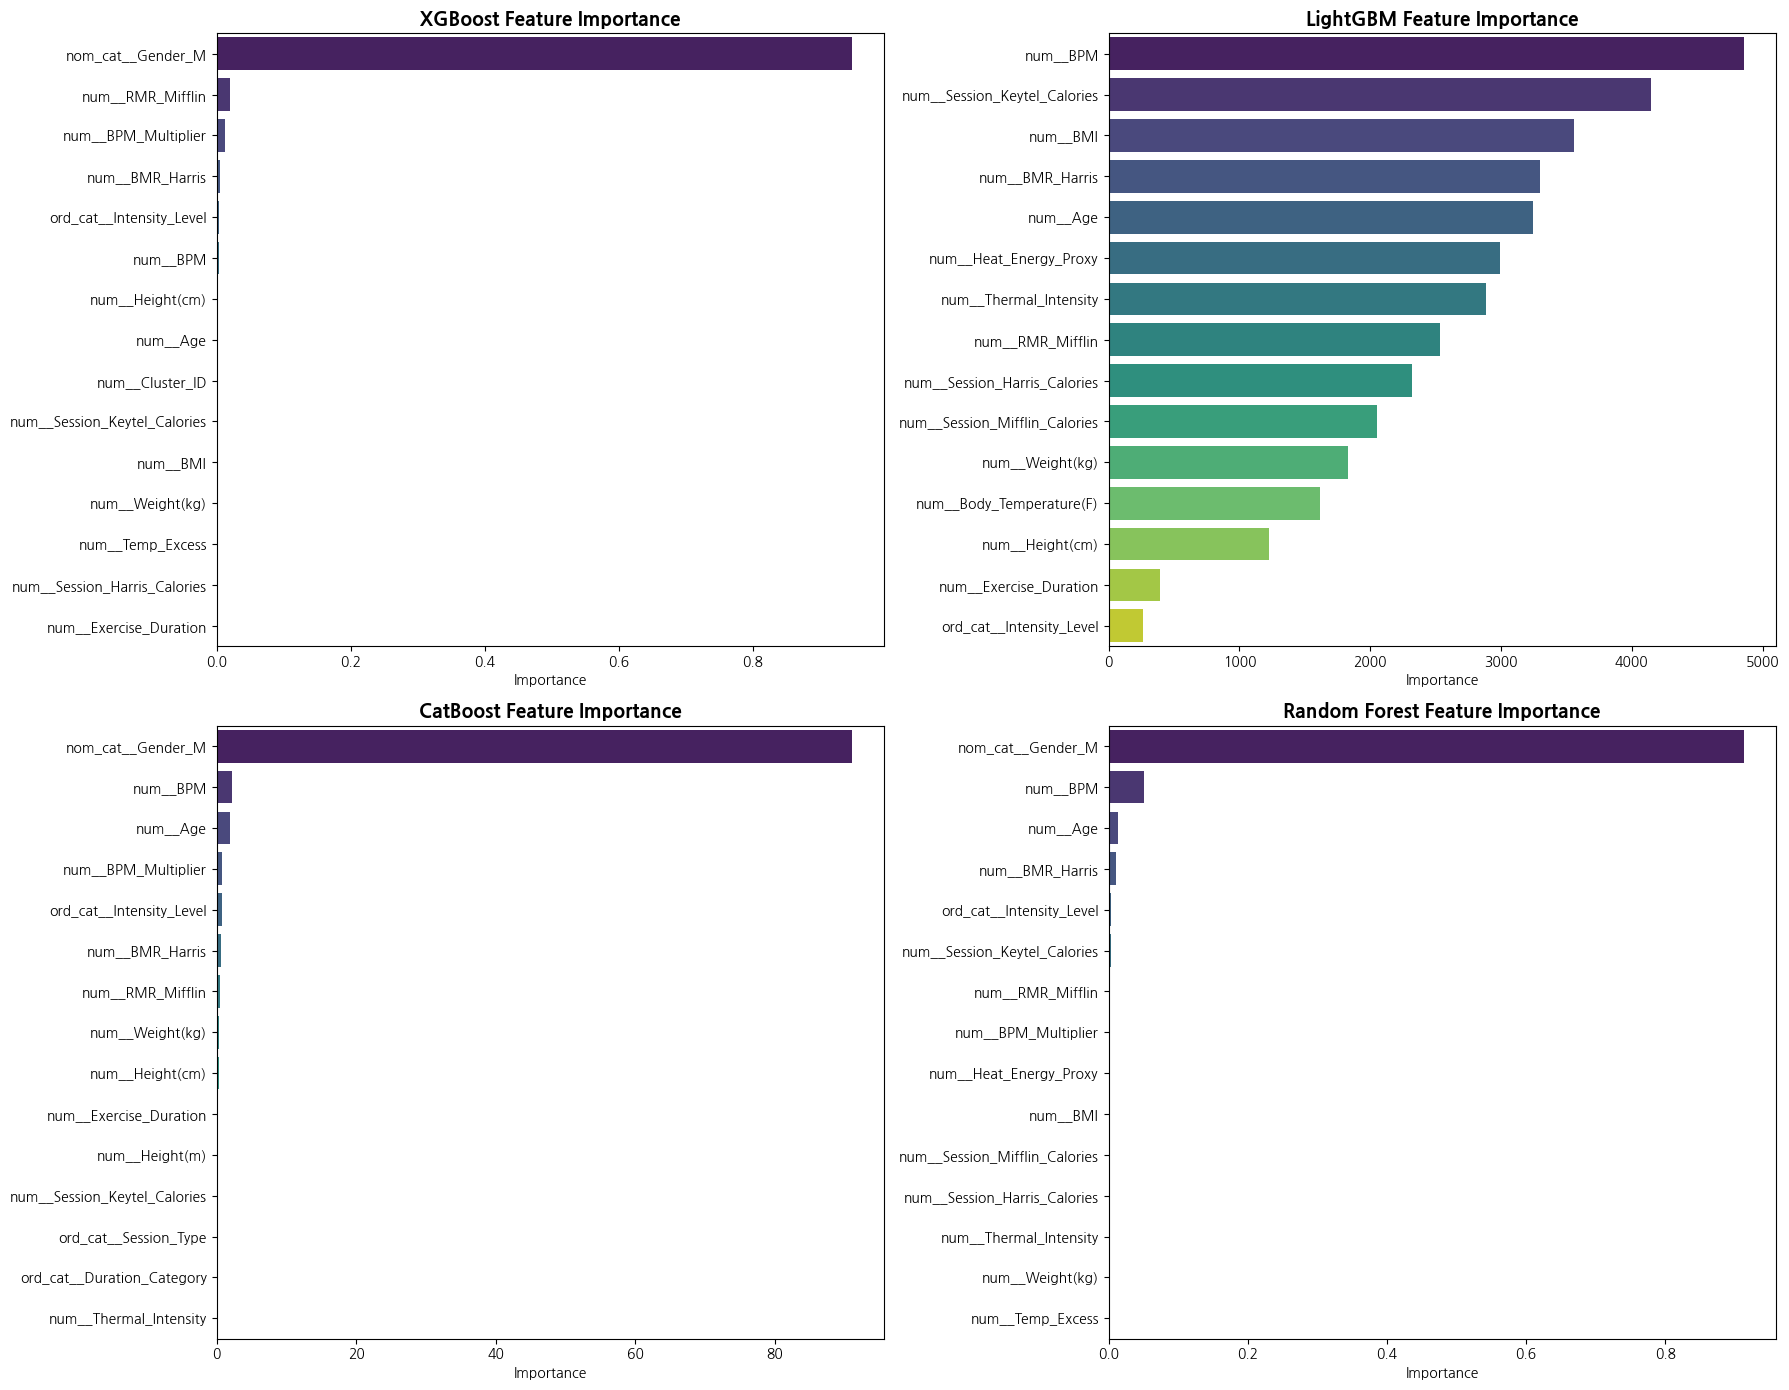

In [ ]:
# 로그 잔차를 학습한 스태킹 V5 모델 내부의 개별 기반 모델별 피처 중요도 분석
analyze_all_feature_importance_v3('ensemble_stacking_v5_log_resid')

In [ ]:
# 로그 잔차를 학습한 스태킹 모델 을 활용하여 테스트 데이터에 대한 최종 추론 수행
# 모델 내부에서 테스트 데이터의 Keytel 수치를 기준으로 로그 차분을 복원하고 지수 변환(expm1)을 거쳐 최종 칼로리 값을 산출
submission_v5 = generate_submission_ensemble_v2(
    test_df=test_x_refined_v1, 
    model_name='ensemble_stacking_v5_log_resid'
)

📂 모델 로드 중: ensemble_stacking_v5_log_resid
🔍 테스트 데이터 예측 중...
🎉 성공적으로 저장되었습니다: ./data/submission/submission_ensemble_stacking_v5_log_resid.csv
          ID  Calories_Burned
0  TEST_0000            173.0
1  TEST_0001            189.0
2  TEST_0002             54.0
3  TEST_0003            161.0
4  TEST_0004            226.0


# 곱셈 파생 변수 생성

In [ ]:
from itertools import combinations

def add_all_interactions(df):
    # 원본 데이터 보존을 위한 객체 복사
    df = df.copy()
    
    # 교호작용 파생 변수 추출의 대상이 되는 연속형 독립 변수군 정의 
    target_cols = [
        'Exercise_Duration', 
        'BPM', 
        'Body_Temperature(F)', 
        'Weight(kg)', 
        'Age', 
        'Height(cm)'
    ]
    
    print(f"⚡ [Interaction] {len(target_cols)}개 변수의 모든 곱셈 조합을 생성합니다...")
    
    # iterations.combinations를 활용하여 대상 수치형 변수 간의 모든 2차 결합(2-way interaction)을 순회
    new_cols = []
    for col1, col2 in combinations(target_cols, 2):
        # 식별을 위한 변수명 포맷팅 및 데이터프레임 내 요소 간의 곱 (Element-wise multiplication)
        new_col_name = f'Inter_{col1.split("(")[0]}_x_{col2.split("(")[0]}'
        
        # 실제 곱셈 수행
        df[new_col_name] = df[col1] * df[col2]
        new_cols.append(new_col_name)
    
    # 칼로리 소모 메커니즘의 물리적 관계를 직접 반영하는 3차 교호작용(운동 시간, 심박수, 체중)의 변수 명시적 추가
    df['Inter_Full_Physics'] = df['Exercise_Duration'] * df['BPM'] * df['Weight(kg)']
    new_cols.append('Inter_Full_Physics')

    print(f"✅ 총 {len(new_cols)}개의 곱셈 파생변수가 추가되었습니다!")
    return df

# 기정제된 학습 및 테스트 데이터셋에 교호작용 파생 변수 생성 로직 일괄 적용
train_x_full_inter = add_all_interactions(train_x_refined_v1)
test_x_full_inter = add_all_interactions(test_x_refined_v1)

# 생성된 파생 변수가 포함된 전체 데이터프레임 컬럼 구조 확인
print(train_x_full_inter.columns.tolist())

⚡ [Interaction] 6개 변수의 모든 곱셈 조합을 생성합니다...
✅ 총 16개의 곱셈 파생변수가 추가되었습니다!
⚡ [Interaction] 6개 변수의 모든 곱셈 조합을 생성합니다...
✅ 총 16개의 곱셈 파생변수가 추가되었습니다!
['Exercise_Duration', 'Body_Temperature(F)', 'BPM', 'Gender', 'Age', 'Weight(kg)', 'Height(cm)', 'Height(m)', 'BMI', 'BMR_Harris', 'RMR_Mifflin', 'BPM_Multiplier', 'Session_Harris_Calories', 'Session_Mifflin_Calories', 'Session_Keytel_Calories', 'Intensity_Level', 'Duration_Category', 'Session_Type', 'Temp_Excess', 'Thermal_Intensity', 'Heat_Energy_Proxy', 'Inter_Exercise_Duration_x_BPM', 'Inter_Exercise_Duration_x_Body_Temperature', 'Inter_Exercise_Duration_x_Weight', 'Inter_Exercise_Duration_x_Age', 'Inter_Exercise_Duration_x_Height', 'Inter_BPM_x_Body_Temperature', 'Inter_BPM_x_Weight', 'Inter_BPM_x_Age', 'Inter_BPM_x_Height', 'Inter_Body_Temperature_x_Weight', 'Inter_Body_Temperature_x_Age', 'Inter_Body_Temperature_x_Height', 'Inter_Weight_x_Age', 'Inter_Weight_x_Height', 'Inter_Age_x_Height', 'Inter_Full_Physics']


In [ ]:
# 교호작용 파생 변수 생성이 완료된 학습 데이터셋의 전체 특성(Feature) 공간을 리스트 자료형으로 추출
train_x_full_inter.columns.tolist()

['Exercise_Duration',
 'Body_Temperature(F)',
 'BPM',
 'Gender',
 'Age',
 'Weight(kg)',
 'Height(cm)',
 'Height(m)',
 'BMI',
 'BMR_Harris',
 'RMR_Mifflin',
 'BPM_Multiplier',
 'Session_Harris_Calories',
 'Session_Mifflin_Calories',
 'Session_Keytel_Calories',
 'Intensity_Level',
 'Duration_Category',
 'Session_Type',
 'Temp_Excess',
 'Thermal_Intensity',
 'Heat_Energy_Proxy',
 'Inter_Exercise_Duration_x_BPM',
 'Inter_Exercise_Duration_x_Body_Temperature',
 'Inter_Exercise_Duration_x_Weight',
 'Inter_Exercise_Duration_x_Age',
 'Inter_Exercise_Duration_x_Height',
 'Inter_BPM_x_Body_Temperature',
 'Inter_BPM_x_Weight',
 'Inter_BPM_x_Age',
 'Inter_BPM_x_Height',
 'Inter_Body_Temperature_x_Weight',
 'Inter_Body_Temperature_x_Age',
 'Inter_Body_Temperature_x_Height',
 'Inter_Weight_x_Age',
 'Inter_Weight_x_Height',
 'Inter_Age_x_Height',
 'Inter_Full_Physics']

📂 기존 스태킹 모델 로드 중: ./model\ensemble_stacking_v3_interactions.pkl


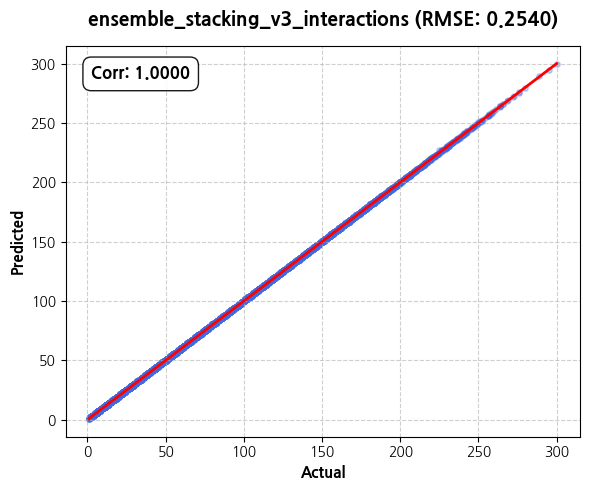

🚀 최종 RMSE: 0.2540

🧠 [Stacking V3 Interactions] 메타 모델 (RidgeCV) 분석
 • 선택된 규제 강도 (Alpha): 1.0000

⚖️ 1차 모델 예측값에 부여된 회귀 계수 (가중치 흐름):
 • XGB   : 0.0077
 • LGBM  : 0.0549
 • CAT   : 0.0358
 • RF    : 0.8957

🛠️ [Stacking V3 Interactions] 1차 모델(Base Models) 하이퍼파라미터

🔹 [XGB] Best Params:
{'objective': 'reg:squarederror', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': 0.791479316663972, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': None, 'feature_types': None, 'feature_weights': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': 0.07338728339051101, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 4, 'max_leaves': None, 'min_child_weight': None, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': 1251, 'n_jobs':

In [ ]:
# 교호작용 파생 변수가 모두 포함된 확장 데이터셋을 활용하여 스태킹 V3 모델 학습 파이프라인 실행
final_model_v3_inter, preds_v3_inter, score_v3_inter = run_experiment_ensemble_v3(
    train_x=train_x_full_inter,  
    train_y=train_y,
    model_name='ensemble_stacking_v3_interactions', 
    cv=kf
)

# 교차 검증을 통해 산출된 확장 데이터셋 기반 모델의 최종 오차율(RMSE) 확인
print(f"🚀 최종 RMSE: {score_v3_inter:.4f}")

print("\n" + "="*50)
print("🧠 [Stacking V3 Interactions] 메타 모델 (RidgeCV) 분석")
print("="*50)

# 래퍼 클래스 내부에 캡슐화된 스태킹 앙상블의 최종 메타 추정기(RidgeCV) 객체 추출
ridge_meta_model_inter = final_model_v3_inter.stacking_model.final_estimator_

print(f" • 선택된 규제 강도 (Alpha): {ridge_meta_model_inter.alpha_:.4f}")

# 1차 트리 모델(XGB, LightGBM, CatBoost, RandomForest)의 예측 결과에 부여된 메타 회귀 계수 추출
meta_coefs_inter = ridge_meta_model_inter.coef_[:4] 
model_names = ['XGB', 'LGBM', 'CAT', 'RF']

print("\n⚖️ 1차 모델 예측값에 부여된 회귀 계수 (가중치 흐름):")
for name, coef in zip(model_names, meta_coefs_inter):
    print(f" • {name:<5} : {coef:.4f}")

print("\n" + "="*50)
print("🛠️ [Stacking V3 Interactions] 1차 모델(Base Models) 하이퍼파라미터")
print("="*50)

# 앙상블을 구성하는 1차 추정기(Base Estimators)의 최적화된 하이퍼파라미터 딕셔너리 추출
estimators_inter = final_model_v3_inter.stacking_model.named_estimators_

for name in model_names:
    print(f"\n🔹 [{name}] Best Params:")
    print(estimators_inter[name.lower()].get_params())

📂 모델 로드 중: ensemble_stacking_v3_interactions

📊 [분석 결과] ensemble_stacking_v3_interactions
 - 반올림 전 RMSE: 0.2540
 - 반올림 후 RMSE: 0.1296
------------------------------
📈 1. 반올림 전 (Raw) 산점도


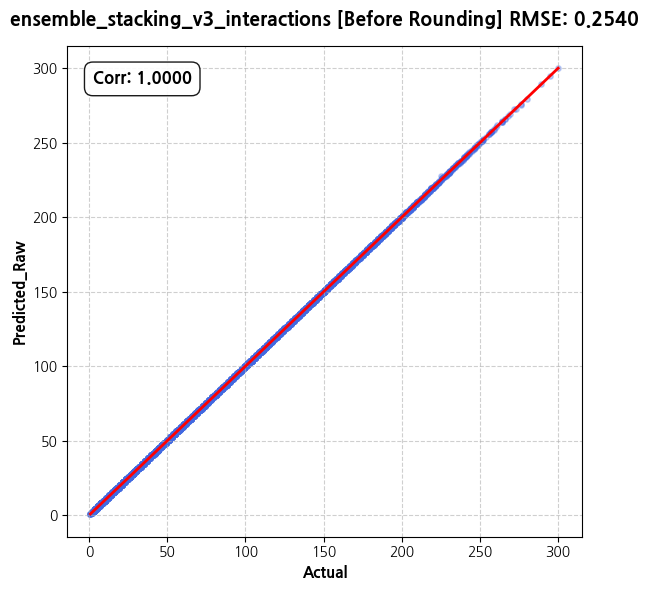

📈 2. 반올림 후 (Rounded) 산점도


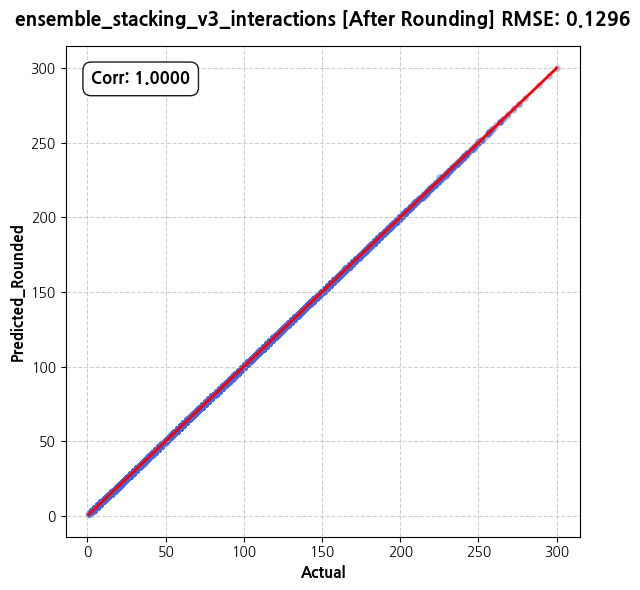

In [ ]:
# 교호작용(Interaction) 특성이 반영된 스태킹 V3 모델의 최종 예측값 반올림 효과 분석
analyze_rounding_effect_ensemble_v2(
    model_name='ensemble_stacking_v3_interactions', 
    X=train_x_full_inter, 
    y=train_y
)

📂 스태킹 모델 로드 중: ensemble_stacking_v3_interactions
------------------------------------------------------------
📊 [모델별 Feature Importance 비교표 (상위 15개)]
------------------------------------------------------------
                              Feature  XGBoost  LightGBM  CatBoost  Random Forest  Average
num__Inter_Exercise_Duration_x_Weight   0.0358      2730    1.8444         0.2575 683.0344
                             num__BMI   0.0000      1262    0.0100         0.0000 315.5025
num__Inter_Exercise_Duration_x_Height   0.0026      1116    1.8388         0.0000 279.4604
              num__Inter_BPM_x_Height   0.0000       989    0.0095         0.0000 247.2524
               num__Heat_Energy_Proxy   0.0001       895    0.4660         0.0000 223.8665
              num__Inter_Weight_x_Age   0.0000       878    0.0006         0.0000 219.5002
         num__Session_Keytel_Calories   0.0043       838    0.2226         0.0000 209.5567
                 num__Inter_BPM_x_Age   0.0000       813    0

C:\Users\Administrator\AppData\Local\Temp\ipykernel_26208\3486903065.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=name, y='Feature', data=sorted_df, ax=axes[i], palette='viridis')
C:\Users\Administrator\AppData\Local\Temp\ipykernel_26208\3486903065.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=name, y='Feature', data=sorted_df, ax=axes[i], palette='viridis')
C:\Users\Administrator\AppData\Local\Temp\ipykernel_26208\3486903065.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=name, y='Feature', data=sorted_df, ax=axes[

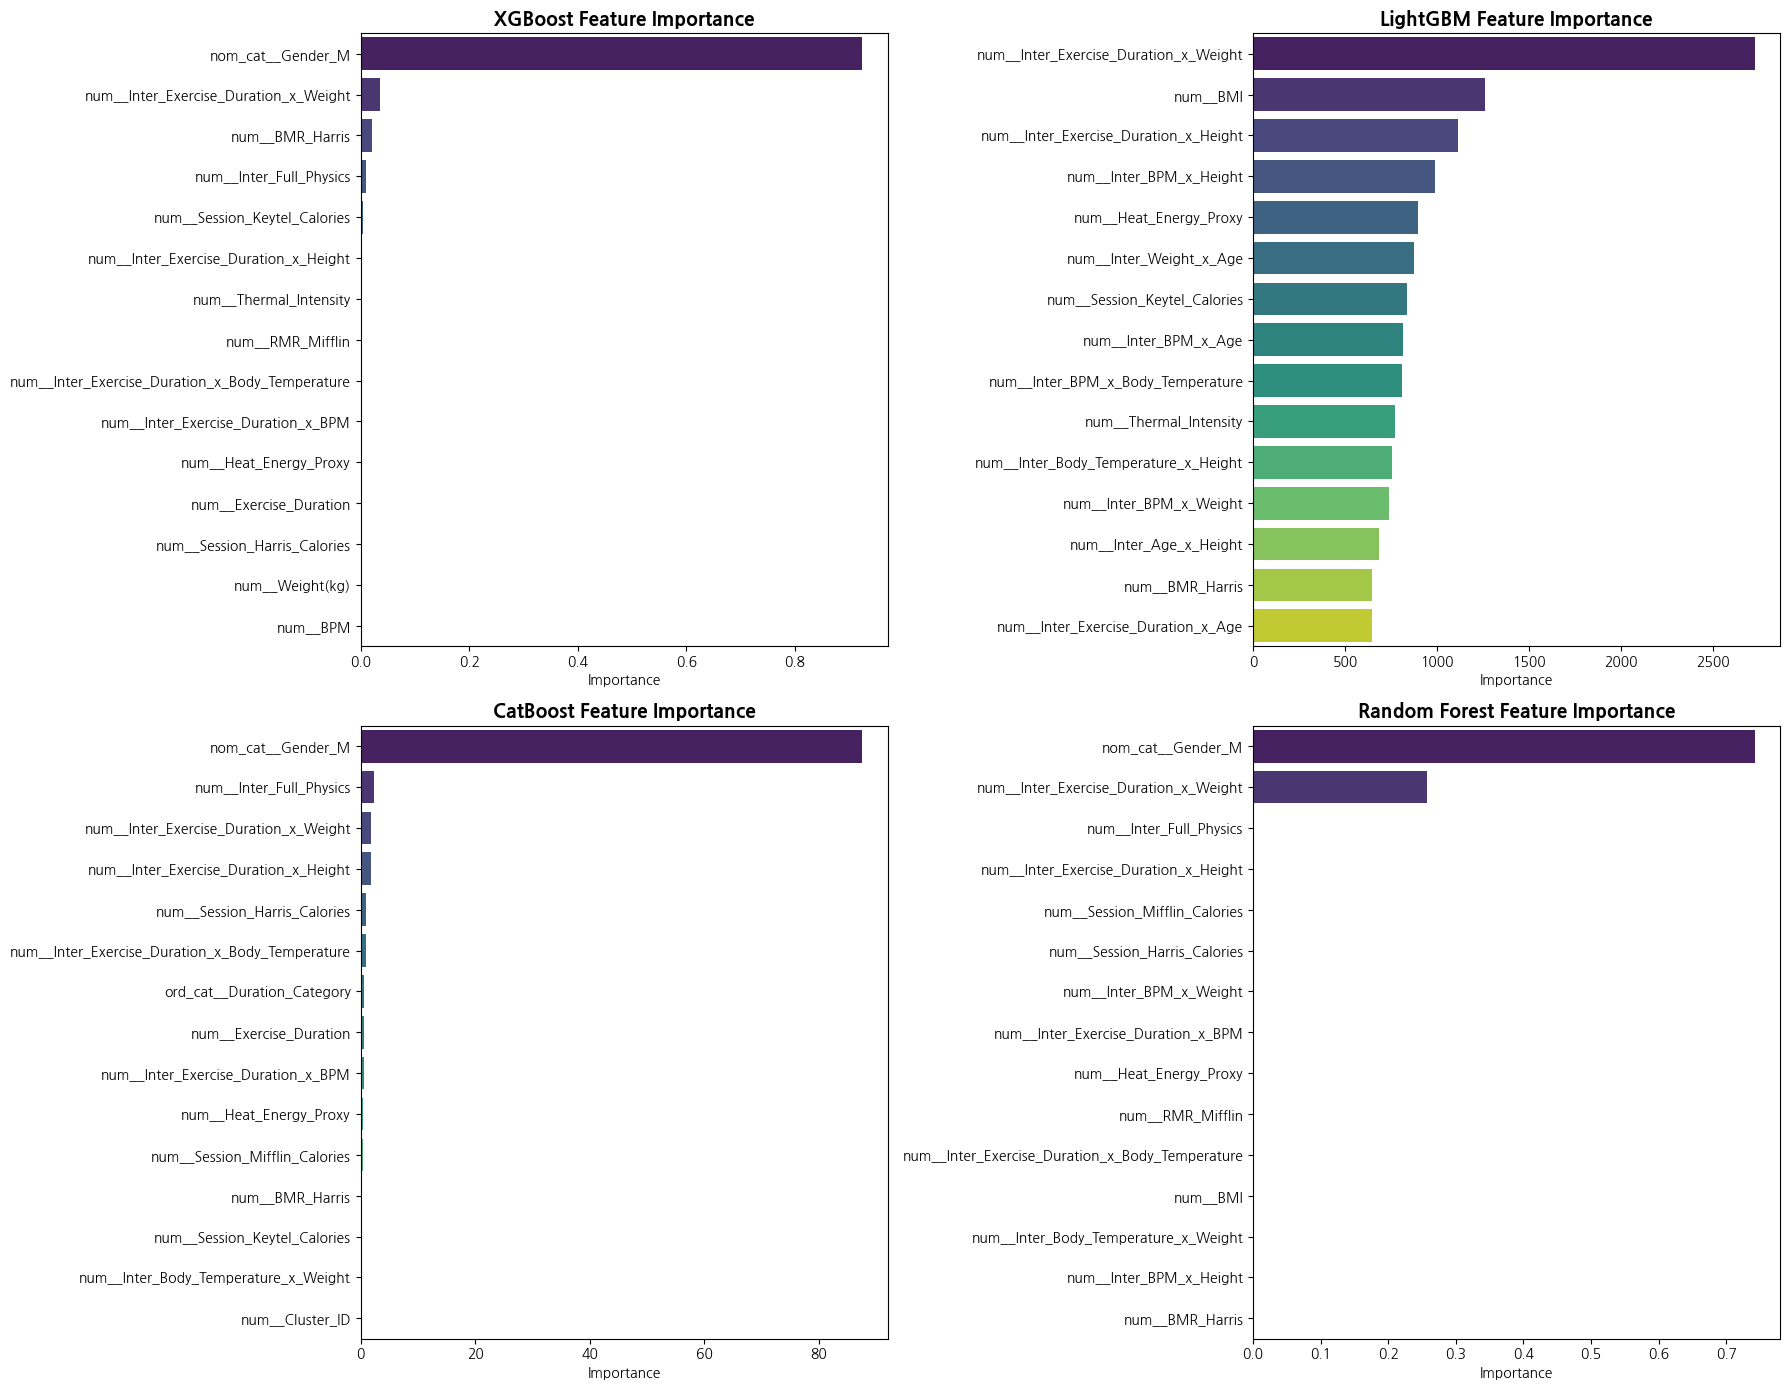

In [124]:
analyze_all_feature_importance_v3('ensemble_stacking_v3_interactions')

In [125]:
submission_v3 = generate_submission_ensemble_v2(
    test_df=test_x_full_inter,
    model_name='ensemble_stacking_v3_interactions' 
)

📂 모델 로드 중: ensemble_stacking_v3_interactions
🔍 테스트 데이터 예측 중...
🎉 성공적으로 저장되었습니다: ./data/submission/submission_ensemble_stacking_v3_interactions.csv
          ID  Calories_Burned
0  TEST_0000            173.0
1  TEST_0001            189.0
2  TEST_0002             53.0
3  TEST_0003            162.0
4  TEST_0004            226.0


In [ ]:
def add_features_v2_poly(df):
    # 원본 데이터 보존을 위한 객체 복사
    df = df.copy()
    
    # 교호작용(Interaction) 파생 변수 생성을 위한 핵심 연속형 독립 변수군 정의
    target_cols = [
        'Exercise_Duration', 'BPM', 'Body_Temperature(F)', 
        'Weight(kg)', 'Age', 'Height(cm)'
    ]
    
    # itertools.combinations를 활용한 대상 변수 간의 모든 2차 결합(2-way interaction) 수행
    for col1, col2 in combinations(target_cols, 2):
        name1 = col1.split("(")[0]
        name2 = col2.split("(")[0]
        df[f'Inter_{name1}_x_{name2}'] = df[col1] * df[col2]
    
    # 칼로리 소모의 물리적 메커니즘을 반영하는 3차 교호작용(운동 시간, 심박수, 체중) 변수 명시적 추가
    df['Inter_Full_Physics'] = df['Exercise_Duration'] * df['BPM'] * df['Weight(kg)']

    # 다항식(Polynomial) 파생 변수 생성
    poly_cols = ['Exercise_Duration', 'BPM', 'Body_Temperature(F)']
    
    for col in poly_cols:
        col_name = col.split("(")[0]
        
        # 가속화되는 비선형 증가 추세를 2차항(제곱)으로 반영
        df[f'Poly_{col_name}_Squared'] = df[col] ** 2
        
        # 고강도 구간의 극단값을 강조하여 비선형 트리 모델의 변별력(Variance 설명력) 확보
        df[f'Poly_{col_name}_Cubed'] = df[col] ** 3

    return df

# 기정제된 학습 및 테스트 데이터셋에 다항 및 교호작용 파생 변수 생성 로직 일괄 적용
train_x_poly = add_features_v2_poly(train_x_refined_v1)
test_x_poly = add_features_v2_poly(test_x_refined_v1)

# 다항 회귀적 특성이 추가된 전체 데이터프레임의 특성(Feature) 공간 구조 확인
print(train_x_poly.columns.tolist())

🚀 파생변수 생성 완료!
['Exercise_Duration', 'Body_Temperature(F)', 'BPM', 'Gender', 'Age', 'Weight(kg)', 'Height(cm)', 'Height(m)', 'BMI', 'BMR_Harris', 'RMR_Mifflin', 'BPM_Multiplier', 'Session_Harris_Calories', 'Session_Mifflin_Calories', 'Session_Keytel_Calories', 'Intensity_Level', 'Duration_Category', 'Session_Type', 'Temp_Excess', 'Thermal_Intensity', 'Heat_Energy_Proxy', 'Inter_Exercise_Duration_x_BPM', 'Inter_Exercise_Duration_x_Body_Temperature', 'Inter_Exercise_Duration_x_Weight', 'Inter_Exercise_Duration_x_Age', 'Inter_Exercise_Duration_x_Height', 'Inter_BPM_x_Body_Temperature', 'Inter_BPM_x_Weight', 'Inter_BPM_x_Age', 'Inter_BPM_x_Height', 'Inter_Body_Temperature_x_Weight', 'Inter_Body_Temperature_x_Age', 'Inter_Body_Temperature_x_Height', 'Inter_Weight_x_Age', 'Inter_Weight_x_Height', 'Inter_Age_x_Height', 'Inter_Full_Physics', 'Poly_Exercise_Duration_Squared', 'Poly_Exercise_Duration_Cubed', 'Poly_BPM_Squared', 'Poly_BPM_Cubed', 'Poly_Body_Temperature_Squared', 'Poly_Body_Tempera

📂 기존 스태킹 모델 로드 중: ./model\ensemble_stacking_v3_poly.pkl


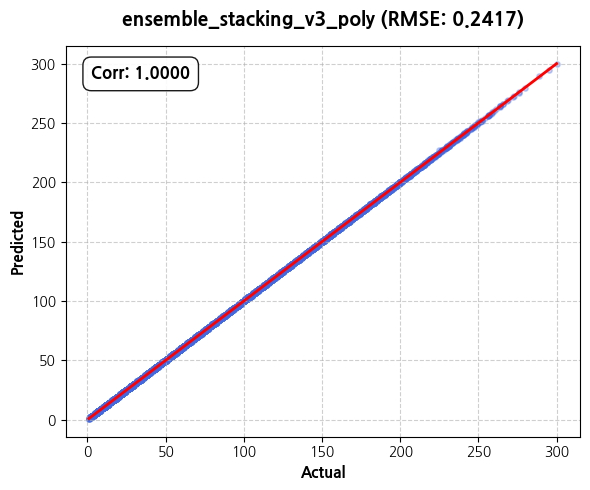


🧠 [Stacking V3 Poly] 메타 모델 (RidgeCV) 분석
 • 선택된 규제 강도 (Alpha): 10.0000

⚖️ 1차 모델 예측값에 부여된 회귀 계수 (가중치 흐름):
 • XGB   : -0.0021
 • LGBM  : 0.0751
 • CAT   : 0.0546
 • RF    : 0.8696

🛠️ [Stacking V3 Poly] 1차 모델(Base Models) 하이퍼파라미터

🔹 [XGB] Best Params:
{'objective': 'reg:squarederror', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': 0.6236237133144819, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': None, 'feature_types': None, 'feature_weights': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': 0.04019091906057454, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 4, 'max_leaves': None, 'min_child_weight': None, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': 1488, 'n_jobs': -1, 'num_parallel_tree': None,

In [ ]:
# 다항식(Polynomial) 및 교호작용 파생 변수가 포함된 확장 데이터셋을 활용하여 스태킹 V3 모델 학습 파이프라인 실행
final_model_v3_poly, preds_v3_poly, score_v3_poly = run_experiment_ensemble_v3(
    train_x=train_x_poly,        
    train_y=train_y,
    model_name='ensemble_stacking_v3_poly',
    cv=kf
)

print("\n" + "="*50)
print("🧠 [Stacking V3 Poly] 메타 모델 (RidgeCV) 분석")
print("="*50)

# 래퍼클래스 내부에 캡슐화된 스태킹 앙상블의 최종 메타 추정기(RidgeCV) 객체 추출
ridge_meta_model_poly = final_model_v3_poly.stacking_model.final_estimator_

# 다중공선성 통제 및 가중치 조율을 위해 최적화된 L2 규제 파라미터(Alpha) 수치 확인
print(f" • 선택된 규제 강도 (Alpha): {ridge_meta_model_poly.alpha_:.4f}")

# 1차 트리 모델(XGBoost, LightGBM, CatBoost, RandomForest)의 예측 결과에 부여된 메타 회귀 계수 추출
meta_coefs_poly = ridge_meta_model_poly.coef_[:4] 
model_names = ['XGB', 'LGBM', 'CAT', 'RF']

print("\n⚖️ 1차 모델 예측값에 부여된 회귀 계수 (가중치 흐름):")
for name, coef in zip(model_names, meta_coefs_poly):
    print(f" • {name:<5} : {coef:.4f}")

print("\n" + "="*50)
print("🛠️ [Stacking V3 Poly] 1차 모델(Base Models) 하이퍼파라미터")
print("="*50)

# 앙상블을 구성하는 1차 추정기(Base Estimators)의 최적화된 하이퍼파라미터 딕셔너리 추출
estimators_poly = final_model_v3_poly.stacking_model.named_estimators_

for name in model_names:
    print(f"\n🔹 [{name}] Best Params:")
    print(estimators_poly[name.lower()].get_params())

📂 모델 로드 중: ensemble_stacking_v3_poly

📊 [분석 결과] ensemble_stacking_v3_poly
 - 반올림 전 RMSE: 0.2417
 - 반올림 후 RMSE: 0.0966
------------------------------
📈 1. 반올림 전 (Raw) 산점도


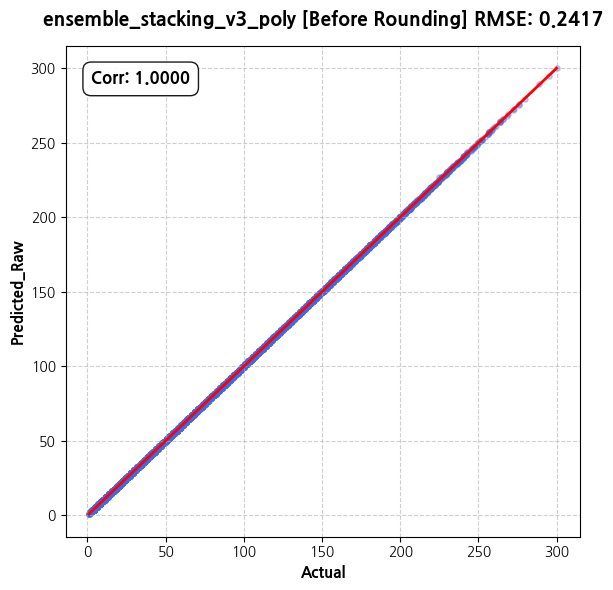

📈 2. 반올림 후 (Rounded) 산점도


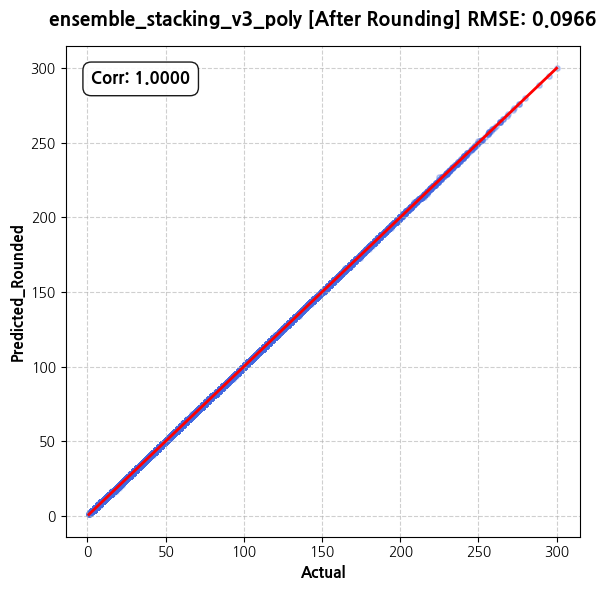

In [ ]:
# 다항식(Polynomial) 파생 변수가 적용된 스태킹 V3 모델의 최종 예측값 반올림 효과 분석
analyze_rounding_effect_ensemble_v2(
    model_name='ensemble_stacking_v3_poly', 
    X=train_x_poly, 
    y=train_y
)

📂 스태킹 모델 로드 중: ensemble_stacking_v3_poly
------------------------------------------------------------
📊 [모델별 Feature Importance 비교표 (상위 15개)]
------------------------------------------------------------
                              Feature  XGBoost  LightGBM  CatBoost  Random Forest  Average
              num__Inter_BPM_x_Height   0.0000      3235    0.0175         0.0000 808.7544
                             num__BMI   0.0025      3144    0.0279         0.0000 786.0076
num__Inter_Exercise_Duration_x_Weight   0.0479      3054    1.3282         0.2575 763.9084
               num__Heat_Energy_Proxy   0.0032      2652    0.8189         0.0000 663.2055
         num__Session_Keytel_Calories   0.0146      2624    0.0807         0.0000 656.0238
              num__Inter_BPM_x_Weight   0.0002      2571    0.3704         0.0000 642.8427
 num__Inter_Body_Temperature_x_Height   0.0003      2380    0.1484         0.0000 595.0372
               num__Thermal_Intensity   0.0016      2307    2.6294   

C:\Users\Administrator\AppData\Local\Temp\ipykernel_26208\3486903065.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=name, y='Feature', data=sorted_df, ax=axes[i], palette='viridis')
C:\Users\Administrator\AppData\Local\Temp\ipykernel_26208\3486903065.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=name, y='Feature', data=sorted_df, ax=axes[i], palette='viridis')
C:\Users\Administrator\AppData\Local\Temp\ipykernel_26208\3486903065.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=name, y='Feature', data=sorted_df, ax=axes[

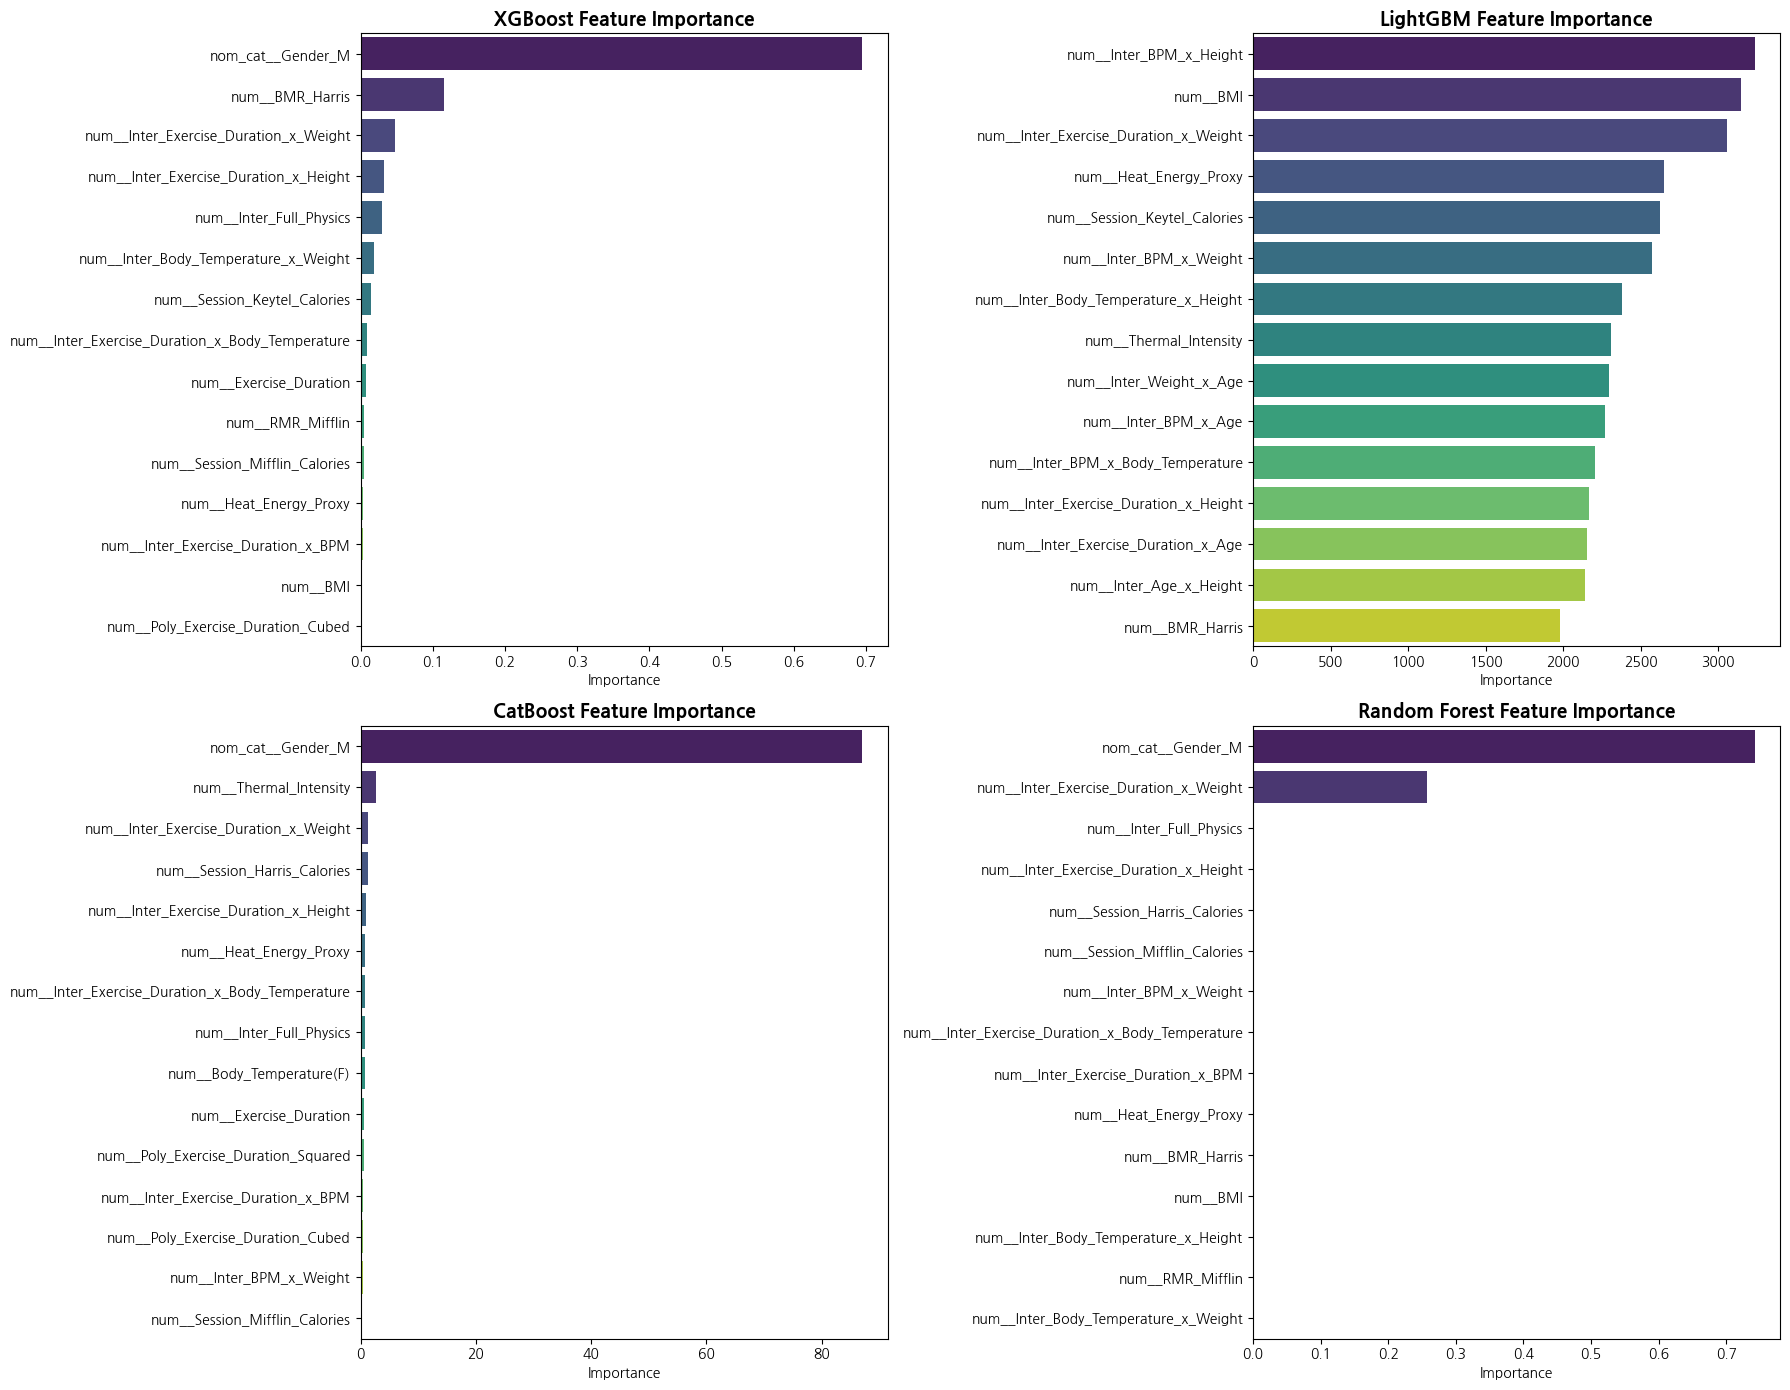

In [129]:
analyze_all_feature_importance_v3('ensemble_stacking_v3_poly')

In [ ]:
# 다항식(Polynomial) 파생 변수가 적용된 테스트 데이터셋을 활용하여 스태킹 V3 모델의 최종 추론 수행 
submission_v3 = generate_submission_ensemble_v2(
    test_df=test_x_poly,
    model_name='ensemble_stacking_v3_poly' 
)

📂 모델 로드 중: ensemble_stacking_v3_poly
🔍 테스트 데이터 예측 중...
🎉 성공적으로 저장되었습니다: ./data/submission/submission_ensemble_stacking_v3_poly.csv
          ID  Calories_Burned
0  TEST_0000            173.0
1  TEST_0001            189.0
2  TEST_0002             53.0
3  TEST_0003            162.0
4  TEST_0004            226.0


# 나누기 특성변수 생성

In [ ]:
def add_poly_and_ratios(df):
    # 원본 데이터 훼손 방지를 위한 복사본 할당
    df = df.copy()
    
    # 연속형 독립 변수 간의 2차 결합 및 다항 교호작용 특성 추출
    target_cols = [
        'Exercise_Duration', 'BPM', 'Body_Temperature(F)', 
        'Weight(kg)', 'Age', 'Height(cm)'
    ]
    
    for col1, col2 in combinations(target_cols, 2):
        name1 = col1.split("(")[0]
        name2 = col2.split("(")[0]
        df[f'Inter_{name1}_x_{name2}'] = df[col1] * df[col2]
    
    # 칼로리 소모 메커니즘을 구성하는 3개 핵심 변수의 명시저 3차 교호작용 변수 추가
    df['Inter_Full_Physics'] = df['Exercise_Duration'] * df['BPM'] * df['Weight(kg)']

    # 운동 강도 핵심 지표의 2차 및 3차 항을 추가하여 트리 모델의 비선형 설명력 강화
    poly_cols = ['Exercise_Duration', 'BPM', 'Body_Temperature(F)']
    for col in poly_cols:
        col_name = col.split("(")[0]
        df[f'Poly_{col_name}_Squared'] = df[col] ** 2
        df[f'Poly_{col_name}_Cubed'] = df[col] ** 3

    # 도메인 지식을 반영한 효율성 및 속도 관련 파생 변수 산출
    # 연령 기반 추정 최대 심박수 대비 현재 심박수 부하율 계산
    df['HR_Load_Rate'] = df['BPM'] / (220 - df['Age'])
    
    # 단위 체중당 심박수 산출 (ZeroDivision 에러 방지를 위한 극소값 1e-5 가산)
    df['BPM_per_Weight'] = df['BPM'] / (df['Weight(kg)'] + 1e-5)
    
    # 연령 대비 운동 지속 능력 지표 산출
    df['Duration_per_Age'] = df['Exercise_Duration'] / (df['Age'] + 1e-5)
    
    # 운동 시간당 체온 상승률(발열 속도) 산출
    df['Heating_Rate'] = df['Body_Temperature(F)'] / (df['Exercise_Duration'] + 1e-5)

    return df

# 기정제된 학습 및 테스트 데이터셋에 다항, 교호작용, 도메인 비율 파생 변수 생성 로직 일괄 적용
train_x_final_feat = add_poly_and_ratios(train_x_refined_v1)
test_x_final_feat = add_poly_and_ratios(test_x_refined_v1)

# 파생 변수 생성이 완료된 데이터프레임의 최종 특성 공간 차원 및 컬럼 구조 확인
print(f"✅ 변수 추가 완료: 총 {train_x_final_feat.shape[1]}개 컬럼")
print(train_x_final_feat.columns)

✅ 변수 추가 완료: 총 47개 컬럼
Index(['Exercise_Duration', 'Body_Temperature(F)', 'BPM', 'Gender', 'Age',
       'Weight(kg)', 'Height(cm)', 'Height(m)', 'BMI', 'BMR_Harris',
       'RMR_Mifflin', 'BPM_Multiplier', 'Session_Harris_Calories',
       'Session_Mifflin_Calories', 'Session_Keytel_Calories',
       'Intensity_Level', 'Duration_Category', 'Session_Type', 'Temp_Excess',
       'Thermal_Intensity', 'Heat_Energy_Proxy',
       'Inter_Exercise_Duration_x_BPM',
       'Inter_Exercise_Duration_x_Body_Temperature',
       'Inter_Exercise_Duration_x_Weight', 'Inter_Exercise_Duration_x_Age',
       'Inter_Exercise_Duration_x_Height', 'Inter_BPM_x_Body_Temperature',
       'Inter_BPM_x_Weight', 'Inter_BPM_x_Age', 'Inter_BPM_x_Height',
       'Inter_Body_Temperature_x_Weight', 'Inter_Body_Temperature_x_Age',
       'Inter_Body_Temperature_x_Height', 'Inter_Weight_x_Age',
       'Inter_Weight_x_Height', 'Inter_Age_x_Height', 'Inter_Full_Physics',
       'Poly_Exercise_Duration_Squared', 'Poly_Exer

📂 기존 스태킹 모델 로드 중: ./model\ensemble_stacking_v4_poly_ratio.pkl


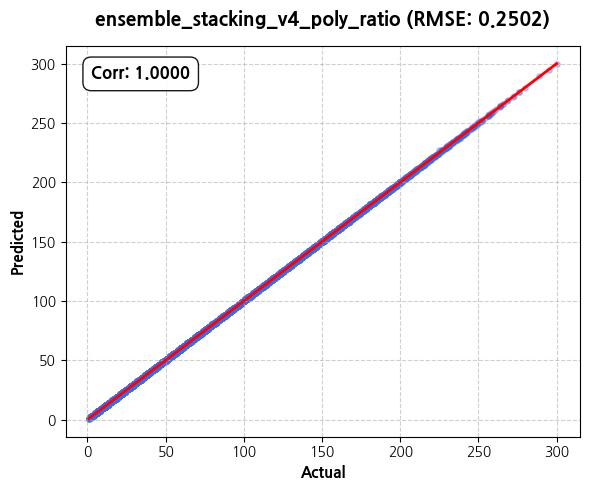

🚀 최종 RMSE: 0.2502


In [ ]:
# 상호작용, 다항식 및 도메인 비율(Ratio) 지표가 모두 포함된 최종 확장 데이터셋을 활용하여 스태킹 앙상블 학습 파이프라인 실행
final_model_v4, preds_v4, score_v4 = run_experiment_ensemble_v3(
    train_x=train_x_final_feat,          
    train_y=train_y,
    model_name='ensemble_stacking_v4_poly_ratio',
    cv=kf
)

print(f"🚀 최종 RMSE: {score_v4:.4f}")

In [ ]:
# 제출용 파일 생성을 위해 원본 테스트 데이터의 고유 식별자(ID) 컬럼을 추론용 확장 데이터셋에 복원
test_x_final_feat['ID'] = test['ID']

# 다항식 및 도메인 비율 특성이 모두 반영된 데이터와 최종 학습된 앙상블 객체를 활용하여 제출 파일 생성
submission_v3 = generate_submission_ensemble_v2(
    test_df=test_x_final_feat,
    model_name='ensemble_stacking_v4_poly_ratio' 
)

📂 모델 로드 중: ensemble_stacking_v4_poly_ratio
🔍 테스트 데이터 예측 중...
🎉 성공적으로 저장되었습니다: ./data/submission/submission_ensemble_stacking_v4_poly_ratio.csv
          ID  Calories_Burned
0  TEST_0000            173.0
1  TEST_0001            189.0
2  TEST_0002             53.0
3  TEST_0003            162.0
4  TEST_0004            226.0
